## Dependencies

In [102]:
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from scipy import stats
import pingouin as pg
import scikit_posthocs as sp
import statsmodels.api as sm
from scipy.stats import boxcox
#from statannotations.Annotator import Annotator
from scipy.stats import pearsonr
import docx
from docx.enum.section import WD_ORIENT
from docx.enum.section import WD_SECTION
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Pt
import statsmodels.formula.api as smf


## Helper functions

In [103]:
# Function to convert df to docx table format

def df_to_table(doc, df):
    # Add a table to the end and create a reference variable
    t = doc.add_table(df.shape[0]+1, df.shape[1])

    # Make sure df is rounded 
    df = df.round(2)

    # Make sure table is auto fit
    for cell in t._cells:
        cell.width = docx.shared.Inches(1.0)
    
    # Set the style of the table
    table_style = doc.styles['Table Grid']

    # Add the header rows.
    for j in range(df.shape[-1]):
        t.cell(0,j).text = df.columns[j]

    # Add the rest of the data frame
    for i in range(df.shape[0]):
        for j in range(df.shape[-1]):
            t.cell(i+1,j).text = str(df.values[i,j])
    
    return doc

In [104]:
def assign_diagnosis_group(row):
    if row['asd'] == 1:  # If ASD is 1, assign 'asd' regardless of ADHD
        return 'asd'
    elif row['adhd'] == 1:  # If ADHD is 1, assign 'adhd'
        return 'adhd'
    else:
        return 'control'  # Default to control if neither ASD nor ADHD is 1

In [105]:
#Take out close trials 
# Check if vs_location_list is a string or a list and handle accordingly
def extract_first_location(vs_location):
    if isinstance(vs_location, str):  # In case it's a string
        return int(vs_location.strip('()').split(', ')[0])
    elif isinstance(vs_location, list):  # In case it's already a list
        return vs_location[0]


In [184]:
def coefplot_gap(results, multiple_models=False, fig_name=None):
    '''
    Creates a coefficient plot with confidence intervals.
   
    Parameters:
    results : statsmodels results object or DataFrame
        If multiple_models=False: statsmodels results object
        If multiple_models=True: DataFrame with columns: index, model, Coef., [0.025, P>|z|
    multiple_models : bool, default False
        Whether to create a plot for multiple models or single model
   
    Returns:
        matplotlib plot
    '''
    # Create/process dataframe based on input type
    if not multiple_models:
        coef_df = pd.DataFrame(results.summary().tables[1]).reset_index()
    else:
        coef_df = results.copy()
   
    # Drop unwanted rows
    coef_df = coef_df.loc[coef_df["index"].isin(['Group Var', 'Intercept']) == False]
   
    # Convert numeric columns to float
    coef_df['Coef.'] = coef_df['Coef.'].astype(float)
    coef_df['[0.025'] = coef_df['[0.025'].astype(float)
    coef_df['P>|z|'] = coef_df['P>|z|'].astype(float)
   
    # Calculate errors
    coef_df['errors'] = coef_df['Coef.'] - coef_df['[0.025']
   
    # Create significance indicators - make them consistent between both cases
    if multiple_models:
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
    else:
        # Changed to match the multiple models case
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
   
    # Clean up Treatment variable names
    for var_name in coef_df['index'].unique():
        if "Treatment" in var_name:
            if ":" in var_name:
                var1 = var_name.split("[",1)[1].split("]")[0]
                var2 = var_name.split("[", 2)[-1]
                new_var_name = var1 + ":" + var2
            else:
                new_var_name = var_name.split("[", 1)[1].split("]")[0]
            coef_df['index'] = coef_df['index'].replace(var_name, new_var_name)
   
    # Create plot
    fig, ax = plt.subplots(figsize=(18, 10))
   
    # Define consistent marker styles
    marker_styles = {'Significant': 'X', 'Not Significant': 'o'}
   

    if multiple_models:
        # Get models and calculate positions
        models = coef_df['model'].unique()
        variables = coef_df['index'].unique()
        n_models = len(models)
        space_between = 2.5
        model_spacing = 1.0
       
        # Create position mapping
        positions = {}
        # Sort variables by their average coefficient value (lowest to highest)
        var_means = coef_df.groupby('index')['Coef.'].mean().sort_values()
        sorted_vars = var_means.index
       
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            for j, model in enumerate(models):
                positions[(var, model)] = base_pos + (j * model_spacing)
       
        # Add plot positions
        coef_df['plot_position'] = coef_df.apply(
            lambda row: positions[(row['index'], row['model'])],
            axis=1
        )
       
        # Set up colors for multiple models
        model_palette = sns.color_palette("husl", n_colors=len(models))
        model_colors = dict(zip(models, model_palette))
       
        # Plot error bars
        for model in models:
            model_data = coef_df[coef_df['model'] == model]
            plt.errorbar(x=model_data['Coef.'],
                        y=model_data['plot_position'],
                        xerr=model_data['errors'],
                        color=model_colors[model],
                        capsize=3,
                        fmt='none',
                        alpha=0.7,
                        zorder=1)
       
        # Plot points
        g = sns.scatterplot(data=coef_df,
                           x='Coef.',
                           y='plot_position',
                           hue='model',
                           style='Significance',
                           markers=marker_styles,
                           palette=model_colors,
                           s=200,
                           zorder=3,
                           ax=ax)
       
        # Set y-ticks
        tick_positions = []
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            middle_pos = base_pos + ((n_models - 1) * model_spacing) / 2
            tick_positions.append(middle_pos)
       
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(sorted_vars)
       
        # Create legends
        g.legend_.remove()
       
        # Model legend
        model_legend = ax.legend(
            title='Models',
            handles=[plt.Line2D([], [], marker='o', color=color, linestyle='None',
                               markersize=10, label=model)
                    for model, color in model_colors.items()],
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
       
        # Significance legend
        significance_handles = [
            plt.Line2D([], [], marker='X', color='gray', linestyle='None',
                      markersize=10, label='Significant'),
            plt.Line2D([], [], marker='o', color='gray', linestyle='None',
                      markersize=10, label='Not Significant')
        ]
       
        ax.add_artist(model_legend)
        ax.legend(handles=significance_handles,
                 title='Significance',
                 bbox_to_anchor=(1.02, 0.6),
                 loc='upper left')
       
    else:
        # Sort the dataframe by coefficient values (lowest to highest)
        coef_df = coef_df.sort_values(by='Coef.', ascending=False)
       
        # Single model plot
        palette = sns.color_palette("Set1")
        color_map = {'Significant': palette[0], 'Not Significant': palette[1]}
       
        # Error bars
        for idx, row in coef_df.iterrows():
            error_color = color_map[row['Significance']]
            plt.errorbar(x=row['Coef.'],
                        y=row['index'],
                        xerr=row['errors'],
                        color=error_color,
                        capsize=3,
                        fmt='none',
                        zorder=1)
       
        # Scatter plot with consistent markers
        g = sns.scatterplot(y='index',
                           x='Coef.',
                           style='Significance',
                           hue='Significance',
                           markers=marker_styles,
                           palette=color_map,
                           s=200,
                           data=coef_df,
                           zorder=3,
                           ax=ax)
   
    # Common plot elements
    ax.axvline(x=0, linestyle='--', color='red', linewidth=1)
   
    # Set title & labels
    title = 'Coefficients Across Models w/ 95% Confidence Intervals' if multiple_models else 'Coefficients of Features w/ 95% Confidence Intervals'
    plt.title(title, fontsize=30)
    ax.set_ylabel('Variables' if multiple_models else 'Coefficients', fontsize=22)
    ax.set_xlabel('Coefficient Value' if multiple_models else '', fontsize=22)
   
    # Set x-axis limits
    ax.set_xlim(coef_df['Coef.'].min() - max(coef_df['errors']),
                coef_df['Coef.'].max() + max(coef_df['errors']))
   
    plt.tight_layout()

        # Add to the document
   
    if multiple_models:
        doc.add_paragraph('Multiple models coefficient plot', style='List Bullet')
    else:

         doc.add_paragraph('Mixed effects model results', style='List Bullet')

    
    # Save the plot
    #plt.savefig(f"C:/Users/gabot/OneDrive - McGill University/Desktop/Q1K_neurosubs_2025/results/gap/figures/mixed_effects_model_{fig_name}_{date}.png")

    plt.show()
    return plt.show()

In [182]:
def check_homoscedasticity(model, data, show_text= True, co_vars = None):
    # Check for multicollinearity
    vif = pd.DataFrame()
    vif["variables"] = model.model.exog_names
    # Drop the intercept
    vif["VIF"] = [variance_inflation_factor(model.model.exog, i) for i in range(model.model.exog.shape[1])]
    vif = vif.loc[vif["variables"] != "Intercept"]
       
    homoscedasticity_per_variable = []
    #levene_test = stats.levene(model.fittedvalues, model.resid)

        # Get residuals
    residuals = model.resid
    fitted = model.fittedvalues
   
    # Levene's test for homoscedasticity
    groups = pd.qcut(fitted, q=4)  # Create groups based on fitted values
    levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


    if levene[1] < 0.05:
        print("Residuals are not homoscedastic", levene)
    # Do other tests to check for homoscedasticity such as bartlett or White test as well as normality test
    bartlett_test = stats.bartlett(model.fittedvalues, model.resid)
    white_test = statsmodels.stats.diagnostic.het_white(model.resid, model.model.exog)
    shapiro_test = stats.shapiro(model.resid)

    if show_text:
        print(f'Bartlett’s test p-value: {bartlett_test[1]}')
    # White test
        print(f'White test p-value: {white_test[1]}')  
        print(f'Levene’s test p-value for the whole model: {levene[1]}')
    homoscedasticity_per_variable.append({"levene_test_all": levene[1]})
    homoscedasticity_per_variable.append({"white_test": white_test[1]})
    homoscedasticity_per_variable.append({"bartlett_test": bartlett_test[1]})
    homoscedasticity_per_variable.append({"shapiro_test": shapiro_test[1]})
    homoscedasticity_per_variable.append({"multicollinearity": vif["VIF"].max()})              

    for variable in co_vars:
        if variable not in data.columns:
            continue
        residuals = model.resid
        group1 = residuals[data[variable] == data[variable].unique()[0]]
        group2 = residuals[data[variable] == data[variable].unique()[1]]

        stat, p_value = stats.levene(group1, group2)
        if show_text:
            print(f'Levene’s test p-value for variable {variable}: {p_value}')
        homoscedasticity_per_variable.append({variable: p_value.round(5)})
    homoscedasticity_df = pd.DataFrame(homoscedasticity_per_variable)
    homoscedasticity_df = pd.DataFrame([homoscedasticity_df.max()])

    print("Homoscedasticiyy checked")
    return homoscedasticity_df


def check_assumptions(model, data, show_plots=True, show_text= True, covariates = None):
    # Check for normality of residuals
    if show_plots:
        # Check for normality of residuals
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
       
        # Residuals vs Fitted
        sns.scatterplot(
            x=model.fittedvalues,
            y=model.resid,
            ax=axes[0,0]
        )
        axes[0,0].axhline(y=0, color='r', linestyle='--')
        axes[0,0].set_xlabel('Fitted values')
        axes[0,0].set_ylabel('Residuals')
        axes[0,0].set_title('Residuals vs Fitted')
       
        # QQ Plot
        stats.probplot(model.resid, dist="norm", plot=axes[0,1])
        axes[0,1].set_title('Normal Q-Q Plot')
       
        sns.scatterplot(
            x=model.fittedvalues,
            y=model.resid,
            ax=axes[1,0]
        )
        axes[1,0].set_xlabel('Fitted values')
        axes[1,0].set_ylabel('Residuals')
        axes[1,0].set_title('Homoscedasticity')
       
        # Residuals histogram
        sns.histplot(model.resid, kde=True, ax=axes[1,1])
        axes[1,1].set_title('Residuals Distribution')
       
        plt.tight_layout()
        plt.show()
    if show_text:
        shapiro_test = stats.shapiro(model.resid)
        print(f'Shapiro-Wilk test p-value: {shapiro_test[1]}')

    # Test for homoscedasticity using levens test
    check_homoscedasticity(model, data,show_text= True, co_vars = covariates)

       
    return "Assumptions checked"

def stage_model(model):

    coef_df = pd.DataFrame(model.summary().tables[1]).reset_index()
    if "Coef." not in coef_df.columns:
            # Make the first row the columns
            coef_df.columns = coef_df.iloc[0].astype(str)
            # Drop the first row
            coef_df = coef_df[1:]
            # Drop the first column
            coef_df = coef_df.drop(columns=["0"])
            # Rename the columns
            coef_df.rename(columns={"": "index", "coef":'Coef.','std err':'Std.Err.', "t":"stat","P>|t|":"P>|z|"}, inplace=True)
            coef_df['Coef.']=coef_df['Coef.'].astype(str)
            coef_df['Std.Err.']=coef_df['Std.Err.'].astype(str)
            coef_df['stat']=coef_df['stat'].astype(str)
            coef_df['P>|z|']=coef_df['P>|z|'].astype(str)
            coef_df['[0.025']=coef_df['[0.025'].astype(str)
            coef_df['0.975]']=coef_df['0.975]'].astype(str)
            coef_df["index"]= coef_df["index"].astype(str)


    else:
        coef_df.rename(columns={"z":"stat", "P>|z|":"P>|z|"}, inplace=True)
           
           
    # Drop unwanted rows where z values are ''
    coef_df = coef_df.loc[coef_df.stat != ''].copy()    

    # Drop the intercept row as well
    coef_df = coef_df.loc[coef_df["index"].isin(['Intercept']) == False]

    # Convert numeric columns to float
    coef_df['Coef.'] = coef_df['Coef.'].astype(float)
    coef_df['[0.025'] = coef_df['[0.025'].astype(float)
    coef_df['P>|z|']= coef_df['P>|z|'].astype(float)
   
    # Calculate errors
    coef_df['errors'] = coef_df['Coef.'] - coef_df['[0.025']

    return coef_df

# Eye tracking analyses 2025 Visual Search

In [106]:
# Date 
files_date= "2025"
file_path = "'/Users/audrey-annebeaudry/Desktop/OneDrive_1_2025-01-12/control_files/*.txt'"
file_path_demo = "/Users/audrey-annebeaudry/Desktop/Final_folder_VS/q1k_attempted_demographic_ouputs_2025_07_12.csv"

## Data loading

In [107]:
# Load all the files
vs_p = glob.glob('/Users/audrey-annebeaudry/Desktop/OneDrive_1_2025-01-12/experimental_files-2/*.txt')
vs_control = glob.glob(file_path)
all_files = vs_control + vs_p
go_files = all_files
p1= f"Total files including tests: " + str(len(go_files))
print (p1)


Total files including tests: 110


In [108]:
# Load all the files into a single dataframe
df = []
for file in all_files:
    file_name = file.split('/')[-1]
    file_name = "_".join(file_name.split('_')[:-1])
    subject_df = pd.read_csv(file, delimiter = "\t")
    subject_df['subject'] = file_name
    df.append(subject_df)
df = pd.concat(df, axis=0)


In [109]:
## keep only the relevant columns
df["detail"] = df["detail"].replace({"Single_Apple": "Single", "Single_Slice": "Single"})
df = df[["subject","Trial_Index_","condition", "detail", "VS_SAC_RT", "VS_VALID", "vs_location_list"]]
df

,subject,Trial_Index_,condition,detail,VS_SAC_RT,VS_VALID,vs_location_list
0,1009S1,1,Five,Single,628,True,"(7, 2, 9, 14, 4)"
1,1009S1,2,Nine,Single,344,True,"(1, 15, 2, 10, 6, 11, 7, 4, 16)"
2,1009S1,3,Thirteen,Single,244,True,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)"
3,1009S1,4,Five,Single,931,True,"(10, 0, 14, 3, 2)"
4,1009S1,5,Nine,Single,197,True,"(3, 10, 0, 13, 9, 16, 14, 5, 7)"
...,...,...,...,...,...,...,...
25,1121M1,26,Nine,Conjunction,170,True,"(0, 3, 11, 13, 7, 8, 5, 1, 6)"
26,1121M1,27,Nine,Conjunction,199,True,"(13, 8, 7, 5, 0, 4, 16, 11, 1)"
27,1121M1,28,Thirteen,Conjunction,229,True,"(15, 9, 5, 8, 0, 11, 12, 4, 7, 6, 13, 2, 14)"
28,1121M1,29,Thirteen,Conjunction,258,True,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)"


In [110]:
# Load demographic data

demo_df = pd.read_csv(file_path_demo)

In [111]:
demo_df

,record_id,et_id,q1k_ID,eeg_age,eeg_sex,diagnosis,visit_date,RS,TO,GO,...,registry_confirmed_adhd,ghf_adhd,language_disorder,registry_confirmed_language_disorder,language_dis_healthform,phase_3_consented,phase_2_consented,age_group,bids_id,participant_id
0,100,Q100_P,Q1K_HSJ_100100_P,6.557401,1,NDD,2024-02-23,1,1,0,...,1.0,1,1.0,2.0,0,Complete,Complete,child,sub-0100P,sub-0100P
1,101,Q100_S1,Q1K_HSJ_100100_S1,3.351312,2,other,2024-02-23,1,1,0,...,NaN,0,1.0,NaN,1,Complete,Complete,child,sub-0100S1,sub-0100S1
2,103,Q100_F1,Q1K_HSJ_100100_F1,30.116977,2,NDD,2024-02-23,1,1,0,...,NaN,0,0.0,NaN,0,Complete,Complete,adult,sub-0100F1,sub-0100F1
3,104,Q104_P,Q1K_HSJ_100104_P,36.206082,1,NDD,2024-07-02,1,1,1,...,NaN,1,1.0,NaN,0,Complete,Complete,adult,sub-0104P,sub-0104P
4,105,Q105_P,Q1K_HSJ_100105_P,4.394227,1,NDD,2024-04-22,1,1,1,...,1.0,0,1.0,2.0,1,Complete,Complete,child,sub-0105P,sub-0105P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,86,Q086_P,Q1K_HSJ_10086_P,10.491774,2,NDD,2024-02-15,0,0,0,...,NaN,0,1.0,2.0,1,Complete,Complete,child,sub-0086P,sub-0086P
346,87,Q086_S1,Q1K_HSJ_10086_S1,19.283193,1,NDD,2024-02-07,1,1,1,...,NaN,0,0.0,NaN,0,Complete,Complete,adult,sub-0086S1,sub-0086S1
347,88,Q086_M1,Q1K_HSJ_10086_M1,49.698602,1,family-non affected,2024-02-15,1,1,1,...,NaN,NaN,NaN,NaN,NaN,Complete,Complete,adult,sub-0086M1,sub-0086M1
348,89,Q086_F1,Q1K_HSJ_10086_F1,47.710882,2,family-non affected,2024-02-07,1,1,1,...,NaN,NaN,0.0,NaN,NaN,Complete,Complete,adult,sub-0086F1,sub-0086F1


In [112]:
# keep only the subjects that are in the go_df 
demo_df['bids_id'] = demo_df['bids_id'].str.replace('sub-', '', regex=False)
demo_df = demo_df[demo_df['bids_id'].isin(df['subject'])]

In [113]:
# Make a true copy if not already done
demo_df = demo_df.copy()

# Safe column assignment using .loc
demo_df.loc[:, 'sex'] = demo_df['eeg_sex']
demo_df.loc[:, 'age'] = demo_df['eeg_age']

In [114]:
# Keep important columns
demo_df = demo_df[["age", "group", "site", "sex", "asd",  "bids_id", "adhd", "record_id"]]

# Change ASD from 0, 1 to "asd" and "control"
demo_df.loc[:, "asd"] = demo_df["asd"].replace({"0": "control", "1": "asd"})

In [115]:
demo_df

,age,group,site,sex,asd,bids_id,adhd,record_id
3,36.206082,proband,hsj,1,0.0,0104P,1.0,104
18,46.681314,mother,hsj,1,0.0,0119M1,0.0,121
26,40.162244,mother,hsj,1,NaN,0129M1,NaN,130
27,8.432640,proband,hsj,1,0.0,0131P,1.0,131
28,13.582757,sibling,hsj,1,NaN,0131S1,NaN,132
...,...,...,...,...,...,...,...,...
340,12.216541,sibling,hsj,2,1.0,0064S1,1.0,65
341,38.076073,mother,hsj,1,NaN,0064M1,NaN,66
346,19.283193,sibling,hsj,1,1.0,0086S1,0.0,87
348,47.710882,father,hsj,2,0.0,0086F1,0.0,89


In [116]:
# Create column for age group
demo_df['age_group'] = pd.cut(demo_df['age'], bins=[0, 18, 100], labels=['child', 'adult'])

In [117]:
demo_df["sex"] = demo_df["sex"].replace({"Female": "female", "Male": "male"})

In [118]:
demo_df['adhd'] = demo_df['adhd'].fillna('0')  # Replace NaN with 0
demo_df['adhd'] = demo_df['adhd'].replace('Suspected', '1')  # Replace 'suspected' with 1

In [119]:
demo_df["asd"] = demo_df["asd"].fillna("Unknown")

In [120]:
unknown_asd = demo_df[demo_df['asd'] == 'Unknown']  # Filter rows where 'asd' is 'unknown'

In [121]:
# Remove rows where 'asd' column has 'Missing if impossible to confirm'
demo_df = demo_df[demo_df['asd'] != 'Missing if impossible to confirm']

In [122]:
# Apply the function to each row to create the 'diagnosis_group' column
demo_df['diagnosis_group'] = demo_df.apply(assign_diagnosis_group, axis=1)


In [123]:
for subject in df.subject.unique():
    if subject in demo_df.bids_id.unique():
        continue
    else: 
        print (f"Flag '{subject}'") #STILL NEED TO ADD THE CONTROL DOCUMENTATION!

## Exploratory Analysis - demographics analysis

In [124]:
demo_df

,age,group,site,sex,asd,bids_id,adhd,record_id,age_group,diagnosis_group
3,36.206082,proband,hsj,1,0.0,0104P,1.0,104,adult,adhd
18,46.681314,mother,hsj,1,0.0,0119M1,0.0,121,adult,control
26,40.162244,mother,hsj,1,Unknown,0129M1,0,130,adult,control
27,8.432640,proband,hsj,1,0.0,0131P,1.0,131,child,adhd
28,13.582757,sibling,hsj,1,Unknown,0131S1,0,132,child,control
...,...,...,...,...,...,...,...,...,...,...
340,12.216541,sibling,hsj,2,1.0,0064S1,1.0,65,child,asd
341,38.076073,mother,hsj,1,Unknown,0064M1,0,66,adult,control
346,19.283193,sibling,hsj,1,1.0,0086S1,0.0,87,adult,asd
348,47.710882,father,hsj,2,0.0,0086F1,0.0,89,adult,control


In [125]:
demo_df['age_group'] = demo_df['age_group'].astype(str)
# Assuming demo_df is already defined as the demographic dataframe

# Summarize data by diagnosis groups
summary_table = demo_df.groupby("diagnosis_group").agg(
    n=("diagnosis_group", "count"),
    male=("sex", lambda x: (x == "male").sum()),
    female=("sex", lambda x: (x == "female").sum()),
    mean_age=("age", "mean"),
    std_age=("age", "std"),
    hsj=("site", lambda x: (x == "hsj").sum()),
    mni=("site", lambda x: (x == "mni").sum()),
    adults=("age_group", lambda x: (x == "adult").sum()),
    children=("age_group", lambda x: (x == "child").sum()),
).reset_index()

# Add combined row for all participants
all_participants = {
    "diagnosis_group": "combined",
    "n": summary_table["n"].sum(),
    "male": summary_table["male"].sum(),
    "female": summary_table["female"].sum(),
    "mean_age": demo_df["age"].mean(),
    "std_age": demo_df["age"].std(),
    "hsj": summary_table["hsj"].sum(),
    "mni": summary_table["mni"].sum(),
    "adults": summary_table["adults"].sum(),
    "children": summary_table["children"].sum(),
}

summary_table = pd.concat(
    [pd.DataFrame([all_participants]), summary_table], ignore_index=True
)

# Create combined and percentage columns
summary_table["sex (M:F)"] = summary_table["male"].astype(str) + ":" + summary_table["female"].astype(str)
summary_table["sex % (M:F)"] = (
    (summary_table["male"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["female"] / summary_table["n"] * 100).round(2).astype(str)
)

summary_table["site (HSJ:MNI)"] = summary_table["hsj"].astype(str) + ":" + summary_table["mni"].astype(str)
summary_table["site % (HSJ:MNI)"] = (
    (summary_table["hsj"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["mni"] / summary_table["n"] * 100).round(2).astype(str)
)

# Drop intermediate columns to keep the table clean
summary_table.drop(columns=["male", "female", "hsj", "mni"], inplace=True)

# Rename columns for better clarity
summary_table.rename(
    columns={
        "diagnosis_group": "Diagnosis Group",
        "n": "Total Participants",
        "mean_age": "Mean Age",
        "std_age": "Age SD",
        "adults": "Adults",
        "children": "Children",
    },
    inplace=True,
)
summary_table=summary_table.round(2)

In [126]:
summary_table

,Diagnosis Group,Total Participants,Mean Age,Age SD,Adults,Children,sex (M:F),sex % (M:F),site (HSJ:MNI),site % (HSJ:MNI)
0,combined,107,28.79,16.21,63,44,0:0,0.0:0.0,68:39,63.55:36.45
1,adhd,14,22.61,13.90,6,8,0:0,0.0:0.0,12:2,85.71:14.29
2,asd,24,15.70,7.99,5,19,0:0,0.0:0.0,13:11,54.17:45.83
3,control,69,34.60,15.76,52,17,0:0,0.0:0.0,43:26,62.32:37.68


### Famly dynamics

In [48]:
print(demo_df.group.value_counts())

group
mother     35
proband    30
sibling    25
father     17
Name: count, dtype: int64


In [49]:
df["subject"] = df["subject"].astype(str)
demo_df["bids_id"] = demo_df["bids_id"].astype(str)
df["subject"] = df["subject"].str.strip()
demo_df["bids_id"] = demo_df["bids_id"].str.strip()
demo_df["diagnosis_group"] = demo_df["diagnosis_group"].astype(str).replace("nan", np.nan)

In [50]:
## Merge the go_df and demo_df
demo_df = demo_df.rename(columns = {'bids_id' : 'subject'})
df = pd.merge(df, demo_df, on="subject", how="inner")
#print(df["asd"].unique())

## Differences in accuracy (valid trials)

### Particpant statistics for accuracy 

In [52]:
# Change reaction times below 0 to invalide trials 

df.loc[df.VS_SAC_RT < 0, "VS_VALID"] = False

In [53]:
def accuracy_proportions(df):
    # Filter for the second half of trials
    #half = df['Trial_Index_'].max() // 2
   # second_half = df[df['Trial_Index_'] > half]

    # Count -1 reaction times (inaccurate) and accurate trials
    inaccurate_count = df[df['VS_SAC_RT'] == -1].shape[0]
    accurate_count = df[df['VS_VALID'] == True].shape[0]
    
    # Proportions
    if accurate_count + inaccurate_count == 0:
        proportion_inaccurate = 0
        proportion_accurate = 0
    else:
        proportion_inaccurate = inaccurate_count / (inaccurate_count + accurate_count)
        proportion_accurate = accurate_count / (inaccurate_count + accurate_count)
    
    return pd.Series({
        'Proportion_Inaccurate': proportion_inaccurate,
        'Proportion_Accurate': proportion_accurate,
        'Count_Inaccurate': inaccurate_count,
        'Count_Accurate': accurate_count
    })

# Group by subject and calculate proportions
df_accuracy = df.groupby('subject').apply(accuracy_proportions).reset_index()
df_accuracy = pd.merge(df, df_accuracy, on="subject", how="inner")
# Keep important columns
df_accuracy = df_accuracy[["subject", "diagnosis_group", "VS_VALID", "condition", "detail", "Proportion_Inaccurate",	"Proportion_Accurate",	"Count_Inaccurate",	"Count_Accurate" ]]

In [54]:
# Outline participants with more than 50% failed trials
df_accuracy[df_accuracy["Proportion_Accurate"] > 0.50]
df_accuracy

,subject,diagnosis_group,VS_VALID,condition,detail,Proportion_Inaccurate,Proportion_Accurate,Count_Inaccurate,Count_Accurate
0,1009S1,adhd,True,Five,Single,0.0,1.0,0.0,30.0
1,1009S1,adhd,True,Nine,Single,0.0,1.0,0.0,30.0
2,1009S1,adhd,True,Thirteen,Single,0.0,1.0,0.0,30.0
3,1009S1,adhd,True,Five,Single,0.0,1.0,0.0,30.0
4,1009S1,adhd,True,Nine,Single,0.0,1.0,0.0,30.0
...,...,...,...,...,...,...,...,...,...
3234,1121M1,asd,True,Nine,Conjunction,0.0,1.0,0.0,30.0
3235,1121M1,asd,True,Nine,Conjunction,0.0,1.0,0.0,30.0
3236,1121M1,asd,True,Thirteen,Conjunction,0.0,1.0,0.0,30.0
3237,1121M1,asd,True,Thirteen,Conjunction,0.0,1.0,0.0,30.0


In [55]:
valid_trials=df_accuracy[df_accuracy.VS_VALID==True].groupby(["subject","condition", "detail"])["VS_VALID"].count()
total_trials=df_accuracy.groupby(["subject","condition", "detail","diagnosis_group"])["VS_VALID"].count()
acc_per_sub=valid_trials/total_trials

In [56]:
acc_per_sub_s=pd.DataFrame(acc_per_sub).reset_index().rename(columns={"VS_VALID":"perc_accuracy"})
acc_decriptive_stats=acc_per_sub_s.groupby(["condition", "detail"]).perc_accuracy.describe().reset_index()
acc_decriptive_stats.round(2)

,condition,detail,count,mean,std,min,25%,50%,75%,max
0,Five,Conjunction,105.0,0.87,0.21,0.14,0.83,1.0,1.0,1.0
1,Five,Single,102.0,0.90,0.17,0.20,0.75,1.0,1.0,1.0
2,Nine,Conjunction,105.0,0.85,0.24,0.10,0.75,1.0,1.0,1.0
3,Nine,Single,105.0,0.87,0.20,0.25,0.75,1.0,1.0,1.0
4,Thirteen,Conjunction,104.0,0.85,0.24,0.17,0.81,1.0,1.0,1.0
5,Thirteen,Single,104.0,0.93,0.14,0.50,1.00,1.0,1.0,1.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='perc_accuracy', ylabel='Count'>

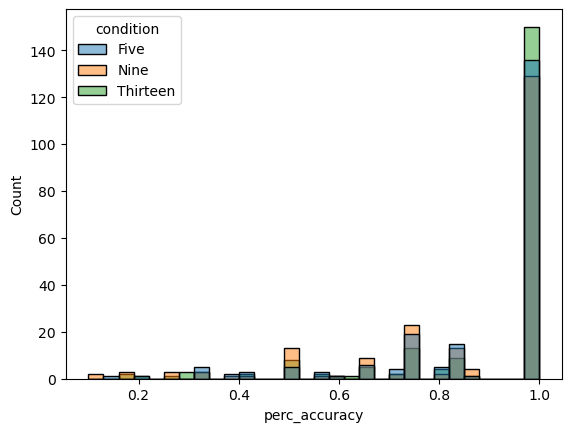

In [57]:
sns.histplot(acc_per_sub_s, x="perc_accuracy", hue="condition", bins=30)

### Anova to test differences 

#### Assumption of normality

In [58]:
pg.normality(data=acc_per_sub_s, dv='perc_accuracy', group='condition').round(2)


,W,pval,normal
condition,,,
Five,0.66,0.0,False
Nine,0.70,0.0,False
Thirteen,0.60,0.0,False


#### Assumption of normality transformations

In [59]:
#Applied various trasnformations
acc_per_sub_s["log_rt"]=np.log(acc_per_sub_s.perc_accuracy)
acc_per_sub_s["sqrt_rt"]=np.sqrt(acc_per_sub_s.perc_accuracy)
acc_per_sub_s["reciprocal_rt"] = boxcox(acc_per_sub_s.perc_accuracy,-0.5)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

<Axes: xlabel='reciprocal_rt', ylabel='Count'>

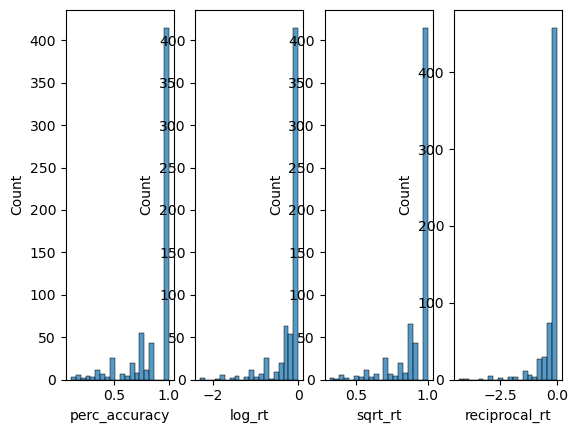

In [60]:
fig, axs = plt.subplots(ncols=4)
sns.histplot(acc_per_sub_s.perc_accuracy,edgecolor='black', bins=20, ax=axs[0])
sns.histplot(acc_per_sub_s.log_rt,edgecolor='black', bins=20, ax=axs[1])
sns.histplot(acc_per_sub_s.sqrt_rt,edgecolor='black', bins=20, ax=axs[2])
sns.histplot(acc_per_sub_s.reciprocal_rt,edgecolor='black', bins=20, ax=axs[3])


In [61]:
# Perform normality tests for each group and condition
results=[]
for group in acc_per_sub_s['diagnosis_group'].unique():
    for condition in acc_per_sub_s['condition'].unique():
        subset = acc_per_sub_s[(acc_per_sub_s['diagnosis_group'] == group) & (acc_per_sub_s['condition'] == condition)]
        test_result = pg.normality(subset['perc_accuracy'], method='shapiro')
        results.append({
            'diagnosis_group': group,
            'condition': condition,
            'p-value': test_result['pval'].values[0],
            'Normal': 'Yes' if test_result['pval'].values[0] > 0.05 else 'No'
        })

results_df = pd.DataFrame(results)
results_df

,diagnosis_group,condition,p-value,Normal
0,asd,Five,1.037635e-07,No
1,asd,Nine,6.770849e-09,No
2,asd,Thirteen,2.650661e-09,No
3,control,Five,2.820946e-16,No
4,control,Nine,5.845810e-16,No
5,control,Thirteen,1.339755e-17,No
6,adhd,Five,1.343972e-07,No
7,adhd,Nine,8.791140e-05,No
8,adhd,Thirteen,2.413655e-08,No


#### Assumption of sphericity (Mauchly’s test)

In [62]:

print(pg.sphericity(data=acc_per_sub_s, dv='perc_accuracy', subject='subject', within='condition')[-1])

# Perform Levene's test for homogeneity of variance
pg.homoscedasticity(data=acc_per_sub_s, dv='perc_accuracy', group='diagnosis_group', method='levene')

0.0023784527334131216


,W,pval,equal_var
levene,NaN,NaN,False


#### Condition friedmans

In [63]:
### Friedman Test (non-parametric)
pg.friedman(data=acc_per_sub_s, dv="perc_accuracy", within="condition", subject="subject").round(3)

,Source,W,ddof1,Q,p-unc
Friedman,condition,0.03,2,6.332,0.042


In [64]:
acc_per_sub_s.subject.value_counts()

subject
0042P     6
1067S1    6
1061S3    6
1061F1    6
1057M1    6
         ..
0183M1    6
1147S2    6
1052S1    5
0181P     3
0248S1    1
Name: count, Length: 107, dtype: int64

In [65]:
acc_per_sub_s['cond_det'] = acc_per_sub_s['condition'] + '_'+ acc_per_sub_s['detail']

In [66]:
#acc_per_sub_s.loc[acc_per_sub_s.subject == 'Q1K_002_Z']

In [70]:
posthocs=sp.posthoc_conover_friedman(a=acc_per_sub_s, y_col="perc_accuracy", group_col="cond_det", block_col="subject", block_id_col='subject',
                                 p_adjust="fdr_bh", melted=True)
posthocs["Condition"]= posthocs.index

posthocs


,Five_Conjunction,Five_Single,Nine_Conjunction,Nine_Single,Thirteen_Conjunction,Thirteen_Single,Condition
Five_Conjunction,1.000000,0.673370,0.403025,0.792151,0.657711,0.004496,Five_Conjunction
Five_Single,0.673370,1.000000,0.186303,0.777135,0.352487,0.019974,Five_Single
Nine_Conjunction,0.403025,0.186303,1.000000,0.325199,0.737846,0.000120,Nine_Conjunction
Nine_Single,0.792151,0.777135,0.325199,1.000000,0.501190,0.008282,Nine_Single
Thirteen_Conjunction,0.657711,0.352487,0.737846,0.501190,1.000000,0.000456,Thirteen_Conjunction
Thirteen_Single,0.004496,0.019974,0.000120,0.008282,0.000456,1.000000,Thirteen_Single


In [71]:
# Friedman for each group and condition

#NDD
print ("Friedmans for ASD")
pg.friedman(data=acc_per_sub_s.loc[acc_per_sub_s.diagnosis_group=="asd"] , dv="perc_accuracy", within="detail", subject="subject").round(3)


Friedmans for ASD


,Source,W,ddof1,Q,p-unc
Friedman,detail,0.009,1,0.222,0.637


In [72]:
#Control
print ("Friedmans for Control")
pg.friedman(data=acc_per_sub_s.loc[acc_per_sub_s.diagnosis_group=="control"] , dv="perc_accuracy", within="detail", subject="subject").round(3)


Friedmans for Control


,Source,W,ddof1,Q,p-unc
Friedman,detail,0.09,1,6.095,0.014


In [73]:
print ("Friedmans for ADHD")
pg.friedman(data=acc_per_sub_s.loc[acc_per_sub_s.diagnosis_group=="adhd"] , dv="perc_accuracy", within="detail", subject="subject").round(3)


Friedmans for ADHD


,Source,W,ddof1,Q,p-unc
Friedman,detail,0.011,1,0.143,0.705


#### Mann Whitney

In [75]:
# Mann Whitney U test for each differeences between groups for each condition 
pg.pairwise_ttests(data=acc_per_sub_s, dv='perc_accuracy', between='diagnosis_group', within=['condition', 'detail'], subject='subject', parametric=False, padjust='fdr_bh').round(3)


/opt/anaconda3/lib/python3.11/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,condition,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,condition,-,Five,Nine,True,False,722.5,two-sided,0.410,0.410,fdr_bh,0.114
1,condition,-,Five,Thirteen,True,False,527.5,two-sided,0.205,0.308,fdr_bh,-0.067
2,condition,-,Nine,Thirteen,True,False,406.5,two-sided,0.006,0.019,fdr_bh,-0.177
3,detail,-,Conjunction,Single,True,False,736.0,two-sided,0.063,NaN,NaN,-0.183
4,condition * detail,Five,Conjunction,Single,True,False,524.5,two-sided,0.517,0.517,fdr_bh,-0.089
5,condition * detail,Nine,Conjunction,Single,True,False,612.5,two-sided,0.487,0.517,fdr_bh,-0.083
6,condition * detail,Thirteen,Conjunction,Single,True,False,212.0,two-sided,0.008,0.024,fdr_bh,-0.313


### Plotting accuracy 

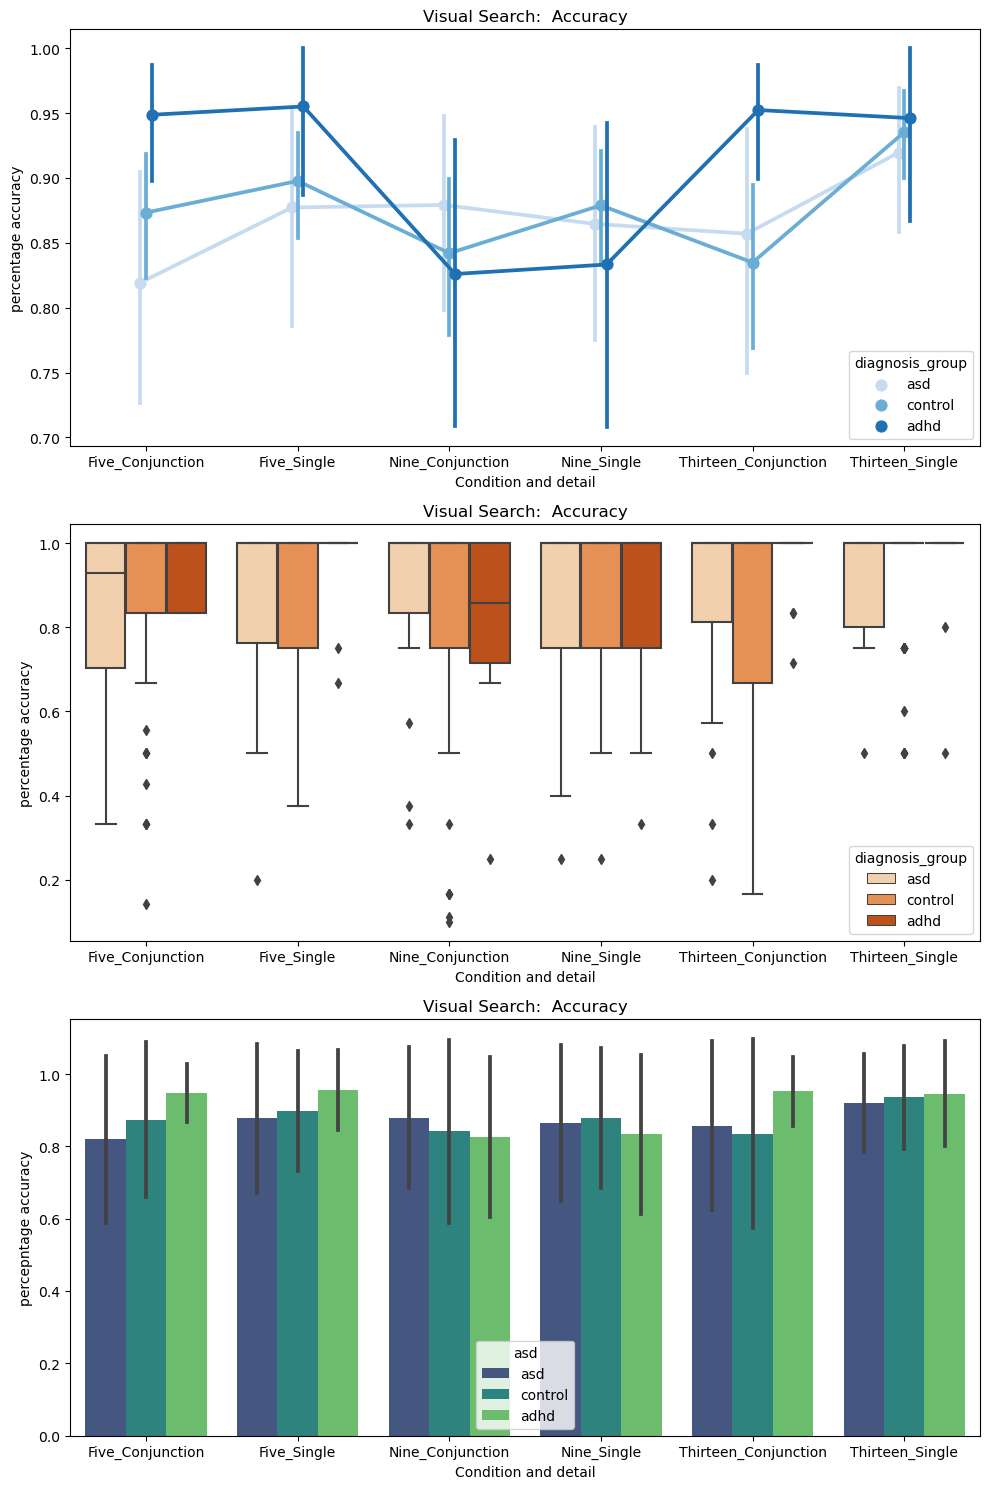

In [76]:


# Setting up the figure layout
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 1. Boxplot for RT by Condition
sns.pointplot(x="cond_det", y="perc_accuracy", hue="diagnosis_group", data=acc_per_sub_s, ax=axes[0], palette="Blues", dodge=True)#, markers=["o", "s"])
axes[0].set_title("Visual Search:  Accuracy")
axes[0].set_ylabel("percentage accuracy")
axes[0].set_xlabel("Condition and detail")

# 2. Boxplot for RT by Detail (Feature vs. Conjunction)
sns.boxplot(x="cond_det", y="perc_accuracy", hue ="diagnosis_group", data=acc_per_sub_s, ax=axes[1], palette="Oranges")
axes[1].set_title("Visual Search:  Accuracy")
axes[1].set_ylabel("percentage accuracy")
axes[1].set_xlabel("Condition and detail")

# 3. Interaction Plot: RT by Condition and Detail
sns.barplot(x="cond_det", y="perc_accuracy", hue="diagnosis_group", data=acc_per_sub_s, ax=axes[2], errorbar=("sd"), palette="viridis")
axes[2].set_title("Visual Search:  Accuracy")
axes[2].set_ylabel("percepntage accuracy")
axes[2].set_xlabel("Condition and detail")
axes[2].legend(title="asd")

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


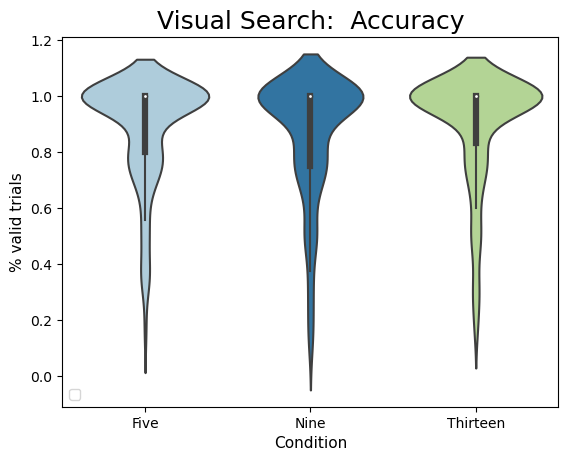

In [77]:
sns.violinplot(x="condition", y="perc_accuracy", data=acc_per_sub_s, palette="Paired"
        ).set_title('Visual Search:  Accuracy',fontsize=18)

plt.grid(False)
plt.ylabel('% valid trials',fontsize=11)
plt.xlabel('Condition',fontsize=11)
plt.legend(loc='lower left')

#plt.ylim([0.7,1.2])

# Save the figure
plt.savefig(f"/Users/audrey-annebeaudry/Desktop/OneDrive_1_2025-01-12/experimental_files{date}.png")

plt.show()


## Differences in reaction time 

In [78]:
#Remove failed trials, those with negative reaction times and reaction times abova 1 second
rt_df= df[df.VS_VALID]

#rt_df=rt_df.loc[(rt_df.VS_SAC_RT>0)] #& (rt_df.VS_SAC_RT<1000)]

In [79]:
rt_df.VS_VALID.value_counts()

VS_VALID
True    2770
Name: count, dtype: int64

In [80]:

rt_sub = pd.DataFrame(rt_df).reset_index().rename(columns={"VS_SAC_RT": "rt"})

# Calculate descriptive statistics including the mean
rt_decriptive_stats = rt_sub.groupby(["condition", "detail"]).rt.agg(['mean', 'std', 'min', 'max']).reset_index()

# Round to 2 decimal places
rt_decriptive_stats = rt_decriptive_stats.round(2)

rt_decriptive_stats

,condition,detail,mean,std,min,max
0,Five,Conjunction,784.976492,814.38,79,3845
1,Five,Single,801.68883,736.01,162,3932
2,Nine,Conjunction,635.103131,642.31,68,3774
3,Nine,Single,622.172973,688.21,168,3704
4,Thirteen,Conjunction,623.083333,610.61,45,3632
5,Thirteen,Single,586.729381,713.71,155,3928


In [81]:
rt_sub["diagnosis_group"] = rt_sub["diagnosis_group"].fillna("Unknown")
rt_sub

,index,subject,Trial_Index_,condition,detail,rt,VS_VALID,vs_location_list,age,group,site,sex,asd,adhd,record_id,age_group,diagnosis_group
0,0,1009S1,1,Five,Single,628,True,"(7, 2, 9, 14, 4)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
1,1,1009S1,2,Nine,Single,344,True,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
2,2,1009S1,3,Thirteen,Single,244,True,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
3,3,1009S1,4,Five,Single,931,True,"(10, 0, 14, 3, 2)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
4,4,1009S1,5,Nine,Single,197,True,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,3234,1121M1,26,Nine,Conjunction,170,True,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2766,3235,1121M1,27,Nine,Conjunction,199,True,"(13, 8, 7, 5, 0, 4, 16, 11, 1)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2767,3236,1121M1,28,Thirteen,Conjunction,229,True,"(15, 9, 5, 8, 0, 11, 12, 4, 7, 6, 13, 2, 14)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2768,3237,1121M1,29,Thirteen,Conjunction,258,True,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd


In [84]:
## TAKE OUT CLOSE TARGET TRIALS
# Apply the function to filter rows
rt_sub = rt_sub[rt_sub['vs_location_list'].apply(extract_first_location) < 12]
rt_sub

,index,subject,Trial_Index_,condition,detail,rt,VS_VALID,vs_location_list,age,group,site,sex,asd,adhd,record_id,age_group,diagnosis_group
0,0,1009S1,1,Five,Single,628,True,"(7, 2, 9, 14, 4)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
1,1,1009S1,2,Nine,Single,344,True,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
2,2,1009S1,3,Thirteen,Single,244,True,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
3,3,1009S1,4,Five,Single,931,True,"(10, 0, 14, 3, 2)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
4,4,1009S1,5,Nine,Single,197,True,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",13.801789,sibling,hsj,1,Unknown,1.0,525-1011,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2763,3232,1121M1,24,Five,Conjunction,282,True,"(5, 9, 4, 15, 6)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2764,3233,1121M1,25,Nine,Conjunction,237,True,"(3, 12, 1, 6, 2, 11, 15, 16, 10)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2765,3234,1121M1,26,Nine,Conjunction,170,True,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd
2768,3237,1121M1,29,Thirteen,Conjunction,258,True,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",39.310983,mother,hsj,1,1.0,1.0,525-1123,adult,asd


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


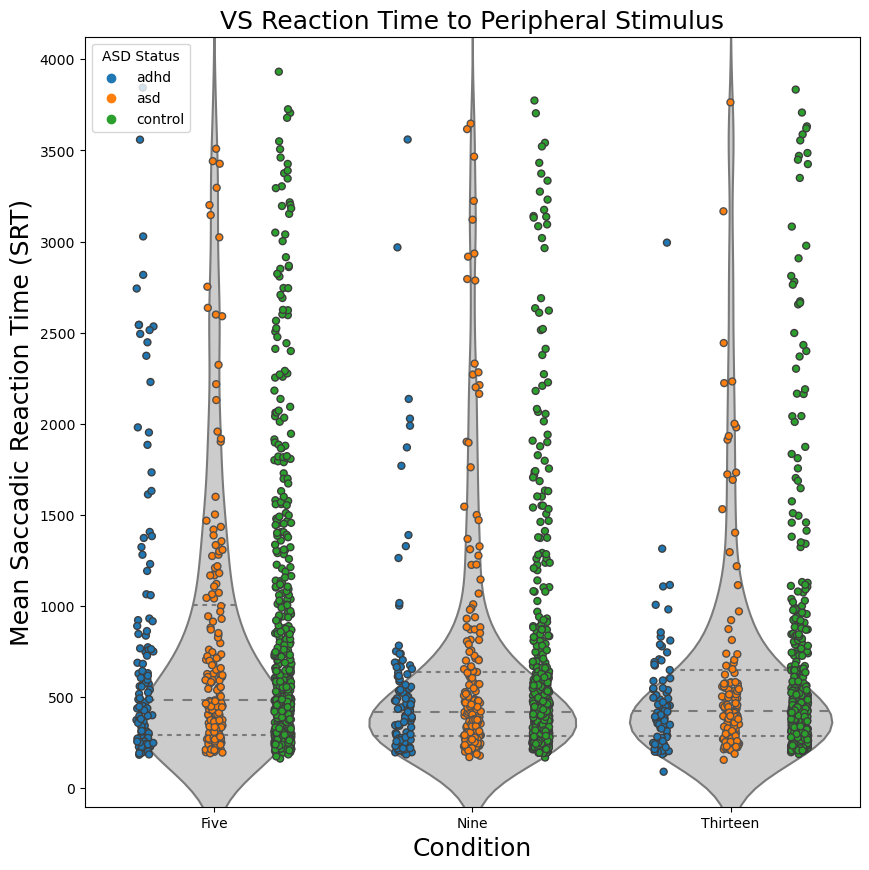

In [85]:
# Convert to categorical
rt_sub["condition"] = rt_sub["condition"].astype(str)
rt_sub["diagnosis_group"] = rt_sub["diagnosis_group"].astype(str)
rt_sub["rt"] = pd.to_numeric(rt_sub["rt"], errors='coerce')

# Drop NaNs
rt_sub = rt_sub.dropna(subset=["condition", "rt"])

plt.figure(figsize=(10, 10))

# Violin plot
sns.violinplot(x="condition", y="rt", inner='quartile', data=rt_sub, color=".8")

# Strip plot (overlayed)
sns.stripplot(x="condition", y="rt", hue="diagnosis_group", data=rt_sub, dodge=True, jitter=True, linewidth=1)

# Title and labels
plt.title('VS Reaction Time to Peripheral Stimulus', fontsize=18)
plt.ylabel('Mean Saccadic Reaction Time (SRT)', fontsize=18)
plt.xlabel('Condition', fontsize=18)

# Legend
plt.legend(title="ASD Status")

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


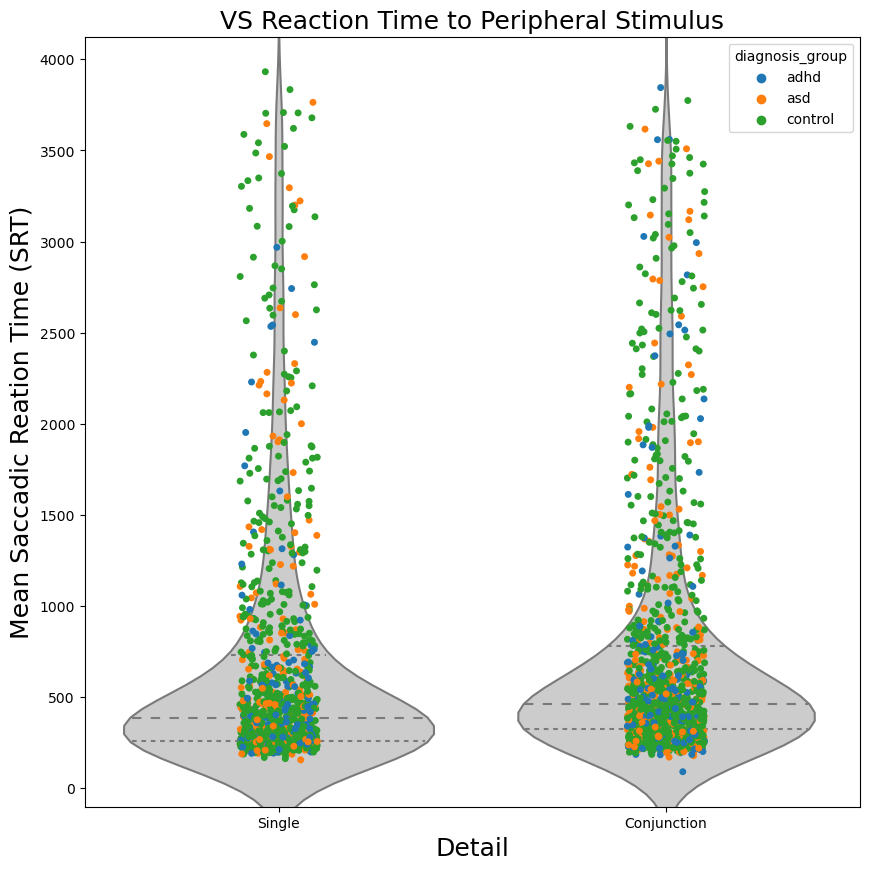

In [86]:
ax = plt.figure(figsize=(10, 10))
ax = sns.violinplot(x="detail", y="rt", inner='quartile', data=rt_sub, 
                    color=".8").set_title('VS Reaction Time to Peripheral Stimulus',fontsize=18)
ax = sns.stripplot(x="detail", y="rt", hue="diagnosis_group", data=rt_sub)
ax = plt.ylabel('Mean Saccadic Reation Time (SRT)',fontsize=18)
ax = plt.xlabel('Detail',fontsize=18)
#plt.savefig('vs_plot_2.png')

### Outlier detection for each subject

In [87]:
# Remove outliers for each subject

n_before = len(rt_sub)
print ("Toral number of trials before removal: ", len(rt_sub))
summary_outliers= []
for sub in rt_df.subject.unique():
    df=rt_df.loc[rt_df.subject==sub]
    # Function to perform outlier removal using IQR
    Q1 = df["VS_SAC_RT"].quantile(0.25)
    Q3 = df["VS_SAC_RT"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR # Should be 1.5 but can be adjusted to 3
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df["VS_SAC_RT"] >= lower_bound) & (df["VS_SAC_RT"] <= upper_bound)]
    df_removed = df[(df["VS_SAC_RT"] < lower_bound) | (df["VS_SAC_RT"] > upper_bound)]
    summary_outliers.append(df_removed)
    # Remove the outlier trials from the main dataframe
    if outlier_rem:
        rt_sub = rt_sub[~rt_sub.index.isin(df_removed.index)]
   
    print( "Subject: ", sub, "n trials removed: ", len(df_removed), "% left: ", len(df_filtered)/len(df)*100)

print ("Toral number of trials after removal: ", len(rt_sub))
n_after = len(rt_sub)
summary_outliers_df = pd.concat(summary_outliers, axis=0)


Toral number of trials before removal:  2278
Subject:  1009S1 n trials removed:  2 % left:  93.33333333333333
Subject:  0179P n trials removed:  7 % left:  76.66666666666667
Subject:  0216M1 n trials removed:  2 % left:  93.33333333333333
Subject:  0179M1 n trials removed:  7 % left:  76.66666666666667
Subject:  0146P n trials removed:  0 % left:  100.0
Subject:  0093O1 n trials removed:  1 % left:  90.9090909090909
Subject:  1073M1 n trials removed:  6 % left:  80.0
Subject:  1037F1 n trials removed:  6 % left:  77.77777777777779
Subject:  1106M1 n trials removed:  2 % left:  93.10344827586206
Subject:  1114P n trials removed:  0 % left:  100.0
Subject:  0223M1 n trials removed:  1 % left:  92.85714285714286
Subject:  0196M1 n trials removed:  5 % left:  82.75862068965517
Subject:  1134S1 n trials removed:  4 % left:  86.66666666666667
Subject:  0162S1 n trials removed:  3 % left:  90.0
Subject:  0200M1 n trials removed:  1 % left:  96.66666666666667
Subject:  0265P n trials removed: 

In [88]:
# Calculate the number of trials removed and how many per condition
summary_outliers_df.groupby(["condition", 'detail']).size().reset_index(name="n_removed")

,condition,detail,n_removed
0,Five,Conjunction,57
1,Five,Single,53
2,Nine,Conjunction,33
3,Nine,Single,22
4,Thirteen,Conjunction,38
5,Thirteen,Single,26


In [89]:
# Calculate the number of trials removed per subject and condition
summary_outliers_df2=summary_outliers_df.groupby(["subject", "condition", 'detail']).size().reset_index(name="n_trials_removed").pivot(index="subject", columns=[ "condition", 'detail'], values="n_trials_removed")
summary_outliers_df2

condition   Five    Thirteen               Five   Nine            
detail    Single Conjunction Single Conjunction Single Conjunction
subject                                                           
0042P        1.0         1.0    1.0         NaN    NaN         NaN
0064S1       NaN         NaN    1.0         1.0    NaN         NaN
0068F1       NaN         NaN    NaN         1.0    1.0         NaN
0068S1       1.0         NaN    1.0         2.0    NaN         1.0
0068S3       NaN         NaN    NaN         NaN    NaN         1.0
...          ...         ...    ...         ...    ...         ...
1134S1       1.0         NaN    1.0         2.0    NaN         NaN
1147F1       1.0         NaN    1.0         1.0    NaN         NaN
1147P        1.0         NaN    1.0         NaN    NaN         NaN
1147S1       NaN         2.0    NaN         NaN    NaN         NaN
1147S2       NaN         NaN    1.0         NaN    1.0         NaN

[86 rows x 6 columns]

In [90]:

# Create a table with the RT descriptive stats for both groups
rt_groups = (
    rt_sub.groupby(["subject", "diagnosis_group", "condition", "detail"])["rt"]
    .mean()
    .reset_index()
    .groupby(["diagnosis_group", "condition", "detail"])["rt"]
    .describe()
    .reset_index()
)

# Round and select important columns
rt_groups = rt_groups[["diagnosis_group", "condition", "detail", "mean", "std"]].round(2)

# Create table for combined groups
rt_combined = (
    rt_sub.groupby(["subject", "condition", "detail"])["rt"]
    .mean()
    .reset_index()
    .groupby(["condition", "detail"])["rt"]
    .describe()
    .reset_index()
)

# Round and select important columns
rt_combined = rt_combined[["condition", "detail", "mean", "std"]].round(2)
rt_combined["diagnosis_group"] = "combined"

# Merge tables
rt_combined = pd.concat([rt_groups, rt_combined], axis=0)

# Pivot table with 'detail' as a subcolumn
rt_combined = rt_combined.pivot(index=["condition", "detail"], columns=["diagnosis_group"], values=["mean", "std"]).reset_index()

# Display the final table
rt_combined

condition       detail    mean                           \
diagnosis_group                           adhd     asd combined control   
0                    Five  Conjunction  939.84  807.61   885.44  902.51   
1                    Five       Single  785.89  682.82   810.55  857.27   
2                    Nine  Conjunction  699.89  823.54   756.07  742.18   
3                    Nine       Single  502.80  780.24   650.97  635.58   
4                Thirteen  Conjunction  573.40  651.68   787.90  880.43   
5                Thirteen       Single  407.51  606.59   594.54  626.21   

                    std                           
diagnosis_group    adhd     asd combined control  
0                557.85  476.06   591.71  637.89  
1                352.06  295.23   539.85  622.85  
2                396.84  763.11   552.14  488.60  
3                233.56  716.00   538.95  508.14  
4                268.39  388.64   628.75  727.88  
5                204.38  463.06   531.28  590.07

In [91]:
rt_groups

,diagnosis_group,condition,detail,mean,std
0,adhd,Five,Conjunction,939.84,557.85
1,adhd,Five,Single,785.89,352.06
2,adhd,Nine,Conjunction,699.89,396.84
3,adhd,Nine,Single,502.80,233.56
4,adhd,Thirteen,Conjunction,573.40,268.39
5,adhd,Thirteen,Single,407.51,204.38
6,asd,Five,Conjunction,807.61,476.06
7,asd,Five,Single,682.82,295.23
8,asd,Nine,Conjunction,823.54,763.11
9,asd,Nine,Single,780.24,716.00


### Visualization

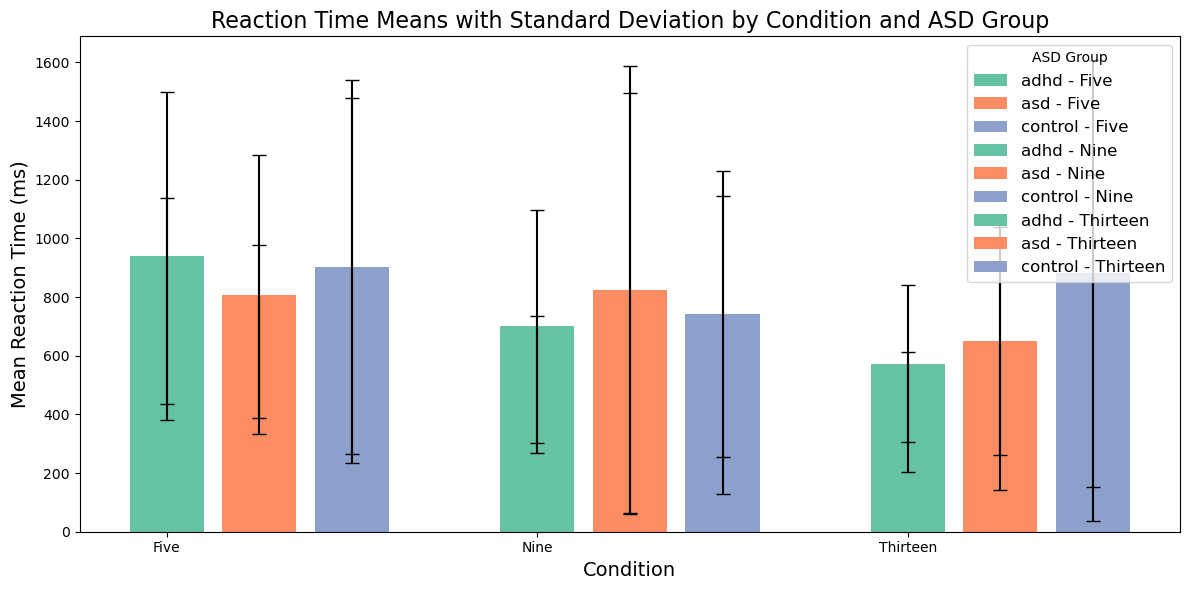

In [94]:
# Create a color palette for 'asd' groups
palette = sns.color_palette("Set2", n_colors=len(rt_groups['diagnosis_group'].unique()))

# Create the figure
plt.figure(figsize=(12, 6))

# Loop over each unique condition to plot bars with error bars
for idx, condition in enumerate(rt_groups['condition'].unique()):
    for asd_idx, asd_group in enumerate(rt_groups['diagnosis_group'].unique()):
        data = rt_groups[(rt_groups['condition'] == condition) & (rt_groups['diagnosis_group'] == asd_group)]
        
        # Plotting the bar plot with different colors for each 'asd' group
        plt.bar(idx + asd_idx * 0.25,
                data['mean'], yerr=data['std'], capsize=5, label=f'{asd_group} - {condition}',
                color=palette[asd_idx], width=0.2, align='center')

# Adding details
plt.title('Reaction Time Means with Standard Deviation by Condition and ASD Group', fontsize=16)
plt.ylabel('Mean Reaction Time (ms)', fontsize=14)
plt.xlabel('Condition', fontsize=14)
plt.xticks(np.arange(len(rt_groups['condition'].unique())), rt_groups['condition'].unique())
plt.legend(title="ASD Group", fontsize=12)

plt.tight_layout()
plt.show()

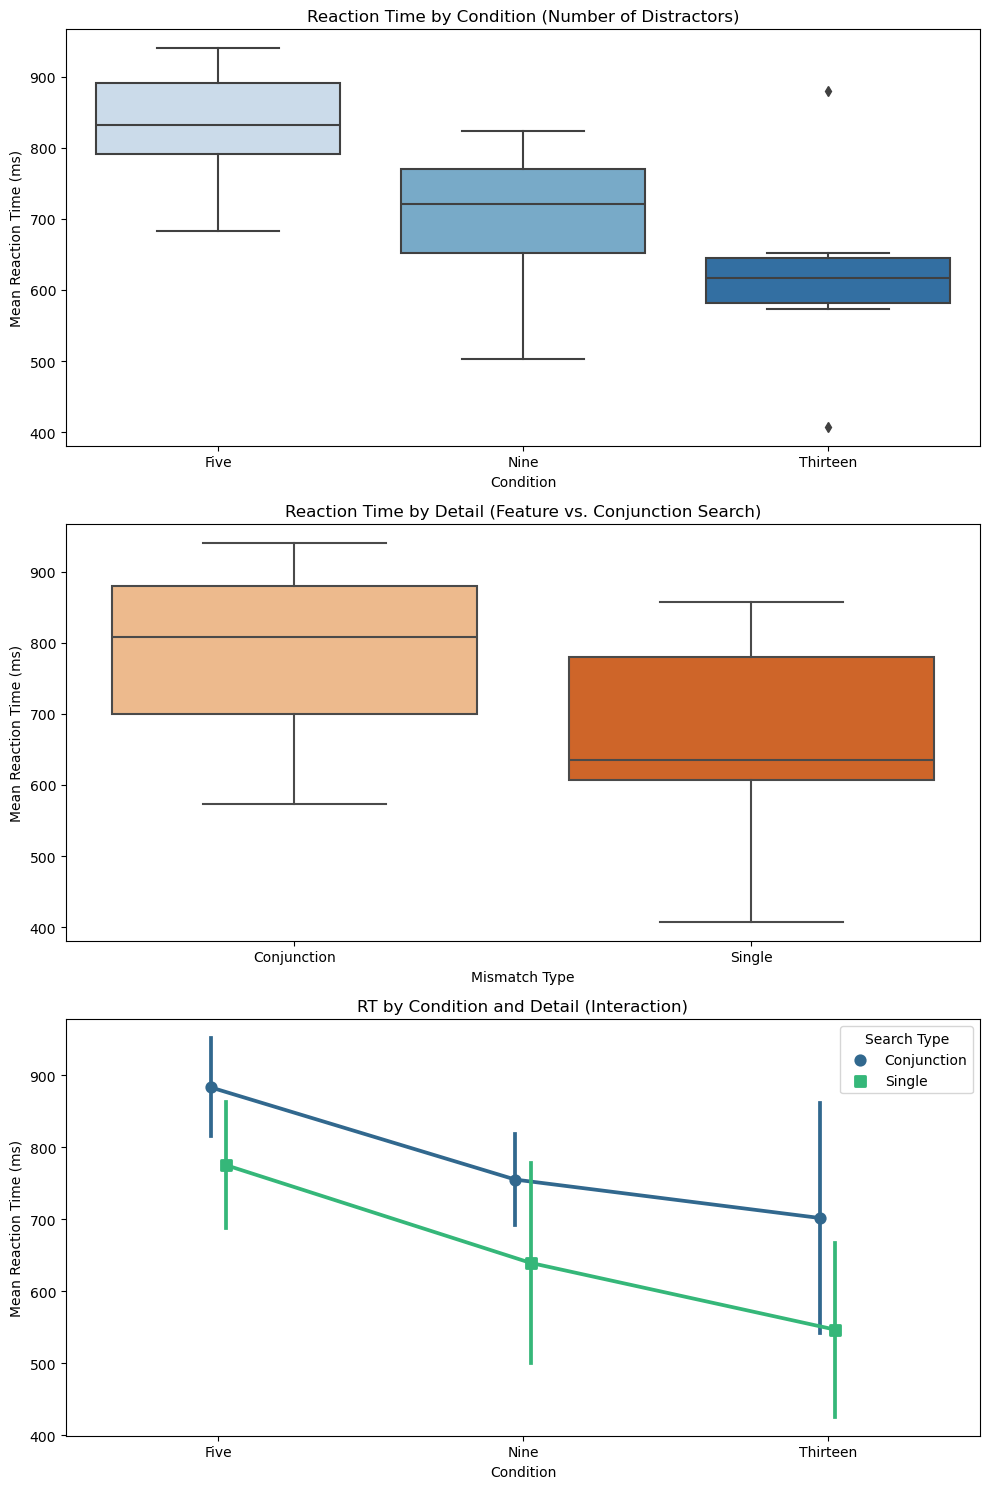

In [95]:
# Setting up the figure layout
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 1. Boxplot for RT by Condition
sns.boxplot(x="condition", y="mean", data=rt_groups, ax=axes[0], palette="Blues")
axes[0].set_title("Reaction Time by Condition (Number of Distractors)")
axes[0].set_ylabel("Mean Reaction Time (ms)")
axes[0].set_xlabel("Condition")

# 2. Boxplot for RT by Detail (Feature vs. Conjunction)
sns.boxplot(x="detail", y="mean", data=rt_groups, ax=axes[1], palette="Oranges")
axes[1].set_title("Reaction Time by Detail (Feature vs. Conjunction Search)")
axes[1].set_ylabel("Mean Reaction Time (ms)")
axes[1].set_xlabel("Mismatch Type")

# 3. Interaction Plot: RT by Condition and Detail
sns.pointplot(x="condition", y="mean", hue="detail", data=rt_groups, ax=axes[2], errorbar=("sd"), palette="viridis", dodge=True, markers=["o", "s"])
axes[2].set_title("RT by Condition and Detail (Interaction)")
axes[2].set_ylabel("Mean Reaction Time (ms)")
axes[2].set_xlabel("Condition")
axes[2].legend(title="Search Type")

plt.tight_layout()
plt.show()

In [96]:
# Compute the number of trials per condition and detail for the NDD group
ndd_trials = (
    rt_sub.loc[rt_sub.diagnosis_group == "asd"]
    .groupby(["subject", "condition", "detail"])
    .size()
    .reset_index(name="asd")
    .groupby(["condition", "detail"])["asd"]
    .mean()
    .reset_index()
)

# Compute the number of trials per condition and detail for the Control group
ctrl_trials = (
    rt_sub.loc[rt_sub.diagnosis_group == "control"]
    .groupby(["subject", "condition", "detail"])
    .size()
    .reset_index(name="control")
    .groupby(["condition", "detail"])["control"]
    .mean()
    .reset_index()
)

# Compute the number of trials per condition and detail for the Combined group
combined_trials = (
    rt_sub.groupby(["subject", "condition", "detail"])
    .size()
    .reset_index(name="combined")
    .groupby(["condition", "detail"])["combined"]
    .mean()
    .reset_index()
)

# Merge tables
combined_trials = pd.merge(ndd_trials, ctrl_trials, on=["condition", "detail"], how="outer")

# Pivot table to organize by condition and detail
combined_trials = combined_trials.pivot(index=["detail"], columns=["condition"]).reset_index()

# Display the final table
combined_trials

detail       asd                       control            \
condition                   Five      Nine  Thirteen      Five      Nine   
0          Conjunction  3.916667  4.000000  3.478261  4.014706  4.156250   
1               Single  3.409091  3.304348  2.521739  3.343284  3.308824   

                     
condition  Thirteen  
0          3.140625  
1          2.544118

In [97]:
#Compute number of trials per condition and detail per subject
n_trials = (
    rt_df.groupby(["subject", "condition", "detail"])
    .size()
    .reset_index(name="n_trials")
    .pivot(index="subject", columns=["condition", "detail"], values="n_trials")
)


In [98]:
# Check how many subjects have at least 1 trials per condition

n_trials=rt_sub.groupby(["subject", "condition", "detail"]).size().reset_index(name="n_trials").pivot(index="subject", columns= [ "condition", "detail"], values="n_trials")

# Check any rows with less than 4 trials
if outlier_rem:
    not_enough_trials=n_trials[n_trials < 1].dropna(how="all")
    not_enough_trials
else:
    not_enough_trials=n_trials[n_trials < 1].dropna(how="all")

    print ("No outlier removal") 

In [99]:
n_trials.round(0)

condition        Five               Nine           Thirteen       
detail    Conjunction Single Conjunction Single Conjunction Single
subject                                                           
0042P             5.0    4.0         4.0    4.0         4.0    2.0
0062P             4.0    4.0         4.0    4.0         4.0    2.0
0064M1            5.0    4.0         5.0    4.0         4.0    3.0
0064S1            5.0    4.0         5.0    3.0         4.0    3.0
0068F1            4.0    4.0         4.0    3.0         4.0    1.0
...               ...    ...         ...    ...         ...    ...
1140S1            3.0    2.0         NaN    4.0         2.0    2.0
1147F1            5.0    4.0         5.0    4.0         4.0    3.0
1147P             2.0    3.0         4.0    4.0         4.0    2.0
1147S1            4.0    4.0         4.0    4.0         4.0    3.0
1147S2            5.0    3.0         5.0    4.0         4.0    3.0

[105 rows x 6 columns]

In [100]:
# Change age_group to object
rt_sub["age_group"] = rt_sub["age_group"].astype(str)
outlier_demo= rt_sub.groupby(["subject","diagnosis_group","sex","age", "site","age_group"]).count().reset_index()
# Select important columns
outlier_demo=outlier_demo[["subject", "diagnosis_group", "sex", "age", "index", "site", "age_group"]].rename(columns={"index":"n_trials"}) 
outlier_demo

,subject,diagnosis_group,sex,age,n_trials,site,age_group
0,0042P,asd,1,30.973942,23,mni,adult
1,0062P,control,1,40.611375,22,hsj,adult
2,0064M1,control,1,38.076073,25,hsj,adult
3,0064S1,asd,2,12.216541,24,hsj,child
4,0068F1,control,2,44.124109,20,mni,adult
...,...,...,...,...,...,...,...
100,1140S1,control,1,9.632071,13,hsj,child
101,1147F1,control,2,50.637704,25,hsj,adult
102,1147P,asd,2,16.266020,19,hsj,child
103,1147S1,control,2,13.251584,23,hsj,child


#### Participant demographics after all outlier removal

In [101]:

# Summarize data by diagnosis groups
summary_table = outlier_demo.groupby("diagnosis_group").agg(
    n=("diagnosis_group", "count"),
    male=("sex", lambda x: (x == "male").sum()),
    female=("sex", lambda x: (x == "female").sum()),
    mean_age=("age", "mean"),
    std_age=("age", "std"),
    hsj=("site", lambda x: (x == "hsj").sum()),
    mni=("site", lambda x: (x == "mni").sum()),
    adults=("age_group", lambda x: (x == "adult").sum()),
    children=("age_group", lambda x: (x == "child").sum()),
    n_trials=("n_trials", "mean")
).reset_index()

# Add combined row for all participants
all_participants = {
    "diagnosis_group": "combined",
    "n": summary_table["n"].sum(),
    "male": summary_table["male"].sum(),
    "female": summary_table["female"].sum(),
    "mean_age": outlier_demo["age"].mean(),
    "std_age": outlier_demo["age"].std(),
    "hsj": summary_table["hsj"].sum(),
    "mni": summary_table["mni"].sum(),
    "adults": summary_table["adults"].sum(),
    "children": summary_table["children"].sum(),
    "n_trials": summary_table["n_trials"].mean()
}

summary_table = pd.concat(
    [pd.DataFrame([all_participants]), summary_table], ignore_index=True
)

# Create combined and percentage columns
summary_table["sex (M:F)"] = summary_table["male"].astype(str) + ":" + summary_table["female"].astype(str)
summary_table["sex % (M:F)"] = (
    (summary_table["male"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["female"] / summary_table["n"] * 100).round(2).astype(str)
)

summary_table["site (HSJ:MNI)"] = summary_table["hsj"].astype(str) + ":" + summary_table["mni"].astype(str)
summary_table["site % (HSJ:MNI)"] = (
    (summary_table["hsj"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["mni"] / summary_table["n"] * 100).round(2).astype(str)
)

# Drop intermediate columns to keep the table clean
summary_table.drop(columns=["male", "female", "hsj", "mni"], inplace=True)

# Rename columns for better clarity
summary_table.rename(
    columns={
        "diagnosis_group": "NDD Group",
        "n": "Total Participants",
        "mean_age": "Mean Age",
        "std_age": "Age SD",
        "adults": "Adults",
        "children": "Children",
        "n_trials": "Mean Trials"
    },
    inplace=True,
)
summary_table

,NDD Group,Total Participants,Mean Age,Age SD,Adults,Children,Mean Trials,sex (M:F),sex % (M:F),site (HSJ:MNI),site % (HSJ:MNI)
0,combined,105,29.039046,16.253706,62,43,20.098479,0:0,0.0:0.0,68:37,64.76:35.24
1,adhd,13,22.802571,14.449584,5,8,20.307692,0:0,0.0:0.0,12:1,92.31:7.69
2,asd,24,15.698954,7.986891,5,19,19.958333,0:0,0.0:0.0,13:11,54.17:45.83
3,control,68,34.939580,15.625393,52,16,20.029412,0:0,0.0:0.0,43:25,63.24:36.76


###  Combining RT with demgraphics

In [127]:
vs_rt=rt_sub[["subject","condition", "detail", "rt", "vs_location_list"]]

In [128]:
vs_rt

,subject,condition,detail,rt,vs_location_list
1,1009S1,Nine,Single,344,"(1, 15, 2, 10, 6, 11, 7, 4, 16)"
2,1009S1,Thirteen,Single,244,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)"
4,1009S1,Nine,Single,197,"(3, 10, 0, 13, 9, 16, 14, 5, 7)"
6,1009S1,Five,Conjunction,311,"(8, 9, 10, 15, 1)"
7,1009S1,Five,Conjunction,235,"(11, 5, 8, 6, 0)"
...,...,...,...,...,...
2763,1121M1,Five,Conjunction,282,"(5, 9, 4, 15, 6)"
2764,1121M1,Nine,Conjunction,237,"(3, 12, 1, 6, 2, 11, 15, 16, 10)"
2765,1121M1,Nine,Conjunction,170,"(0, 3, 11, 13, 7, 8, 5, 1, 6)"
2768,1121M1,Thirteen,Conjunction,258,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)"


In [129]:
vs_grouped= vs_rt
#grouped.dropna(inplace=True)

# check for na 
vs_grouped[vs_grouped.isna().any(axis=1)]

,subject,condition,detail,rt,vs_location_list


In [130]:
## Add demographic back to vs_grouped
vs_grouped=pd.merge(vs_grouped, outlier_demo, on="subject", how="inner")
vs_grouped

,subject,condition,detail,rt,vs_location_list,diagnosis_group,sex,age,n_trials,site,age_group
0,1009S1,Nine,Single,344,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",adhd,1,13.801789,23,hsj,child
1,1009S1,Thirteen,Single,244,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",adhd,1,13.801789,23,hsj,child
2,1009S1,Nine,Single,197,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",adhd,1,13.801789,23,hsj,child
3,1009S1,Five,Conjunction,311,"(8, 9, 10, 15, 1)",adhd,1,13.801789,23,hsj,child
4,1009S1,Five,Conjunction,235,"(11, 5, 8, 6, 0)",adhd,1,13.801789,23,hsj,child
...,...,...,...,...,...,...,...,...,...,...,...
2100,1121M1,Five,Conjunction,282,"(5, 9, 4, 15, 6)",asd,1,39.310983,23,hsj,adult
2101,1121M1,Nine,Conjunction,237,"(3, 12, 1, 6, 2, 11, 15, 16, 10)",asd,1,39.310983,23,hsj,adult
2102,1121M1,Nine,Conjunction,170,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",asd,1,39.310983,23,hsj,adult
2103,1121M1,Thirteen,Conjunction,258,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",asd,1,39.310983,23,hsj,adult


### Anova to test differences 

#### Assumption of normality

In [131]:
pg.normality(data=vs_grouped, dv='rt', group='condition')

,W,pval,normal
condition,,,
Nine,0.629900,2.380983e-37,False
Thirteen,0.612752,4.059788e-34,False
Five,0.724620,1.046557e-33,False


In [132]:
pg.normality(data=vs_grouped, dv='rt', group='detail')

,W,pval,normal
detail,,,
Single,0.645896,2.153950e-40,False
Conjunction,0.670510,1.577862e-42,False


In [133]:
# Perform normality tests for each group and condition and detauk
results=[]

for group in vs_grouped['diagnosis_group'].unique():
    for condition in vs_grouped['condition'].unique():
        
        subset = vs_grouped[(vs_grouped['diagnosis_group'] == group) & (vs_grouped['condition'] == condition)]
        test_result = pg.normality(subset['rt'], method='shapiro')
        results.append({
            'diagnosis_group': group,
            'condition': condition,
            'p-value': test_result['pval'].values[0],
            'Normal': 'Yes' if test_result['pval'].values[0] > 0.05 else 'No'
        })

results_df = pd.DataFrame(results)


results_df

,diagnosis_group,condition,p-value,Normal
0,adhd,Nine,3.446040e-14,No
1,adhd,Thirteen,9.097428e-12,No
2,adhd,Five,1.553876e-11,No
3,asd,Nine,1.330641e-18,No
4,asd,Thirteen,1.455149e-17,No
5,asd,Five,2.464833e-17,No
6,control,Nine,2.717616e-31,No
7,control,Thirteen,7.520951e-28,No
8,control,Five,7.875959e-28,No


In [134]:
# Store results in a list
results = []

# Iterate over unique (asd, condition, DETAIL) combinations
for group in vs_grouped['diagnosis_group'].unique():
    for condition in vs_grouped['condition'].unique():
        for detail in vs_grouped['detail'].unique():
            
            # Subset the data
            subset = vs_grouped[
                (vs_grouped['diagnosis_group'] == group) & 
                (vs_grouped['condition'] == condition) & 
                (vs_grouped['detail'] == detail)
            ]
            
            # Ensure the subset is not empty
            if len(subset) > 2:  # Shapiro-Wilk requires at least 3 samples
                test_result = pg.normality(subset['rt'], method='shapiro')
                results.append({
                    'diagnosis_group': group,
                    'condition': condition,
                    'detail': detail,
                    'p-value': test_result['pval'].values[0],
                    'Normal': 'Yes' if test_result['pval'].values[0] > 0.05 else 'No'
                })

# Convert list of results into a DataFrame
results_df = pd.DataFrame(results)
results_df

,diagnosis_group,condition,detail,p-value,Normal
0,adhd,Nine,Single,5.309663e-10,No
1,adhd,Nine,Conjunction,9.529182e-10,No
2,adhd,Thirteen,Single,1.037392e-06,No
3,adhd,Thirteen,Conjunction,1.107322e-09,No
4,adhd,Five,Single,2.993208e-07,No
5,adhd,Five,Conjunction,5.438575e-08,No
6,asd,Nine,Single,1.539639e-12,No
7,asd,Nine,Conjunction,1.989027e-13,No
8,asd,Thirteen,Single,6.998336e-12,No
9,asd,Thirteen,Conjunction,3.066730e-13,No


#### Assumption of normality transformations

In [135]:
#Applied various trasnformations
vs_grouped["log_rt"]=np.log(vs_grouped.rt)
vs_grouped["sqrt_rt"]=np.sqrt(vs_grouped.rt)
vs_grouped["reciprocal_rt"] = boxcox(vs_grouped.rt,-0.5)
vs_grouped["boxcox_rt"] = boxcox(vs_grouped.rt,0.00001)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

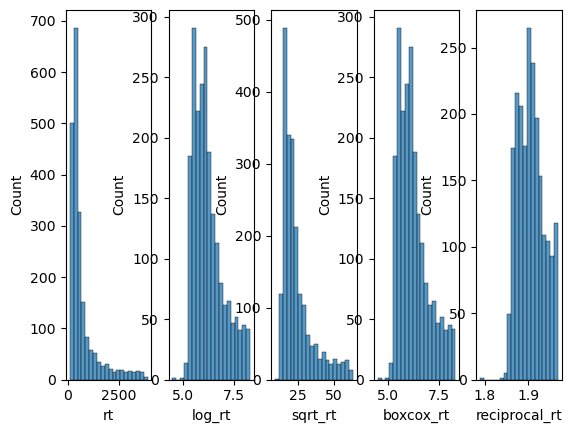

Figure saved at: C:/Users/audrey-annebeaudry/Desktop/Q1K_results/figures/rt_transformations_09_03_2025.png


In [136]:
fig, axs = plt.subplots(ncols=5)
sns.histplot(vs_grouped.rt,edgecolor='black', bins=20, ax=axs[0])
sns.histplot(vs_grouped.log_rt,edgecolor='black', bins=20, ax=axs[1])
sns.histplot(vs_grouped.sqrt_rt,edgecolor='black', bins=20, ax=axs[2])
sns.histplot(vs_grouped.boxcox_rt,edgecolor='black', bins=20, ax=axs[3])
sns.histplot(vs_grouped.reciprocal_rt,edgecolor='black', bins=20, ax=axs[4])
# Save the figure in doc folder and then doc 


# Define the correct save path
save_path = "C:/Users/audrey-annebeaudry/Desktop/Q1K_results/figures"

# Ensure the directory exists
os.makedirs(save_path, exist_ok=True)

# Save the figure
fig_path = f"{save_path}/rt_transformations_{date}.png"
plt.savefig(fig_path)

# Show the figure
plt.show()

# Add the figure to a Word document
doc = docx.Document()
doc.add_heading('Transformations figure', level=4)

# Insert the image into the document
doc.add_picture(fig_path, width=docx.shared.Inches(6), height=docx.shared.Inches(4))

print(f"Figure saved at: {fig_path}")


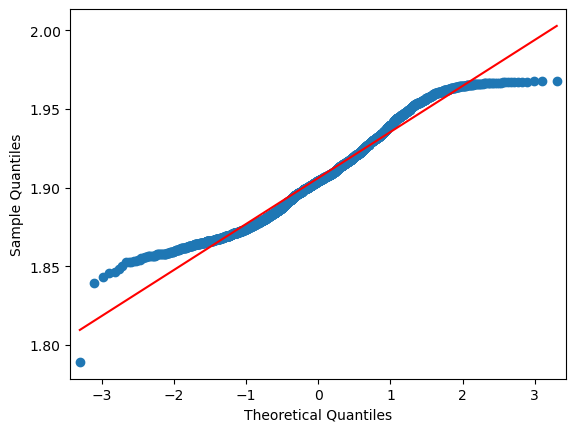

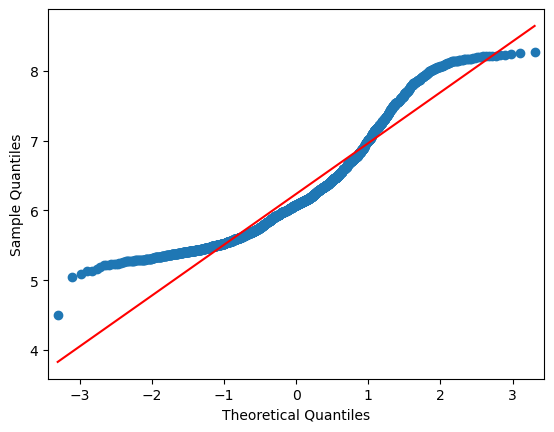

In [137]:
fig = sm.qqplot(vs_grouped.reciprocal_rt, line='s')

fig = sm.qqplot(vs_grouped.log_rt, line='s')

plt.show()

In [138]:
pg.normality(data=vs_grouped, dv='reciprocal_rt', group='condition')

,W,pval,normal
condition,,,
Nine,0.970205,2.862025e-11,False
Thirteen,0.976873,5.762503e-08,False
Five,0.964631,1.134483e-12,False


In [139]:
pg.normality(data=vs_grouped, dv='reciprocal_rt', group='detail')

,W,pval,normal
detail,,,
Single,0.949441,1.544258e-17,False
Conjunction,0.980766,3.047708e-11,False


In [140]:
# Perform normality tests for each group and condition
results=[]

for group in vs_grouped['diagnosis_group'].unique():
    for condition in vs_grouped['condition'].unique():
        subset = vs_grouped[(vs_grouped['diagnosis_group'] == group) & (vs_grouped['condition'] == condition)]
        test_result = pg.normality(subset['sqrt_rt'], method='shapiro')
        results.append({
            'diagnosis_group': group,
            'condition': condition,
            'p-value': test_result['pval'].values[0],
            'Normal': 'Yes' if test_result['pval'].values[0] > 0.05 else 'No'
        })

results_df = pd.DataFrame(results)


results_df

,diagnosis_group,condition,p-value,Normal
0,adhd,Nine,1.905866e-10,No
1,adhd,Thirteen,1.225980e-06,No
2,adhd,Five,3.858314e-08,No
3,asd,Nine,2.676051e-14,No
4,asd,Thirteen,9.207828e-14,No
5,asd,Five,6.727925e-13,No
6,control,Nine,9.601955e-26,No
7,control,Thirteen,2.923688e-22,No
8,control,Five,4.634255e-22,No


In [141]:
# Store results in a list
results = []

# Iterate over unique (asd, condition, DETAIL) combinations
for group in vs_grouped['diagnosis_group'].unique():
    for condition in vs_grouped['condition'].unique():
        for detail in vs_grouped['detail'].unique():
            
            # Subset the data
            subset = vs_grouped[
                (vs_grouped['diagnosis_group'] == group) & 
                (vs_grouped['condition'] == condition) & 
                (vs_grouped['detail'] == detail)
            ]
            
            # Ensure the subset has enough data for normality testing
            if len(subset) > 2:  # Shapiro-Wilk requires at least 3 observations
                test_result = pg.normality(subset['reciprocal_rt'], method='shapiro')
                results.append({
                    'diagnosis_group': group,
                    'condition': condition,
                    'detail': detail,
                    'p-value': test_result['pval'].values[0],
                    'Normal': 'Yes' if test_result['pval'].values[0] > 0.05 else 'No'
                })
            else:
                results.append({
                    'diagnosis_group': group,
                    'condition': condition,
                    'detail': detail,
                    'p-value': None,
                    'Normal': 'Insufficient Data'
                })

# Convert list of results into a DataFrame
results_df = pd.DataFrame(results)

# Display the results
results_df

,diagnosis_group,condition,detail,p-value,Normal
0,adhd,Nine,Single,2.769054e-01,Yes
1,adhd,Nine,Conjunction,1.381905e-01,Yes
2,adhd,Thirteen,Single,1.007994e-02,No
3,adhd,Thirteen,Conjunction,2.584559e-05,No
4,adhd,Five,Single,1.350359e-01,Yes
5,adhd,Five,Conjunction,3.986698e-02,No
6,asd,Nine,Single,2.894323e-03,No
7,asd,Nine,Conjunction,3.944393e-01,Yes
8,asd,Thirteen,Single,4.441440e-05,No
9,asd,Thirteen,Conjunction,5.213062e-02,Yes


#### Assumption of sphericity (Mauchly’s test)

In [142]:
pg.sphericity(data=vs_grouped, dv='reciprocal_rt', subject='subject', within='condition', method='mauchly')

/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


SpherResults(spher=True, W=inf, chi2=-inf, dof=2, pval=1.0)

In [143]:
# Add to doc 
if pg.sphericity(data=vs_grouped, dv='reciprocal_rt', subject='subject', within='condition')[-1] < 0.05:
    p16= "Assumption of sphericity is violated : " + str(pg.sphericity(data=vs_grouped, dv='reciprocal_rt', subject='subject', within='condition')[-1].round(4))
    print(p16)
    # Add to doc 
    doc.add_paragraph(p16, style='List Bullet')
else:
    print("Assumption of sphericity is met")
    doc.add_paragraph("Assumption of sphericity is met", style='List Bullet')


Assumption of sphericity is met


/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


#### Assumptions of Levenes test

In [144]:
# Calculte levels test assumptions 
pg.homoscedasticity(data=vs_grouped, dv='reciprocal_rt', group='diagnosis_group', method='levene')

,W,pval,equal_var
levene,0.144981,0.865048,True


#### ANOVA

In [147]:
# Run the repeated measures ANOVA for condition
res_condition = pg.rm_anova(dv="reciprocal_rt", within="condition", subject="subject", data=vs_grouped).round(4)

# Show the results
res_condition

/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,condition,2,208,11.3706,0.0,0.0193,0.9687


In [150]:
# Run the repeated measures ANOVA for condition
res_detail = pg.rm_anova(dv="reciprocal_rt", within="detail", subject="subject", data=vs_grouped)

# Show the results
res_detail

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,detail,1,104,73.529642,1.004187e-13,0.054567,1.0


In [152]:
#Mixed-anovas
anova_results = pg.rm_anova(
    data=vs_grouped, 
    dv="reciprocal_rt", 
    subject="subject",
    within=["condition", "detail"], 
    detailed=True
)

anova_results

/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,condition,0.005009,2,188,0.002504,12.976231,5.260328e-06,6.956023e-06,0.021148,0.969198
1,detail,0.015059,1,94,0.015059,77.725532,6.036909e-14,6.036909e-14,0.060993,1.000000
2,condition * detail,0.007736,2,188,0.003868,27.611043,3.065878e-11,4.347053e-11,0.032290,0.982995


In [154]:
#One-way measures ANOVA for detail
res = pg.mixed_anova(dv="reciprocal_rt", within="detail", between="diagnosis_group", subject="subject", data=vs_grouped).round(4)
res

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis_group,0.0001,2,102,0.0001,0.1076,0.8981,0.0021,NaN
1,detail,0.0044,1,102,0.0044,73.9138,0.0000,0.4202,1.0
2,Interaction,0.0002,2,102,0.0001,1.2717,0.2848,0.0243,NaN


In [155]:
#One-way measures ANOVA for detail
res = pg.mixed_anova(dv="reciprocal_rt", within="condition", between="diagnosis_group", subject="subject", data=vs_grouped).round(4)
res

/opt/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis_group,0.0005,2,102,0.0002,0.2508,0.7787,0.0049,NaN
1,condition,0.0024,2,204,0.0012,11.5327,0.0000,0.1016,0.9687
2,Interaction,0.0007,4,204,0.0002,1.7414,0.1422,0.0330,NaN


#### post hocs

In [156]:
post_hocs = pg.pairwise_tests(dv='reciprocal_rt', within=['condition', 'detail'],
                               subject='subject', between = 'diagnosis_group', padjust='fdr_bh', data=vs_grouped).round(5)
post_hocs

,Contrast,condition,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition,-,Five,Nine,True,True,4.47794,94.0,two-sided,0.00002,0.00006,fdr_bh,793.927,0.32543
1,condition,-,Five,Thirteen,True,True,4.17623,94.0,two-sided,0.00007,0.00010,fdr_bh,274.431,0.34640
2,condition,-,Nine,Thirteen,True,True,0.26610,94.0,two-sided,0.79075,0.79075,fdr_bh,0.117,0.02070
3,detail,-,Conjunction,Single,True,True,8.81621,94.0,two-sided,0.00000,NaN,NaN,1.201e+11,0.59111
4,condition * detail,Five,Conjunction,Single,True,True,0.93161,94.0,two-sided,0.35393,0.35393,fdr_bh,0.173,0.07102
5,condition * detail,Nine,Conjunction,Single,True,True,5.19249,94.0,two-sided,0.00000,0.00000,fdr_bh,1.181e+04,0.49290
6,condition * detail,Thirteen,Conjunction,Single,True,True,10.06357,94.0,two-sided,0.00000,0.00000,fdr_bh,4.529e+13,0.98738


#### Visualization

In [164]:
## Group control and detail
#cond_det was only used to viualize 

vs_grouped['cond_det'] = vs_grouped['condition']+ '_' +vs_grouped['detail']

In [165]:
vs_grouped

,subject,condition,detail,rt,vs_location_list,diagnosis_group,sex,age,n_trials,site,age_group,log_rt,sqrt_rt,reciprocal_rt,boxcox_rt,cond_det
0,1009S1,Nine,Single,344,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",adhd,1,13.801789,23,hsj,child,5.840642,18.547237,1.892167,5.840812,Nine_Single
1,1009S1,Thirteen,Single,244,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",adhd,1,13.801789,23,hsj,child,5.497168,15.620499,1.871963,5.497319,Thirteen_Single
2,1009S1,Nine,Single,197,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",adhd,1,13.801789,23,hsj,child,5.283204,14.035669,1.857506,5.283343,Nine_Single
3,1009S1,Five,Conjunction,311,"(8, 9, 10, 15, 1)",adhd,1,13.801789,23,hsj,child,5.739793,17.635192,1.886590,5.739958,Five_Conjunction
4,1009S1,Five,Conjunction,235,"(11, 5, 8, 6, 0)",adhd,1,13.801789,23,hsj,child,5.459586,15.329710,1.869534,5.459735,Five_Conjunction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,1121M1,Five,Conjunction,282,"(5, 9, 4, 15, 6)",asd,1,39.310983,23,hsj,adult,5.641907,16.792856,1.880902,5.642066,Five_Conjunction
2101,1121M1,Nine,Conjunction,237,"(3, 12, 1, 6, 2, 11, 15, 16, 10)",asd,1,39.310983,23,hsj,adult,5.468060,15.394804,1.870086,5.468210,Nine_Conjunction
2102,1121M1,Nine,Conjunction,170,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",asd,1,39.310983,23,hsj,adult,5.135798,13.038405,1.846607,5.135930,Nine_Conjunction
2103,1121M1,Thirteen,Conjunction,258,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",asd,1,39.310983,23,hsj,adult,5.552960,16.062378,1.875485,5.553114,Thirteen_Conjunction


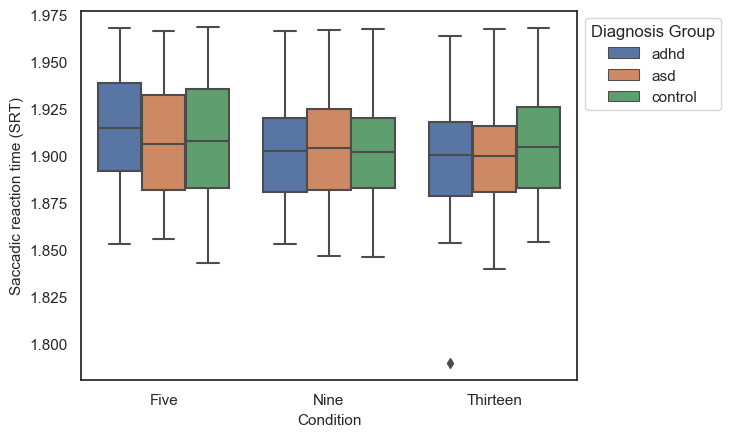

In [166]:
sns.set_theme(style='white')
order = ["Five", "Nine", "Thirteen"]
ax=sns.boxplot(x="condition", y="reciprocal_rt",hue = 'diagnosis_group', data=vs_grouped,order=order )#,estimator=np.mean, ci = 0.95, capsize=.2,
            #palette="coolwarm").set_title("",fontsize=18)

plt.grid(False)
plt.ylabel('Saccadic reaction time (SRT)',fontsize=11)
plt.xlabel('Condition',fontsize=11)
plt.legend(loc='upper right')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Diagnosis Group')

# Show the figure
plt.show()



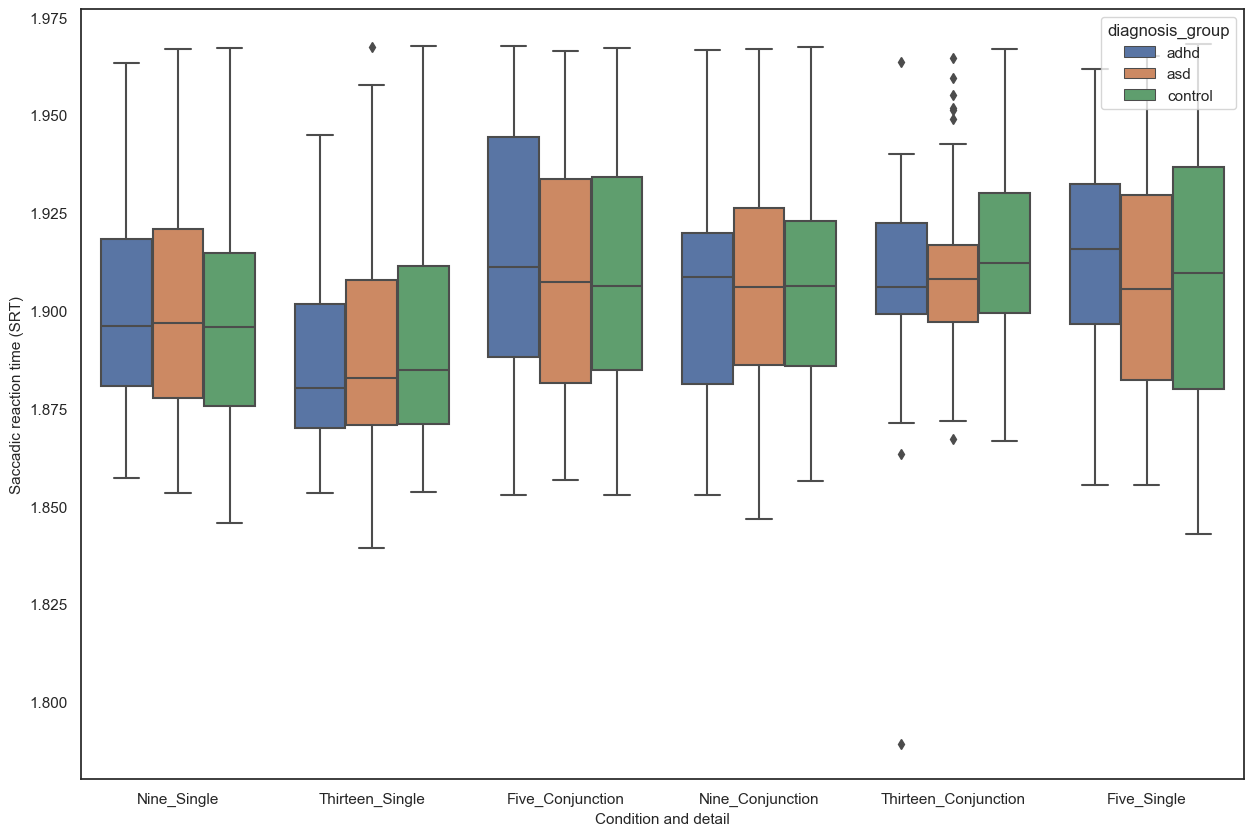

In [167]:
plt.figure(figsize= (15, 10))
# Set theme

sns.set_theme(style='white')

# Define order
#order = ["Five", "Nine", "Thirteen"]
#detail_order = ['Conjunction', 'Single_Slice', 'Single_Apple']

# Create boxplot with detail as hue
ax = sns.boxplot(x="cond_det", y="reciprocal_rt", hue="diagnosis_group", 
                 data=vs_grouped)

# Adjust labels and grid
plt.grid(False)
plt.ylabel('Saccadic reaction time (SRT)', fontsize=11)
plt.xlabel('Condition and detail', fontsize=11)

# Add legend
plt.legend(title="diagnosis_group", loc='upper right')

# Show plot
plt.show()



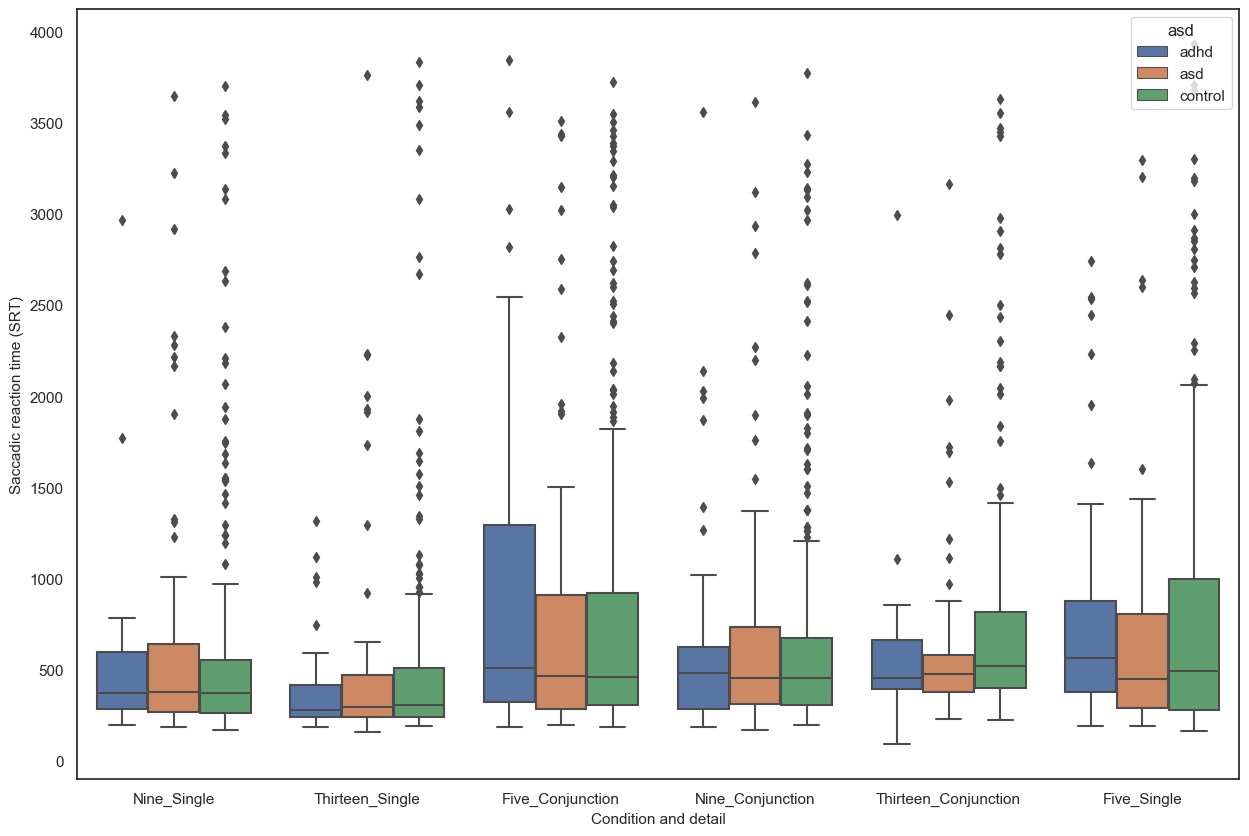

In [168]:
plt.figure(figsize= (15, 10))
# Set theme

sns.set_theme(style='white')

# Define order
#order = ["Five", "Nine", "Thirteen"]
#detail_order = ['Conjunction', 'Single_Slice', 'Single_Apple']

# Create boxplot with detail as hue
ax = sns.boxplot(x="cond_det", y="rt", hue="diagnosis_group", 
                 data=vs_grouped)

# Adjust labels and grid
plt.grid(False)
plt.ylabel('Saccadic reaction time (SRT)', fontsize=11)
plt.xlabel('Condition and detail', fontsize=11)

# Add legend
plt.legend(title="asd", loc='upper right')

# Show plot
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


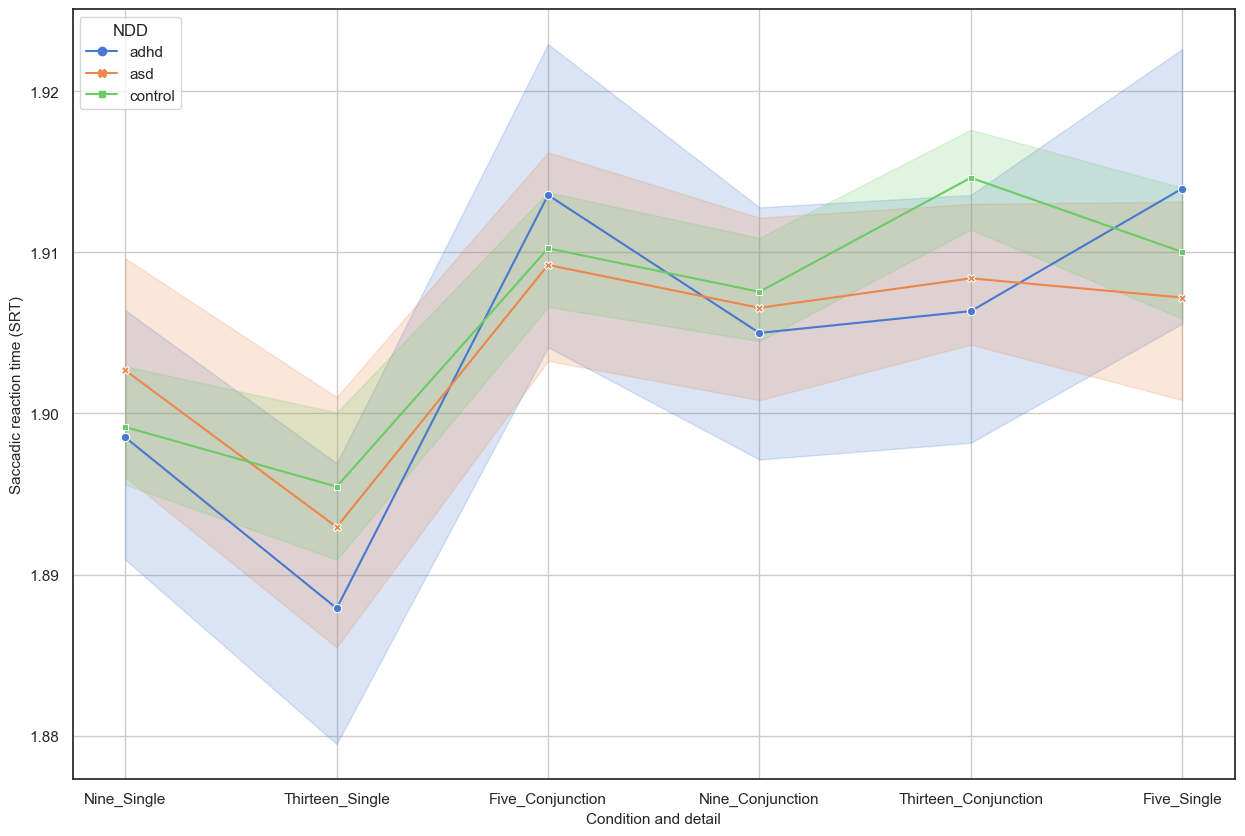

In [169]:
plt.figure(figsize = (15, 10))
# Set theme
sns.set_theme(style='white')

# Define order for condition
#order = ["Five", "Nine", "Thirteen"]

# Create lineplot with 'detail' as hue and 'asd' as style
ax = sns.lineplot(x="cond_det", y="reciprocal_rt", 
                  hue="diagnosis_group", style="diagnosis_group",
                  data=vs_grouped, 
                  markers=True, dashes=False, 
                  palette="muted") 
                  #hue_order=["Conjunction", "Single_Slice", "Single_Apple"])

# Adjust labels and grid
plt.grid(True)
plt.ylabel('Saccadic reaction time (SRT)', fontsize=11)
plt.xlabel('Condition and detail', fontsize=11)

# Add legend
plt.legend(title="NDD", loc='upper left')

# Show plot
plt.show()

### Exploratory analyses

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

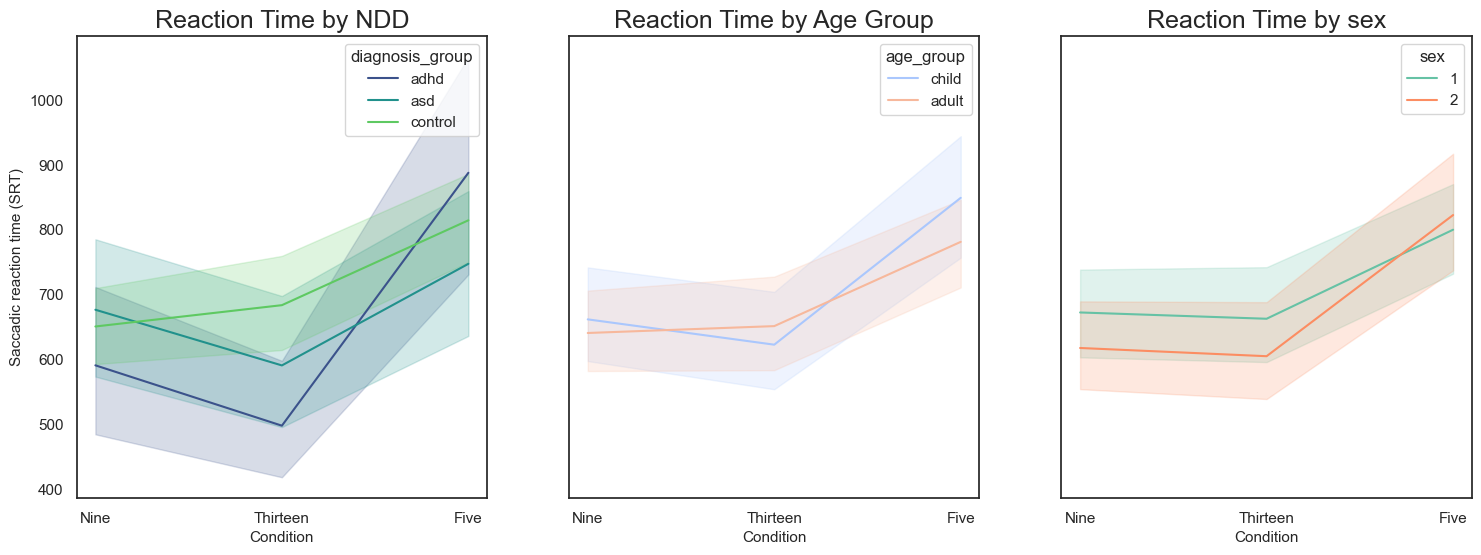

In [170]:
# Make thre pltos for reaction times for each sex and age group
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.set_theme(style="white")

order = ["Five", "Nine","Thirteen"]
sns.lineplot(x="condition", y="rt", data=vs_grouped,hue = "diagnosis_group", ax=ax[0], #this is normal rt, can be done with reciprecal_rt; can also be done with detail instead of condition
            palette="viridis").set_title("",fontsize=18)

sns.lineplot(x="condition", y="rt", data=vs_grouped,hue ="age_group", ax=ax[1],
            palette="coolwarm").set_title("",fontsize=18)

sns.lineplot(x="condition", y="rt", data=vs_grouped,hue= "sex", ax=ax[2],
            palette="Set2").set_title("",fontsize=18)


# Add titles to the plots
ax[0].set_title('Reaction Time by NDD',fontsize=18)
ax[1].set_title('Reaction Time by Age Group',fontsize=18)
ax[2].set_title('Reaction Time by sex',fontsize=18)

# Add labels to the plots
ax[0].set_ylabel('Saccadic reaction time (SRT)',fontsize=11)
ax[0].set_xlabel('Condition',fontsize=11)


ax[1].set_ylabel('Saccadic reaction time (SRT)',fontsize=11)
ax[1].set_xlabel('Condition',fontsize=11)

ax[2].set_ylabel('Saccadic reaction time (SRT)',fontsize=11)
ax[2].set_xlabel('Condition',fontsize=11)


# Show the figure
plt.show()



## Linear model analysis 

In [171]:
# Add logrt to the df
######################################################
rt_sub["reciprocal_rt"] = boxcox(rt_sub.rt,-0.5)

In [172]:
rt_sub['cond_det'] = rt_sub['condition']+'_'+rt_sub['detail']

In [173]:
vs_dis=rt_sub[["subject","cond_det", "condition", "detail", "reciprocal_rt", "rt", "vs_location_list"]]

In [174]:
vs_dis=vs_dis.groupby(["subject","cond_det", "condition", "detail", "vs_location_list"]).mean().reset_index()

In [175]:
vs_grouped= vs_dis


In [176]:
## Add demographic back to vs_grouped
vs_grouped=pd.merge(vs_grouped, outlier_demo, on="subject", how="inner")

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


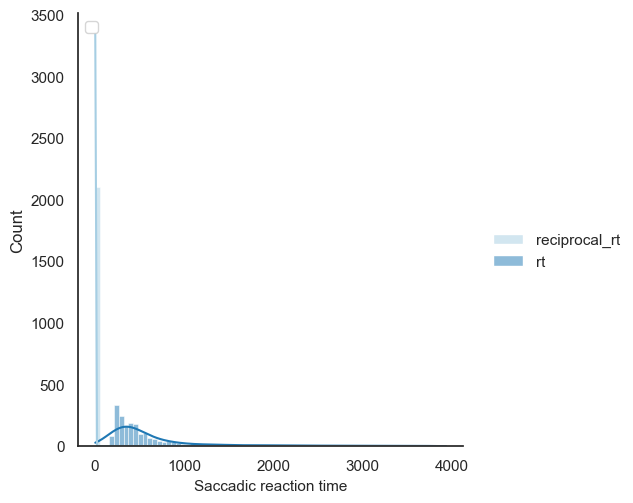

In [178]:
sns.displot(data=vs_dis, palette="Paired", kde=True)
plt.xlabel('Saccadic reaction time',fontsize=11)
plt.legend(loc='upper left')

In [179]:
# Add a column with total number of trrials and one for overall RT
rt_sub["total_trials"]=rt_sub.groupby("subject")["rt"].transform("count")
rt_sub["overall_rt"]=rt_sub.groupby("subject")["rt"].transform("mean")
rt_sub
#reaction time get longer with fatigue , drop is different for adhd ...

,index,subject,Trial_Index_,condition,detail,rt,VS_VALID,vs_location_list,age,group,...,sex,asd,adhd,record_id,age_group,diagnosis_group,reciprocal_rt,cond_det,total_trials,overall_rt
1,1,1009S1,2,Nine,Single,344,True,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",13.801789,sibling,...,1,Unknown,1.0,525-1011,child,adhd,1.892167,Nine_Single,23,270.304348
2,2,1009S1,3,Thirteen,Single,244,True,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",13.801789,sibling,...,1,Unknown,1.0,525-1011,child,adhd,1.871963,Thirteen_Single,23,270.304348
4,4,1009S1,5,Nine,Single,197,True,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",13.801789,sibling,...,1,Unknown,1.0,525-1011,child,adhd,1.857506,Nine_Single,23,270.304348
6,6,1009S1,7,Five,Conjunction,311,True,"(8, 9, 10, 15, 1)",13.801789,sibling,...,1,Unknown,1.0,525-1011,child,adhd,1.886590,Five_Conjunction,23,270.304348
7,7,1009S1,8,Five,Conjunction,235,True,"(11, 5, 8, 6, 0)",13.801789,sibling,...,1,Unknown,1.0,525-1011,child,adhd,1.869534,Five_Conjunction,23,270.304348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2763,3232,1121M1,24,Five,Conjunction,282,True,"(5, 9, 4, 15, 6)",39.310983,mother,...,1,1.0,1.0,525-1123,adult,asd,1.880902,Five_Conjunction,23,439.826087
2764,3233,1121M1,25,Nine,Conjunction,237,True,"(3, 12, 1, 6, 2, 11, 15, 16, 10)",39.310983,mother,...,1,1.0,1.0,525-1123,adult,asd,1.870086,Nine_Conjunction,23,439.826087
2765,3234,1121M1,26,Nine,Conjunction,170,True,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",39.310983,mother,...,1,1.0,1.0,525-1123,adult,asd,1.846607,Nine_Conjunction,23,439.826087
2768,3237,1121M1,29,Thirteen,Conjunction,258,True,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",39.310983,mother,...,1,1.0,1.0,525-1123,adult,asd,1.875485,Thirteen_Conjunction,23,439.826087


In [180]:
# Merge df wih demogroupic data
rt_sub[["subject", "total_trials", "overall_rt", "diagnosis_group", "site", "sex","age", "age_group", "condition", "detail", "cond_det"]].drop_duplicates()

,subject,total_trials,overall_rt,diagnosis_group,site,sex,age,age_group,condition,detail,cond_det
1,1009S1,23,270.304348,adhd,hsj,1,13.801789,child,Nine,Single,Nine_Single
2,1009S1,23,270.304348,adhd,hsj,1,13.801789,child,Thirteen,Single,Thirteen_Single
6,1009S1,23,270.304348,adhd,hsj,1,13.801789,child,Five,Conjunction,Five_Conjunction
9,1009S1,23,270.304348,adhd,hsj,1,13.801789,child,Nine,Conjunction,Nine_Conjunction
12,1009S1,23,270.304348,adhd,hsj,1,13.801789,child,Thirteen,Conjunction,Thirteen_Conjunction
...,...,...,...,...,...,...,...,...,...,...,...
2741,1121M1,23,439.826087,asd,hsj,1,39.310983,adult,Nine,Single,Nine_Single
2742,1121M1,23,439.826087,asd,hsj,1,39.310983,adult,Thirteen,Single,Thirteen_Single
2746,1121M1,23,439.826087,asd,hsj,1,39.310983,adult,Five,Conjunction,Five_Conjunction
2749,1121M1,23,439.826087,asd,hsj,1,39.310983,adult,Nine,Conjunction,Nine_Conjunction


In [181]:
# 
rt_demo = rt_sub[["subject", "total_trials", "overall_rt", "diagnosis_group", "site", "sex","age", "age_group"]].drop_duplicates()

## Mixed effects linear modelling

### Linear model for condition (asd, sex, age, site)

In [185]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "reciprocal_rt ~ C(diagnosis_group, Treatment(reference = 'control'))  * condition + age + sex + site"

# Fit the model
model = smf.mixedlm(model_formula, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
============================================================================================================================
Model:                                   MixedLM                      Dependent Variable:                      reciprocal_rt
No. Observations:                        2105                         Method:                                  REML         
No. Groups:                              105                          Scale:                                   0.0006       
Min. group size:                         4                            Log-Likelihood:                          4632.9807    
Max. group size:                         25                           Converged:                               Yes          
Mean group size:                         20.0                                                                               
----------------------------------------------------------------------------------------------------------------------------
                                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         1.914    0.008 242.296 0.000  1.898  1.929
C(diagnosis_group, Treatment(reference='control'))[T.adhd]                        0.003    0.006   0.418 0.676 -0.009  0.014
C(diagnosis_group, Treatment(reference='control'))[T.asd]                        -0.001    0.005  -0.275 0.784 -0.012  0.009
condition[T.Nine]                                                                -0.005    0.002  -3.455 0.001 -0.009 -0.002
condition[T.Thirteen]                                                            -0.003    0.002  -2.010 0.044 -0.007 -0.000
site[T.mni]                                                                       0.003    0.004   0.894 0.371 -0.004  0.011
C(diagnosis_group, Treatment(reference='control'))[T.adhd]:condition[T.Nine]     -0.004    0.004  -0.974 0.330 -0.011  0.004
C(diagnosis_group, Treatment(reference='control'))[T.asd]:condition[T.Nine]       0.002    0.003   0.500 0.617 -0.005  0.008
C(diagnosis_group, Treatment(reference='control'))[T.adhd]:condition[T.Thirteen] -0.011    0.004  -2.559 0.010 -0.019 -0.003
C(diagnosis_group, Treatment(reference='control'))[T.asd]:condition[T.Thirteen]  -0.003    0.003  -0.882 0.378 -0.009  0.004
age                                                                              -0.000    0.000  -0.155 0.876 -0.000  0.000
sex                                                                              -0.002    0.004  -0.458 0.647 -0.009  0.006
Group Var                                                                         0.000    0.002                            
============================================================================================================================

"""

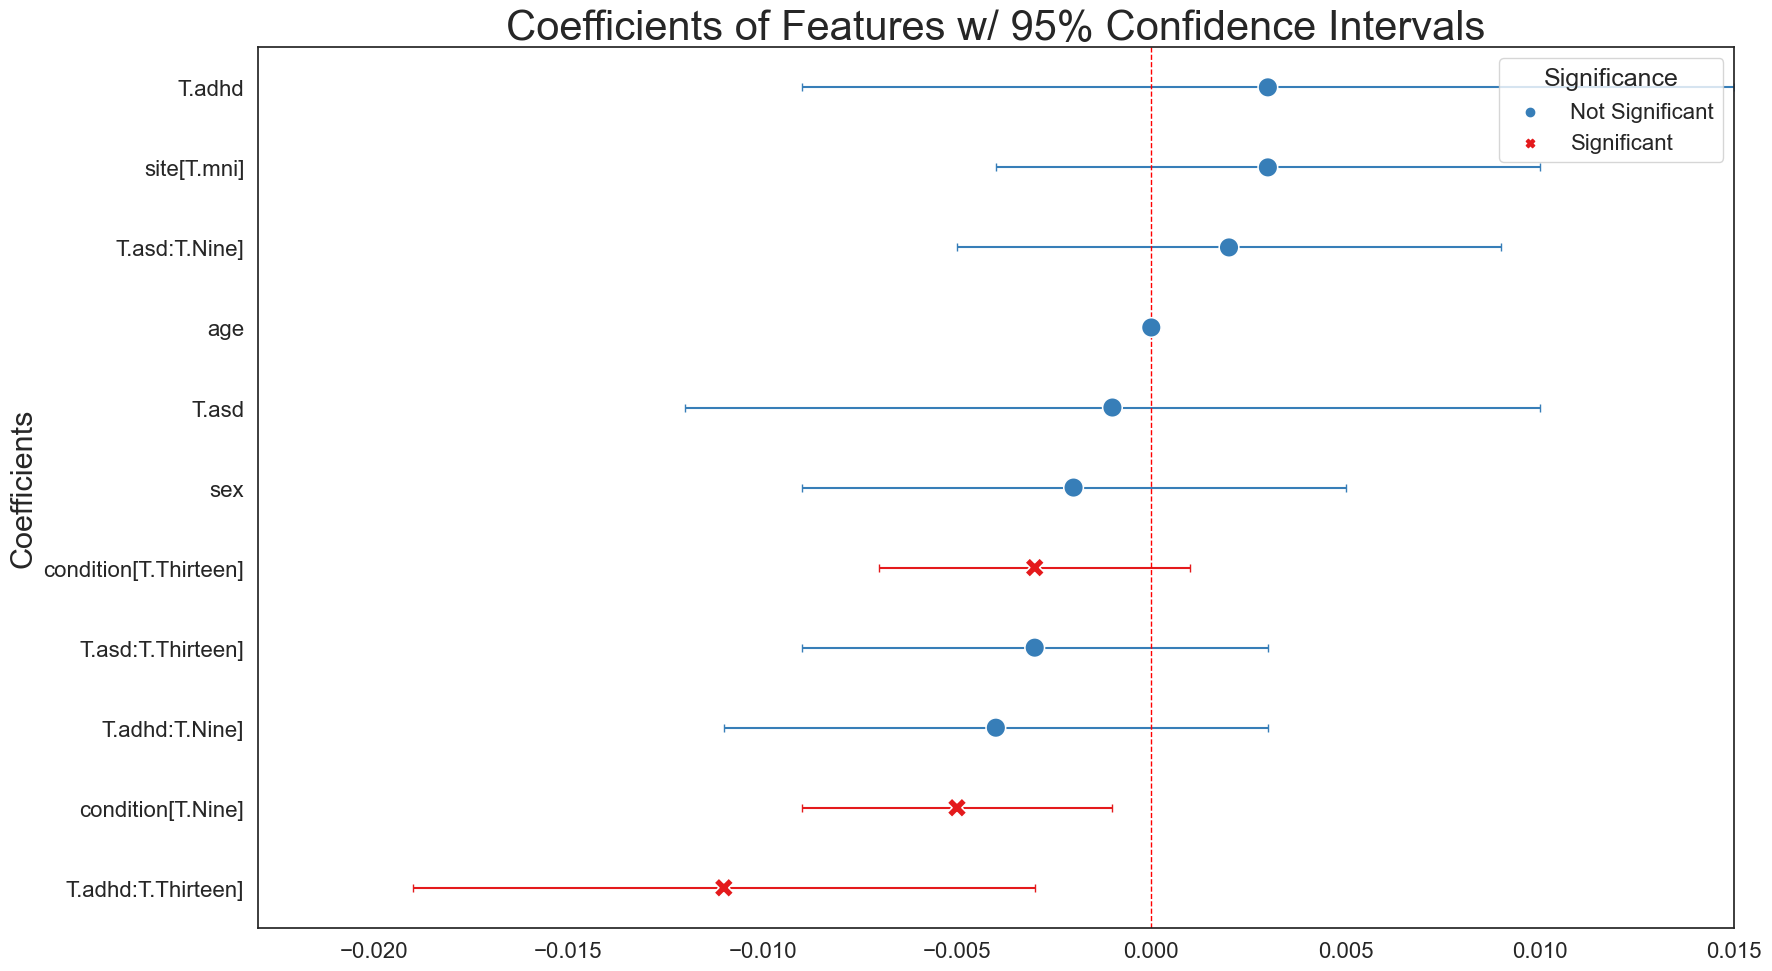

In [186]:
plt.rcParams.update({
    'font.size': 16,       # Base font size for ticks and text
    'axes.titlesize': 30,  # Title font
    'axes.labelsize': 22,  # Axis label font
    'xtick.labelsize': 16, # X-tick font
    'ytick.labelsize': 16, # Y-tick font
    'legend.fontsize': 16, # Legend font
    'legend.title_fontsize': 18  # Legend title font
})
coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')
#nothing matters other than conditions (Faster 13 or 9)

## Linear model for detail (asd, sex, age, site)

In [187]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model 
model_formula = "reciprocal_rt ~ C(diagnosis_group, Treatment(reference = 'control')) * detail + age + sex + site"

# Fit the model
model = smf.mixedlm(model_formula, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                         Mixed Linear Model Regression Results
=======================================================================================================================
Model:                                MixedLM                     Dependent Variable:                     reciprocal_rt
No. Observations:                     2105                        Method:                                 REML         
No. Groups:                           105                         Scale:                                  0.0006       
Min. group size:                      4                           Log-Likelihood:                         4668.2849    
Max. group size:                      25                          Converged:                              Yes          
Mean group size:                      20.0                                                                             
-----------------------------------------------------------------------------------------------------------------------
                                                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                                                    1.915    0.008 237.737 0.000  1.899  1.931
C(diagnosis_group, Treatment(reference='control'))[T.adhd]                  -0.002    0.006  -0.414 0.679 -0.014  0.009
C(diagnosis_group, Treatment(reference='control'))[T.asd]                   -0.004    0.005  -0.718 0.473 -0.014  0.006
detail[T.Single]                                                            -0.010    0.001  -7.663 0.000 -0.013 -0.008
site[T.mni]                                                                  0.003    0.004   0.898 0.369 -0.004  0.011
C(diagnosis_group, Treatment(reference='control'))[T.adhd]:detail[T.Single]  0.002    0.003   0.647 0.518 -0.004  0.009
C(diagnosis_group, Treatment(reference='control'))[T.asd]:detail[T.Single]   0.004    0.003   1.459 0.145 -0.001  0.009
age                                                                         -0.000    0.000  -0.104 0.917 -0.000  0.000
sex                                                                         -0.002    0.004  -0.420 0.674 -0.009  0.006
Group Var                                                                    0.000    0.002                            
=======================================================================================================================

"""

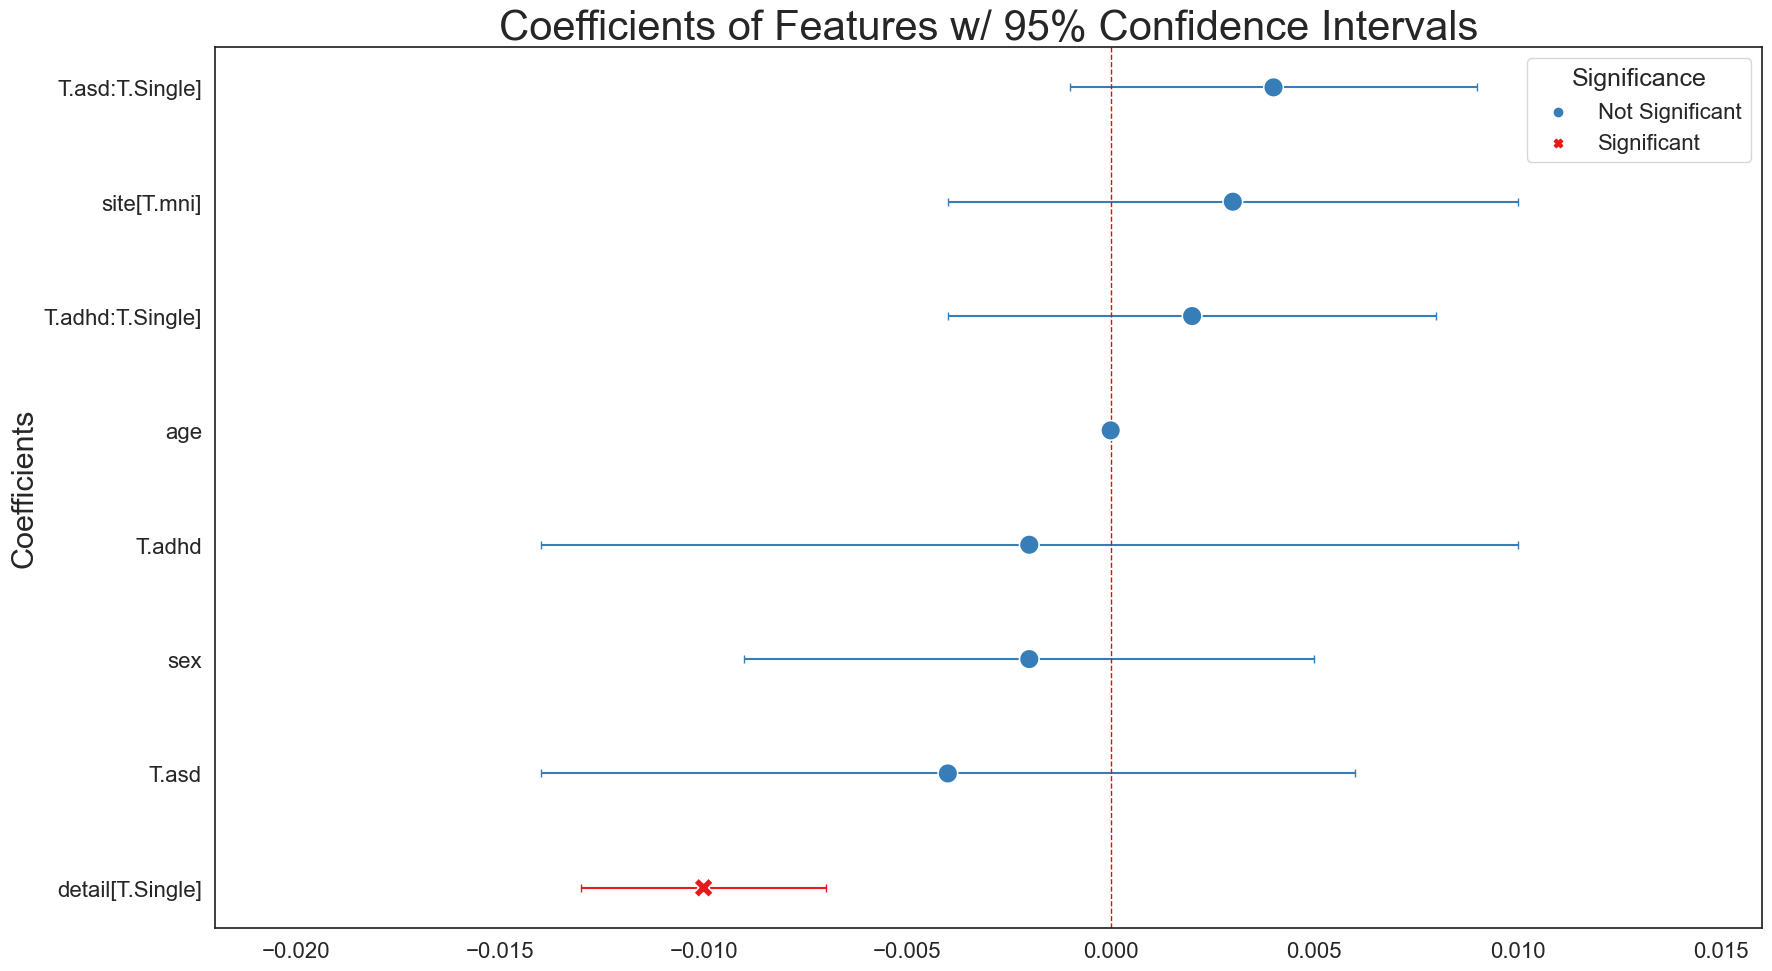

In [188]:

coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')

In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
model_comparison = {}
models_comp= {"original": "reciprocal_rt ~ diagnosis_group * condition + age + sex + site", 
                "no_interaction": "reciprocal_rt ~ diagnosis_group + condition + age + sex + site",
                "no_age": "reciprocal_rt ~ diagnosis_group * condition + sex + site",
                "no_covariates": "reciprocal_rt ~ diagnosis_group * condition"}
coeff_dfs = []
model_comparisons_list = []
model_coefficients = []

for model_name, model_formula in models_comp.items():

    model1 = smf.mixedlm(model_formula, vs_grouped, groups=vs_grouped["subject"], re_formula="1").fit( reml=False)
    # Compare models
    coeff_dfs = []

    # Print the model
    print(model_name,model1.summary())

    #****** IF YOU WANT TO COMPARE MANY MODELS models = [model, model2, model3, model4, model5]
    models = [model1]

    log_likelihoods = [model.llf for model in models]
    aic = [model.aic for model in models]
    bic = [model.bic for model in models]
    converged = [model.converged for model in models]
    # Create dictionary with model names
    model_names = ["Mix Rand-int"]

    model_comparison = pd.DataFrame({"log_likelihood": log_likelihoods, "aic": aic, "bic": bic, "converged":converged }, index=model_names)
    # Collect homoscedasticity test results
    hom_test_results = []


    for model in models:
        hom_test_df = check_homoscedasticity(model, vs_grouped, show_text=False, co_vars=["age", "outcome", "sex", "site"])
        hom_test_results.append(hom_test_df.iloc[0])  # Assuming results are in a single row

        coeff_df = stage_model(model)
        coeff_dfs.append(coeff_df)


    # Convert list of series to a DataFrame
    hom_test_df_combined = pd.DataFrame(hom_test_results, index=model_comparison.index)

    # Merge with model comparison DataFrame
    model_comparison = pd.concat([model_comparison, hom_test_df_combined], axis=1)
    print(model_comparison)

    # Print model comparison results


   
    # Create df with all coefficients
    all_coefs = pd.concat(coeff_dfs, keys=model_names).reset_index()

    all_coefs["model_name"] = model_name
    all_coefs["model"] = model_name
    # Append all coeffts
    model_coefficients.append(all_coefs)
    model_comparisons_list.append(model_comparison)
# Create a df with all model comparisons
model_comparisons_df = pd.concat(model_comparisons_list, keys=models_comp.keys()).reset_index()
model_coefficients_df = pd.concat(model_coefficients)


#coefplot_gap(model_coefficients_df, multiple_models=True, fig_name="all_models")


# Drop unwanted columns
model_coefficients_df.drop(columns=["level_1","model_name"], inplace=True)
model_coefficients_df.rename(columns={"level_0": "model"}, inplace=True)
model_comparisons_df.drop(columns=["level_1"], inplace=True)
model_comparisons_df.rename(columns={"level_0": "model"}, inplace=True)


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


original                            Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            reciprocal_rt
No. Observations:            2105               Method:                        ML           
No. Groups:                  105                Scale:                         0.0006       
Min. group size:             4                  Log-Likelihood:                4695.4890    
Max. group size:             25                 Converged:                     Yes          
Mean group size:             20.0                                                           
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.916    0.008 231.107 0.000  1.900  1.

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Residuals are not homoscedastic LeveneResult(statistic=8.894262593567385, pvalue=7.418113851900602e-06)
Homoscedasticiyy checked
              log_likelihood          aic          bic  converged  \
Mix Rand-int     4695.489026 -9362.978053 -9283.849062       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.000007    0.280393  7.444800e-101      0.000083   

              multicollinearity      age      sex     site  
Mix Rand-int          10.071639  0.47021  0.35427  0.23357  


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Residuals are not homoscedastic LeveneResult(statistic=8.893968713230558, pvalue=7.421230821442025e-06)
Homoscedasticiyy checked
              log_likelihood          aic          bic  converged  \
Mix Rand-int     4695.475077 -9364.950153 -9291.473233       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.000007     0.58689  7.708522e-101      0.000082   

              multicollinearity      age      sex     site  
Mix Rand-int          10.071378  0.47017  0.35407  0.23421  


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


no_covariates                            Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            reciprocal_rt
No. Observations:            2105               Method:                        ML           
No. Groups:                  105                Scale:                         0.0006       
Min. group size:             4                  Log-Likelihood:                4694.9817    
Max. group size:             25                 Converged:                     Yes          
Mean group size:             20.0                                                           
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.913    0.005 371.459 0.000  1.90

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


In [190]:
model_comparisons_df

,model,log_likelihood,aic,bic,converged,levene_test_all,white_test,bartlett_test,shapiro_test,multicollinearity,age,sex,site
0,original,4695.489026,-9362.978053,-9283.849062,True,7.418114e-06,0.280393,7.444800e-101,0.000083,10.071639,0.47021,0.35427,0.23357
1,no_interaction,4691.604332,-9363.208663,-9306.687956,True,5.149111e-07,0.212269,8.240528e-104,0.000024,2.424531,0.49514,0.42061,0.27900
2,no_age,4695.475077,-9364.950153,-9291.473233,True,7.421231e-06,0.586890,7.708522e-101,0.000082,10.071378,0.47017,0.35407,0.23421
3,no_covariates,4694.981665,-9367.963330,-9305.790551,True,5.220288e-06,0.657158,8.042527e-101,0.000085,10.069750,0.47039,0.36159,0.24049


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/2390626922.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)


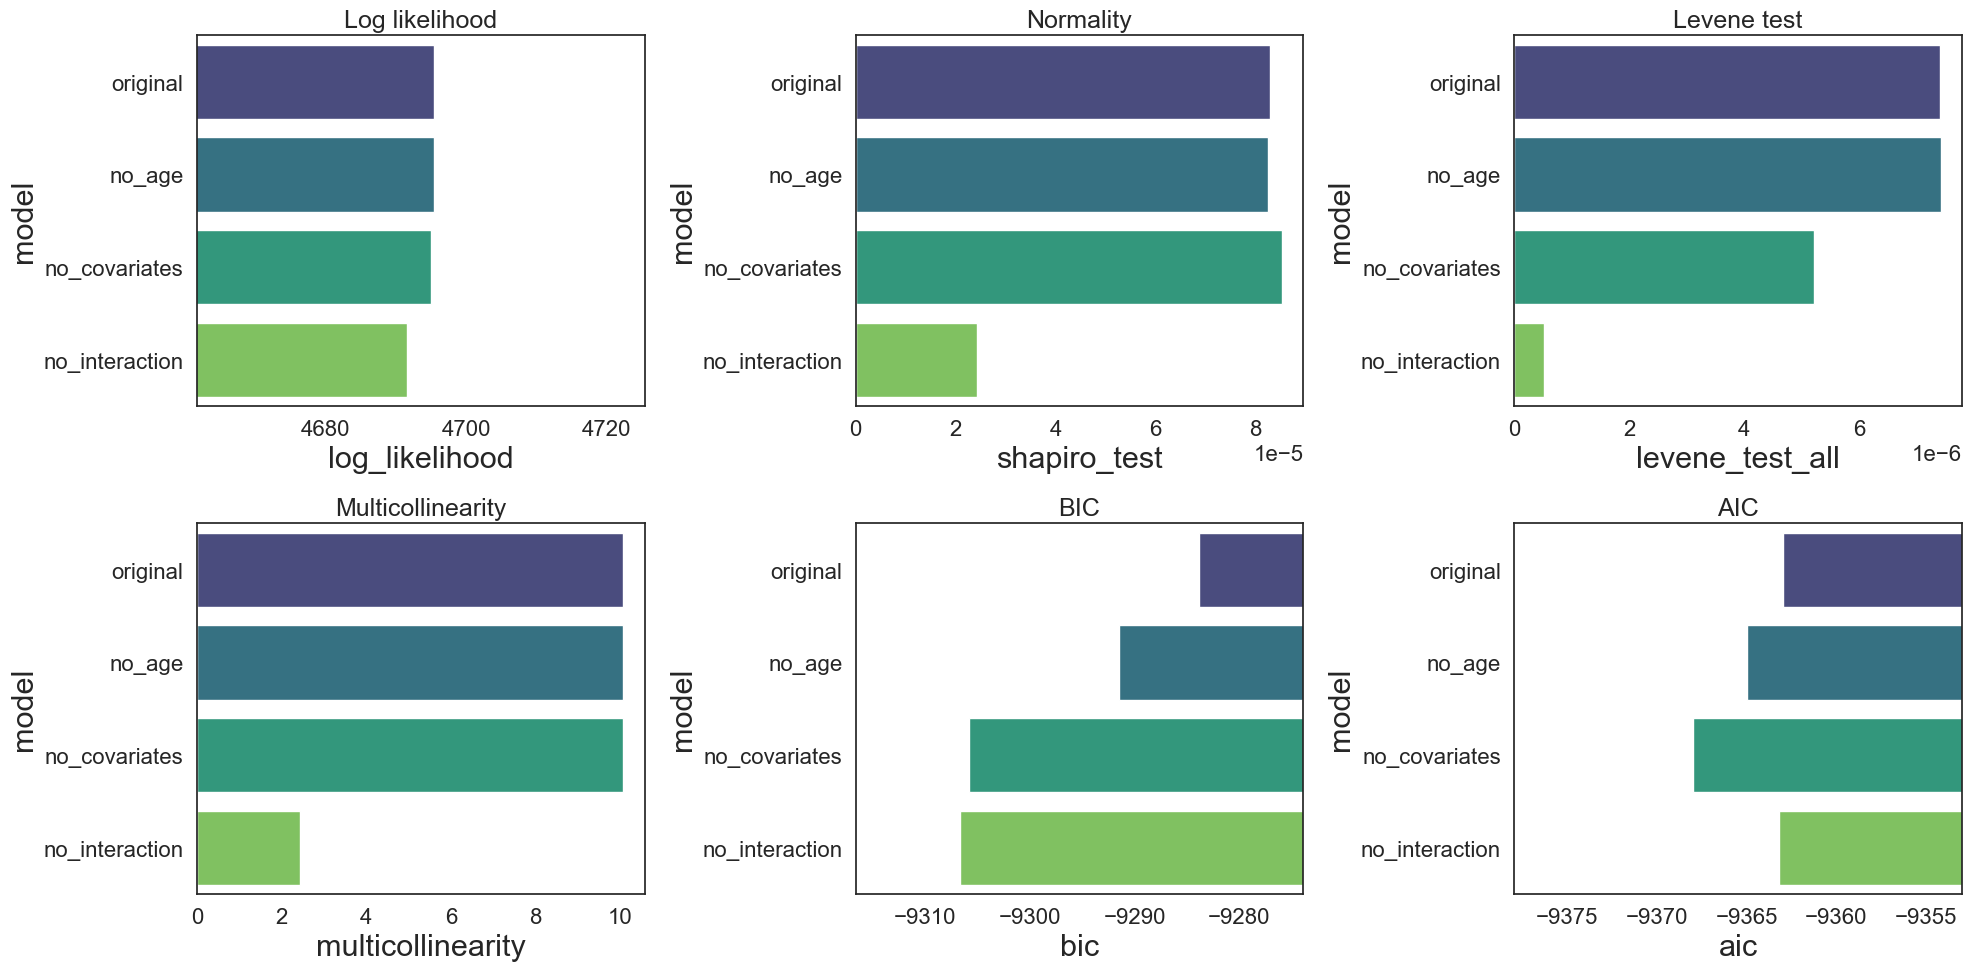

In [191]:
# Plot the different models and sort them by log likelihood

# Megerge all stages

model_comparisons_df["stage"]= "Standard"
model_comparisons_df_stages = model_comparisons_df.copy()

model_comparisons_df_stages = model_comparisons_df_stages.sort_values(by="log_likelihood", ascending=False)

# Plot the different models and sort them by log likelihood

model_comparisons_df = model_comparisons_df.sort_values(by="log_likelihood", ascending=False)

# Plot
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Plot log likelihood
sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)

# Calculate min and max of log_likelihood
log_likelihood_min = model_comparisons_df["log_likelihood"].min() - 30
log_likelihood_max = model_comparisons_df["log_likelihood"].max() + 30

# Set x-axis limits for ax[0, 0]
ax[0, 0].set_xlim(log_likelihood_min, log_likelihood_max)

# Plot Shapiro test
sns.barplot(x="shapiro_test", y="model", data=model_comparisons_df, ax=ax[0, 1], palette="viridis")

# Plot White test
sns.barplot(x="levene_test_all", y="model", data=model_comparisons_df, ax=ax[0, 2], palette="viridis")

# Plot Multicollinearity
sns.barplot(x="multicollinearity", y="model", data=model_comparisons_df, ax=ax[1, 0], palette="viridis")

# Plot BIC
sns.barplot(x="bic", y="model", data=model_comparisons_df, ax=ax[1, 1], palette="viridis")

# Calculate min and max of BIC
bic_min = model_comparisons_df["bic"].min() - 10
bic_max = model_comparisons_df["bic"].max() + 10

# Set x-axis limits for ax[1, 1]
ax[1, 1].set_xlim(bic_min, bic_max)


# Plot AIC
sns.barplot(x="aic", y="model", data=model_comparisons_df, ax=ax[1, 2], palette="viridis")

# Calculate min and max of AIC
aic_min = model_comparisons_df["aic"].min() - 10
aic_max = model_comparisons_df["aic"].max() + 10

# Set x-axis limits for ax[1, 2]
ax[1, 2].set_xlim(aic_min, aic_max)

# Add titles
ax[0, 0].set_title("Log likelihood", fontsize=18)
ax[0, 1].set_title("Normality", fontsize=18)
ax[0, 2].set_title("Levene test", fontsize=18)
ax[1, 0].set_title("Multicollinearity", fontsize=18)
ax[1, 1].set_title("BIC", fontsize=18)
ax[1, 2].set_title("AIC", fontsize=18)

# Change x-axis limits for the log likelihood plot
# ax[0, 0].set_xlim(1330, 1405)

plt.tight_layout()
plt.show()

### Compare best 2 models (no age, no covariance)

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


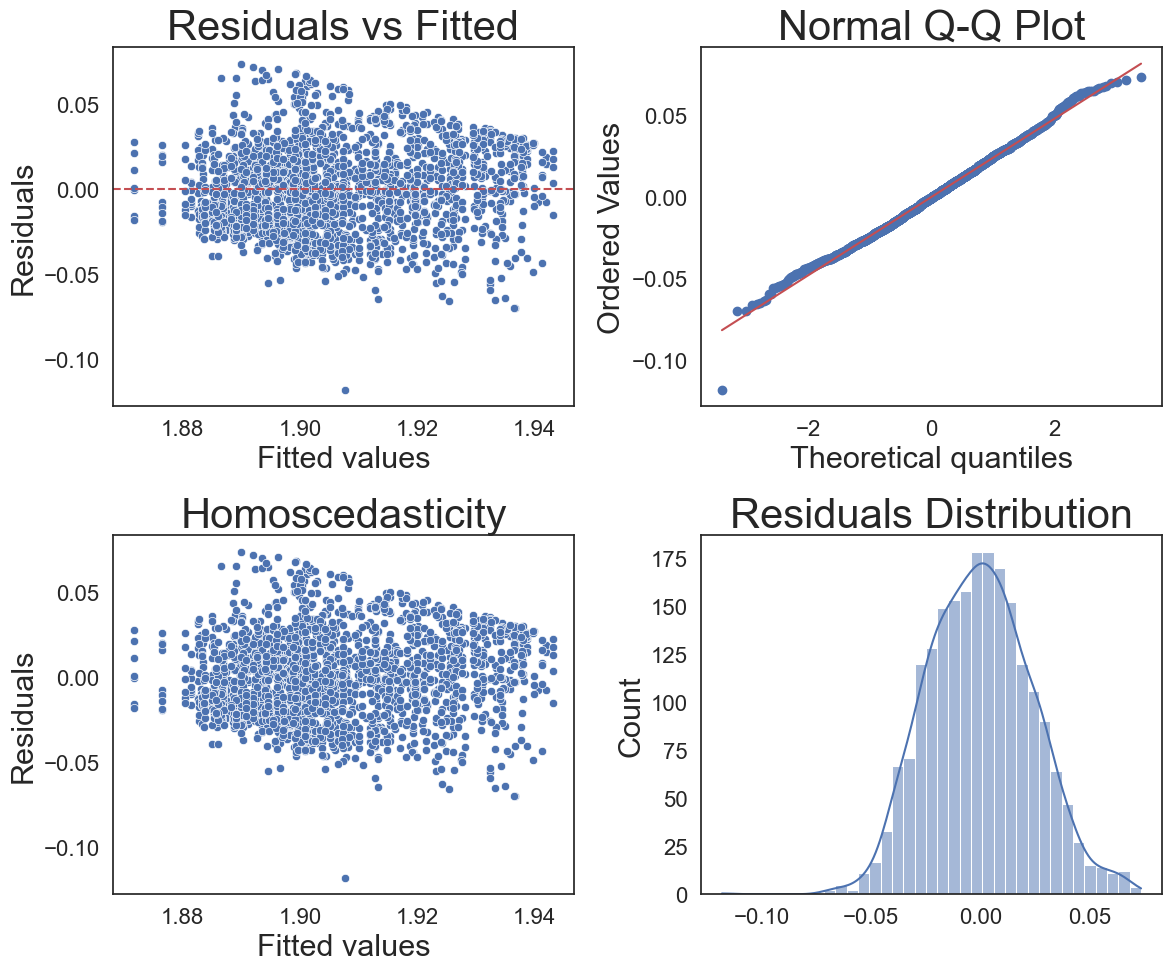

Shapiro-Wilk test p-value: 9.43401173572056e-05
Residuals are not homoscedastic LeveneResult(statistic=8.903306491356219, pvalue=7.322828313105944e-06)


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Bartlett’s test p-value: 1.6419330256097192e-98
White test p-value: 0.5899285419593098
Levene’s test p-value for the whole model: 7.322828313105944e-06
Levene’s test p-value for variable age: 0.4700250557238125
Levene’s test p-value for variable sex: 0.3524624678000078
Levene’s test p-value for variable site: 0.23740074381408657
Levene’s test p-value for variable diagnosis_group: 0.6336178044217886
Homoscedasticiyy checked


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


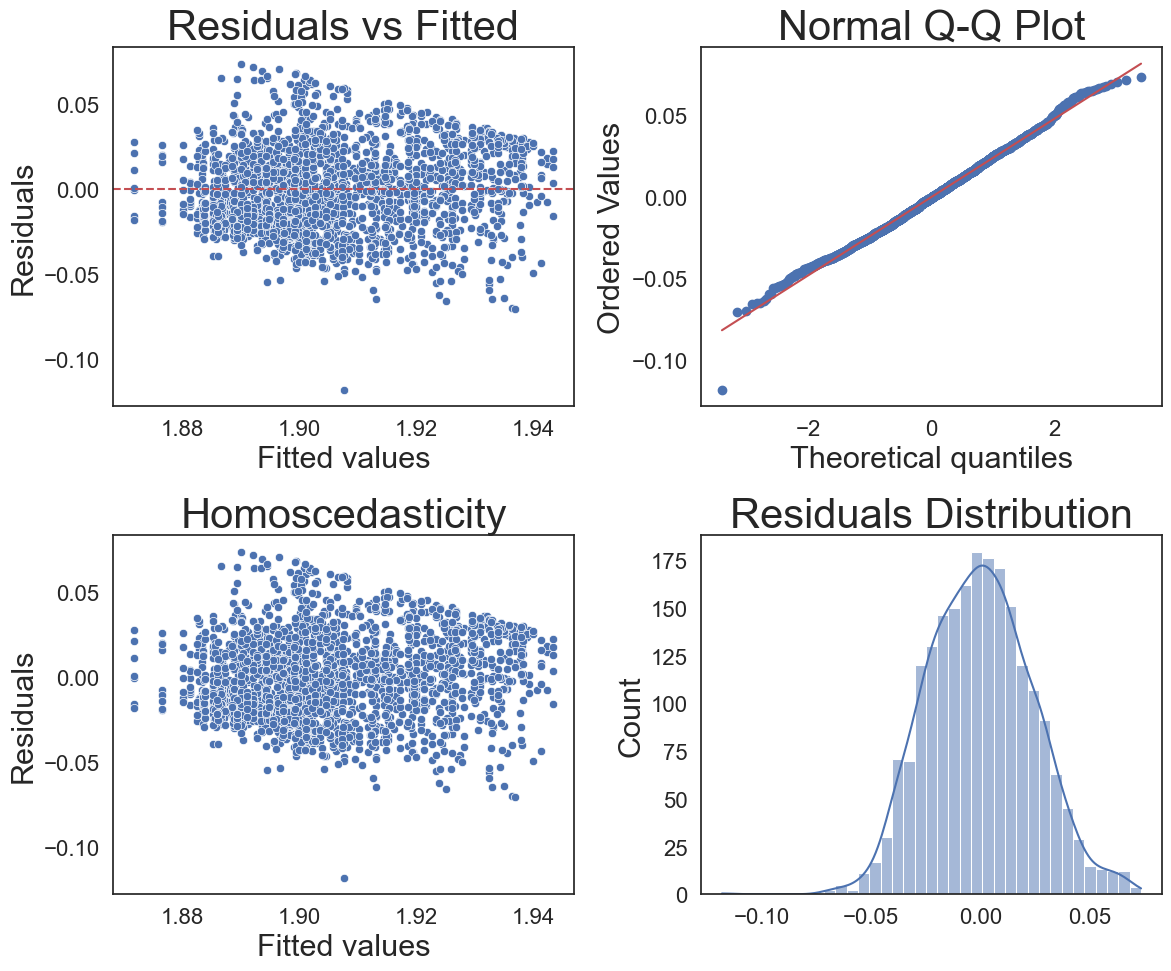

Shapiro-Wilk test p-value: 9.186988609144464e-05
Residuals are not homoscedastic LeveneResult(statistic=9.19499213511336, pvalue=4.825378530675783e-06)
Bartlett’s test p-value: 1.7664931690539524e-99
White test p-value: 0.6429143120836012
Levene’s test p-value for the whole model: 4.825378530675783e-06
Levene’s test p-value for variable age: 0.47029531896692267
Levene’s test p-value for variable sex: 0.3605424628090349
Levene’s test p-value for variable site: 0.24198355222655843
Levene’s test p-value for variable diagnosis_group: 0.640625803721915
Homoscedasticiyy checked
Likelihood Ratio Test Statistic: -17.8634
P-value: 1.0000
they are all the same


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


In [192]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model 
no_age = "reciprocal_rt ~ diagnosis_group * condition + sex + site"
no_covariates = "reciprocal_rt ~ diagnosis_group * condition"

# Fit the model
model1 = smf.mixedlm(no_age, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()
model2 = smf.mixedlm(no_covariates, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()


# Print the summary
model_summary = model1.summary()
model_summary
model_summary = model2.summary()
model_summary

# Check assumptions
asumption_df=check_assumptions(model1, vs_grouped, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df
asumption_df=check_assumptions(model2, vs_grouped, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df

from scipy.stats import chi2
# Log-likelihoods for both models
ll_three_way = model1.llf  # Log-likelihood of 3-way interaction model
ll_two_way = model2.llf  # Log-likelihood of 2-way interaction model
# Likelihood ratio test statistic
lr_stat = 2 * (ll_three_way - ll_two_way)
# Degrees of freedom (number of random effects added in mixed model)
df_diff = 1
# Calculate p-value
p_value = chi2.sf(lr_stat, df_diff)
print(f"Likelihood Ratio Test Statistic: {lr_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("one model is better")
else:
    print("they are all the same")

In [193]:
# Compare different models 

models= {"original": "reciprocal_rt ~ diagnosis_group * condition + age + sex + site", 
                "no_interaction": "reciprocal_rt ~ diagnosis_group + condition + age + sex + site",
                "no_age": "reciprocal_rt ~ diagnosis_group * condition + sex + site",
                "no_covariates": "reciprocal_rt ~ diagnosis_group * condition"}

model_comparison = {}

for model_name, formula in models.items():
    model = smf.mixedlm(formula, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()
    # Extract log likelihood
    model_comparison[model_name] = model.llf

    # Extract BIC
    if model_name=="original":
        print(model.summary())

        doc.add_heading(f"Linear model for reaction time general")
        doc.add_paragraph(f"{models[model_name]}", style='List Bullet')
        model_summary= model.summary()
        model_table=pd.DataFrame(model_summary.tables[1])
        model_table["var"] = model_table.index
        model_table = model_table[["var", "Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]]

        doc = df_to_table(doc, model_table)
model_comparison = pd.DataFrame(model_comparison, index=["log_likelihood"]).T

# Print the best model based on log likelihood
best_model = model_comparison.idxmax()
print(f"Best model: {best_model}")

# Add to the document
doc.add_paragraph(f"Model comparison for reaction time general", style='List Bullet')
model_comparison["type"] = model_comparison.index
model_comparison = model_comparison[["type", "log_likelihood"]]
doc = df_to_table(doc, model_comparison)
doc.add_paragraph(f'Best model= {best_model[0]} : {models[best_model[0]]}', style='List Bullet')

# Print the summary of the best model
model = smf.mixedlm(models[best_model[0]], vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()
model_summary = model.summary()
model_summary

    


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                           Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            reciprocal_rt
No. Observations:            2105               Method:                        REML         
No. Groups:                  105                Scale:                         0.0006       
Min. group size:             4                  Log-Likelihood:                4632.9807    
Max. group size:             25                 Converged:                     Yes          
Mean group size:             20.0                                                           
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.916    0.009 224.411 0.000  1.899  1.933
diagn

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/590789905.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  doc.add_paragraph(f'Best model= {best_model[0]} : {

Best model: log_likelihood    no_covariates
dtype: object


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                           Mixed Linear Model Regression Results
============================================================================================
Model:                       MixedLM            Dependent Variable:            reciprocal_rt
No. Observations:            2105               Method:                        REML         
No. Groups:                  105                Scale:                         0.0006       
Min. group size:             4                  Log-Likelihood:                4649.9391    
Max. group size:             25                 Converged:                     Yes          
Mean group size:             20.0                                                           
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.913    0.005 366.526 0.000  1.903  1.924
diagnosis_group[T.asd]                           -0.003    0.007  -0.410 0.682 -0.015  0.010
diagnosis_group[T.control]                       -0.002    0.006  -0.286 0.775 -0.013  0.010
condition[T.Nine]                                -0.009    0.004  -2.594 0.009 -0.016 -0.002
condition[T.Thirteen]                            -0.014    0.004  -3.695 0.000 -0.022 -0.007
diagnosis_group[T.asd]:condition[T.Nine]          0.005    0.004   1.203 0.229 -0.003  0.014
diagnosis_group[T.control]:condition[T.Nine]      0.004    0.004   0.977 0.328 -0.004  0.011
diagnosis_group[T.asd]:condition[T.Thirteen]      0.008    0.005   1.637 0.102 -0.002  0.017
diagnosis_group[T.control]:condition[T.Thirteen]  0.011    0.004   2.563 0.010  0.003  0.019
Group Var                                         0.000    0.002                            
============================================================================================

"""

In [194]:
models[best_model[0]]

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/2921822112.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  models[best_model[0]]


'reciprocal_rt ~ diagnosis_group * condition'

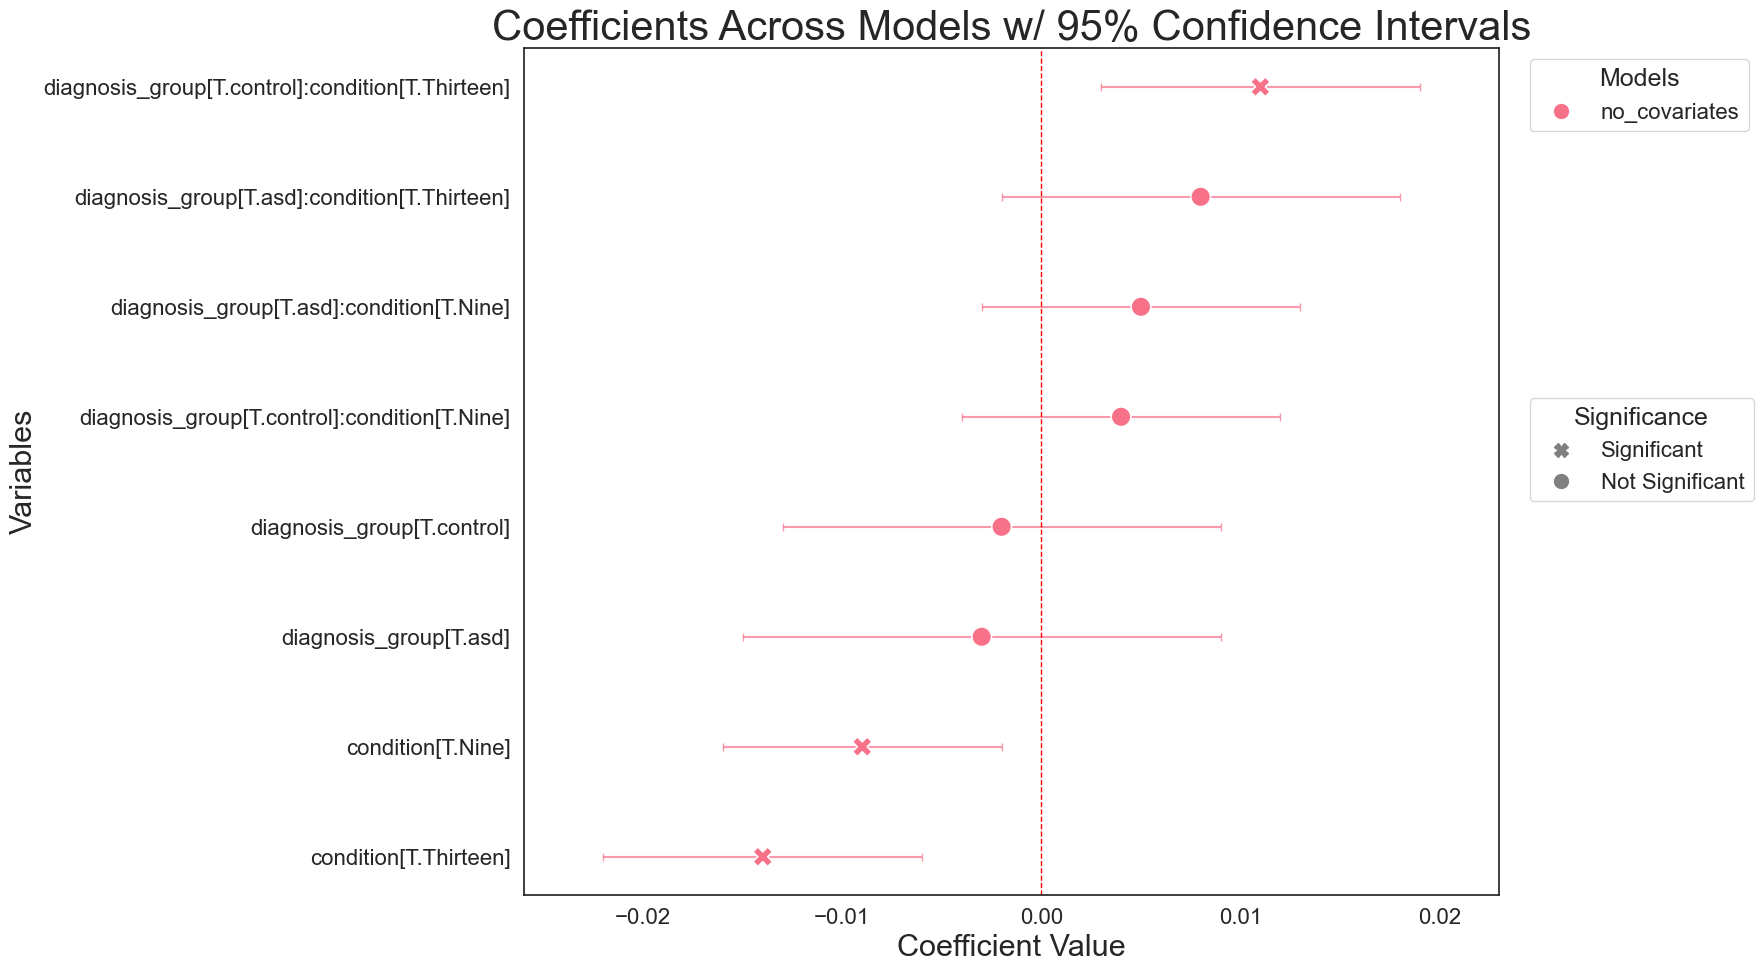

In [195]:
coefplot_gap(all_coefs, multiple_models=True, fig_name="multiple_models")

### Best linear model for detail (+other variables)

In [196]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
model_comparison = {}
models_comp= {"original": "reciprocal_rt ~ diagnosis_group * detail + age + sex + site", 
                "no_interaction": "reciprocal_rt ~ diagnosis_group + detail + age + sex + site",
                "no_age": "reciprocal_rt ~ diagnosis_group * detail + sex + site",
                "no_covariates": "reciprocal_rt ~ diagnosis_group * detail"}
coeff_dfs = []
model_comparisons_list = []
model_coefficients = []

for model_name, model_formula in models_comp.items():

    model1 = smf.mixedlm(model_formula, vs_grouped, groups=vs_grouped["subject"], re_formula="1").fit( reml=False)
    # Compare models
    coeff_dfs = []

    # Print the model
    print(model_name,model1.summary())

    #****** IF YOU WANT TO COMPARE MANY MODELS models = [model, model2, model3, model4, model5]
    models = [model1]

    log_likelihoods = [model.llf for model in models]
    aic = [model.aic for model in models]
    bic = [model.bic for model in models]
    converged = [model.converged for model in models]
    # Create dictionary with model names
    model_names = ["Mix Rand-int"]
    model_table = model_table[["var", "Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]]

    model_comparison = pd.DataFrame({"log_likelihood": log_likelihoods, "aic": aic, "bic": bic, "converged":converged }, index=model_names)
    # Collect homoscedasticity test results
    hom_test_results = []


    for model in models:
        hom_test_df = check_homoscedasticity(model, vs_grouped, show_text=False, co_vars=["age", "outcome", "sex", "site"])
        hom_test_results.append(hom_test_df.iloc[0])  # Assuming results are in a single row

        coeff_df = stage_model(model)
        coeff_dfs.append(coeff_df)


    # Convert list of series to a DataFrame
    hom_test_df_combined = pd.DataFrame(hom_test_results, index=model_comparison.index)

    # Merge with model comparison DataFrame
    model_comparison = pd.concat([model_comparison, hom_test_df_combined], axis=1)
    print(model_comparison)

    # Print model comparison results


   
    # Create df with all coefficients
    all_coefs = pd.concat(coeff_dfs, keys=model_names).reset_index()

    all_coefs["model_name"] = model_name
    all_coefs["model"] = model_name
    # Append all coeffts
    model_coefficients.append(all_coefs)
    model_comparisons_list.append(model_comparison)
# Create a df with all model comparisons
model_comparisons_df = pd.concat(model_comparisons_list, keys=models_comp.keys()).reset_index()
model_coefficients_df = pd.concat(model_coefficients)


#coefplot_gap(model_coefficients_df, multiple_models=True, fig_name="all_models")


# Drop unwanted columns
model_coefficients_df.drop(columns=["level_1","model_name"], inplace=True)
model_coefficients_df.rename(columns={"level_0": "model"}, inplace=True)
model_comparisons_df.drop(columns=["level_1"], inplace=True)
model_comparisons_df.rename(columns={"level_0": "model"}, inplace=True)


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


original                          Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          reciprocal_rt
No. Observations:           2105             Method:                      ML           
No. Groups:                 105              Scale:                       0.0006       
Min. group size:            4                Log-Likelihood:              4715.7421    
Max. group size:            25               Converged:                   Yes          
Mean group size:            20.0                                                       
---------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                    1.913    0.008 228.298 0.000  1.896  1.929
diagnosis_group[T.asd]                      -0.0

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Homoscedasticiyy checked
              log_likelihood          aic          bic  converged  \
Mix Rand-int     4715.742057 -9409.484115 -9347.311336       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.008721    0.000142   1.210908e-84  6.770207e-09   

              multicollinearity      age      sex     site  
Mix Rand-int             7.9921  0.56649  0.21801  0.23683  


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Residuals are not homoscedastic LeveneResult(statistic=3.886939008133664, pvalue=0.008758875224992052)
Homoscedasticiyy checked
              log_likelihood          aic          bic  converged  \
Mix Rand-int     4715.735531 -9411.471063 -9354.950355       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.008759    0.002836   1.235311e-84  6.723994e-09   

              multicollinearity      age      sex     site  
Mix Rand-int           7.991914  0.56651  0.21793  0.23743  


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


no_covariates                          Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          reciprocal_rt
No. Observations:           2105             Method:                      ML           
No. Groups:                 105              Scale:                       0.0006       
Min. group size:            4                Log-Likelihood:              4715.2453    
Max. group size:            25               Converged:                   Yes          
Mean group size:            20.0                                                       
---------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                    1.910    0.005 374.903 0.000  1.900  1.920
diagnosis_group[T.asd]                     

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


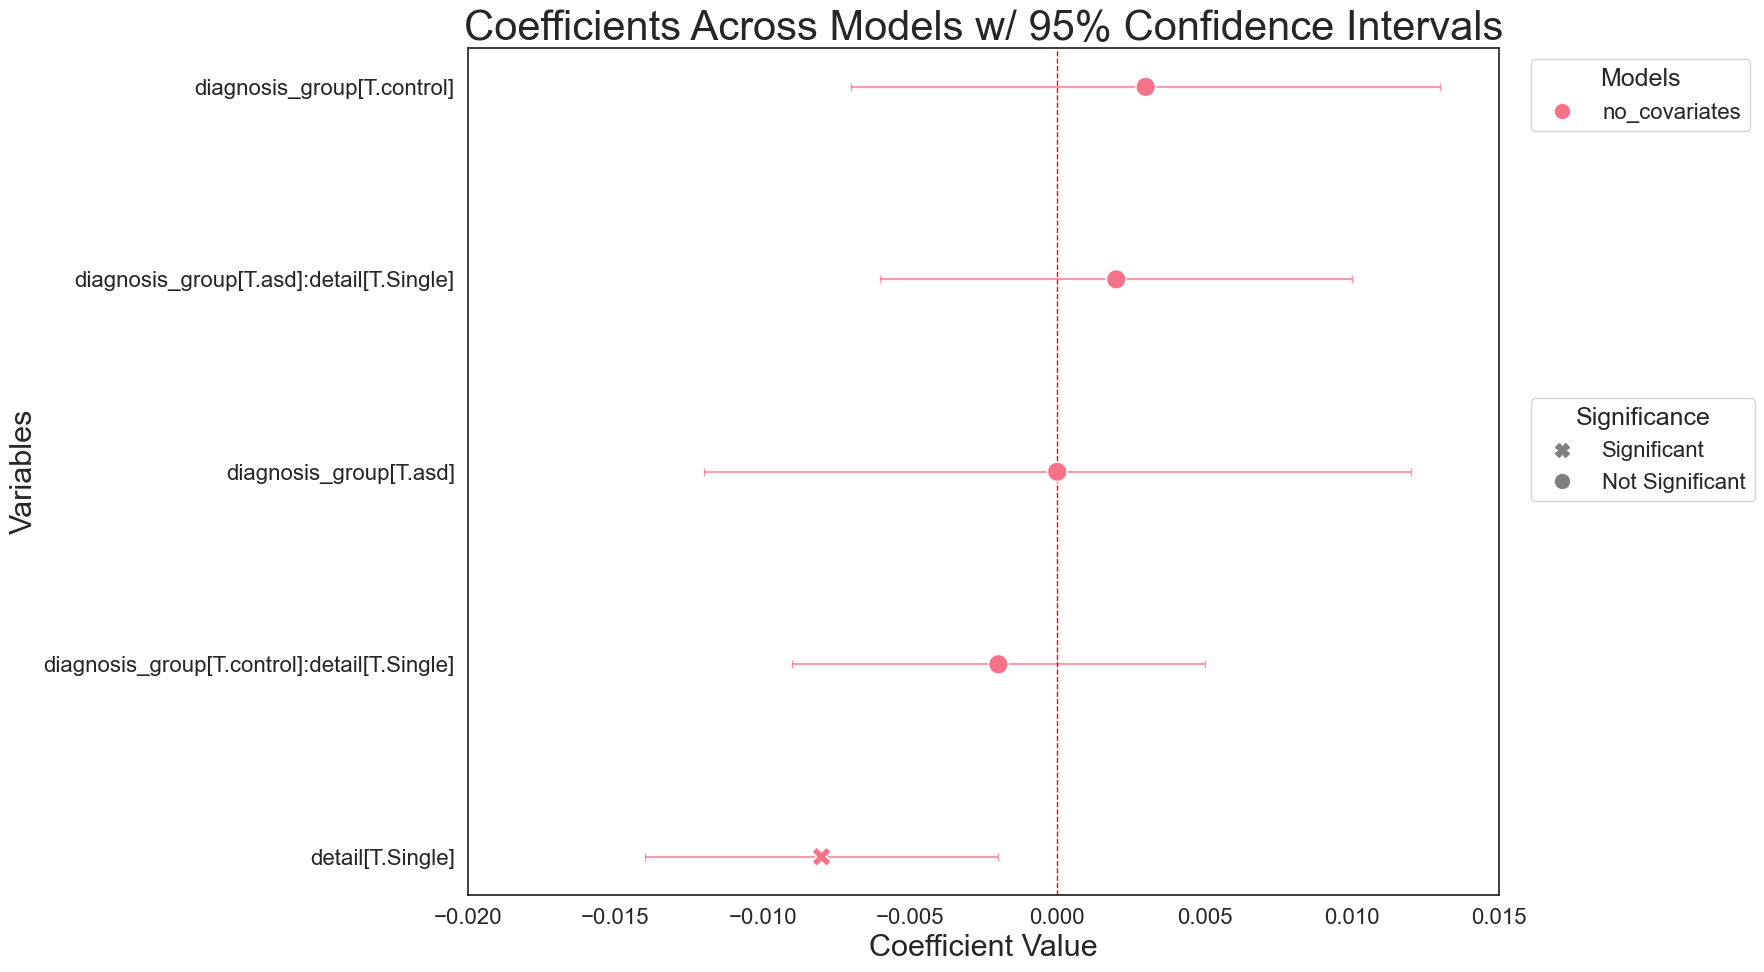

In [197]:
coefplot_gap(all_coefs, multiple_models=True, fig_name="multiple_models")

In [198]:
model_comparisons_df

,model,log_likelihood,aic,bic,converged,levene_test_all,white_test,bartlett_test,shapiro_test,multicollinearity,age,sex,site
0,original,4715.742057,-9409.484115,-9347.311336,True,0.008721,0.000142,1.210908e-84,6.770207e-09,7.992100,0.56649,0.21801,0.23683
1,no_interaction,4714.624895,-9411.249790,-9360.381153,True,0.005723,0.000569,1.628046e-85,5.232271e-09,2.423373,0.59484,0.24041,0.22092
2,no_age,4715.735531,-9411.471063,-9354.950355,True,0.008759,0.002836,1.235311e-84,6.723994e-09,7.991914,0.56651,0.21793,0.23743
3,no_covariates,4715.245329,-9414.490658,-9369.274092,True,0.010073,0.000132,1.291846e-84,7.473223e-09,7.991516,0.56667,0.22312,0.24311


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/2390626922.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)


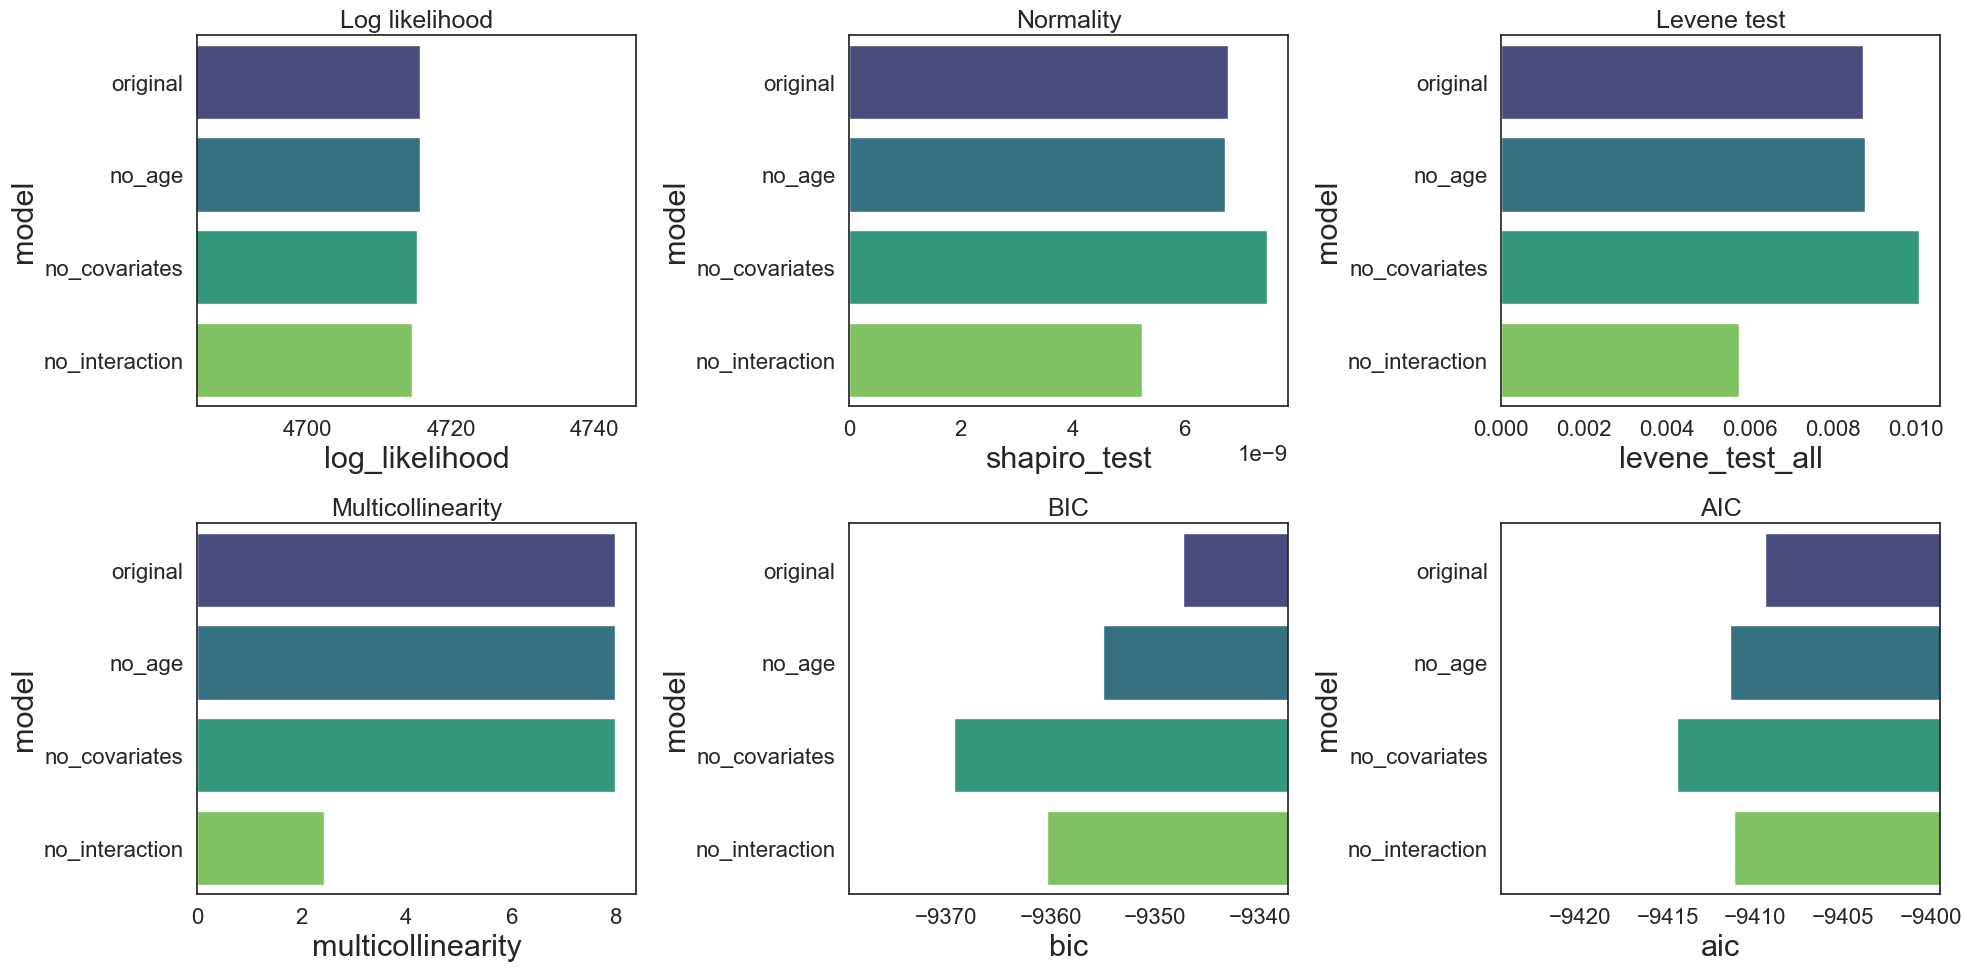

In [199]:
# Plot the different models and sort them by log likelihood

# Megerge all stages

model_comparisons_df["stage"]= "Standard"
model_comparisons_df_stages = model_comparisons_df.copy()

model_comparisons_df_stages = model_comparisons_df_stages.sort_values(by="log_likelihood", ascending=False)

# Plot the different models and sort them by log likelihood

model_comparisons_df = model_comparisons_df.sort_values(by="log_likelihood", ascending=False)

# Plot
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Plot log likelihood
sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)

# Calculate min and max of log_likelihood
log_likelihood_min = model_comparisons_df["log_likelihood"].min() - 30
log_likelihood_max = model_comparisons_df["log_likelihood"].max() + 30

# Set x-axis limits for ax[0, 0]
ax[0, 0].set_xlim(log_likelihood_min, log_likelihood_max)

# Plot Shapiro test
sns.barplot(x="shapiro_test", y="model", data=model_comparisons_df, ax=ax[0, 1], palette="viridis")

# Plot White test
sns.barplot(x="levene_test_all", y="model", data=model_comparisons_df, ax=ax[0, 2], palette="viridis")

# Plot Multicollinearity
sns.barplot(x="multicollinearity", y="model", data=model_comparisons_df, ax=ax[1, 0], palette="viridis")

# Plot BIC
sns.barplot(x="bic", y="model", data=model_comparisons_df, ax=ax[1, 1], palette="viridis")

# Calculate min and max of BIC
bic_min = model_comparisons_df["bic"].min() - 10
bic_max = model_comparisons_df["bic"].max() + 10

# Set x-axis limits for ax[1, 1]
ax[1, 1].set_xlim(bic_min, bic_max)


# Plot AIC
sns.barplot(x="aic", y="model", data=model_comparisons_df, ax=ax[1, 2], palette="viridis")

# Calculate min and max of AIC
aic_min = model_comparisons_df["aic"].min() - 10
aic_max = model_comparisons_df["aic"].max() + 10

# Set x-axis limits for ax[1, 2]
ax[1, 2].set_xlim(aic_min, aic_max)

# Add titles
ax[0, 0].set_title("Log likelihood", fontsize=18)
ax[0, 1].set_title("Normality", fontsize=18)
ax[0, 2].set_title("Levene test", fontsize=18)
ax[1, 0].set_title("Multicollinearity", fontsize=18)
ax[1, 1].set_title("BIC", fontsize=18)
ax[1, 2].set_title("AIC", fontsize=18)

# Change x-axis limits for the log likelihood plot
# ax[0, 0].set_xlim(1330, 1405)

plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


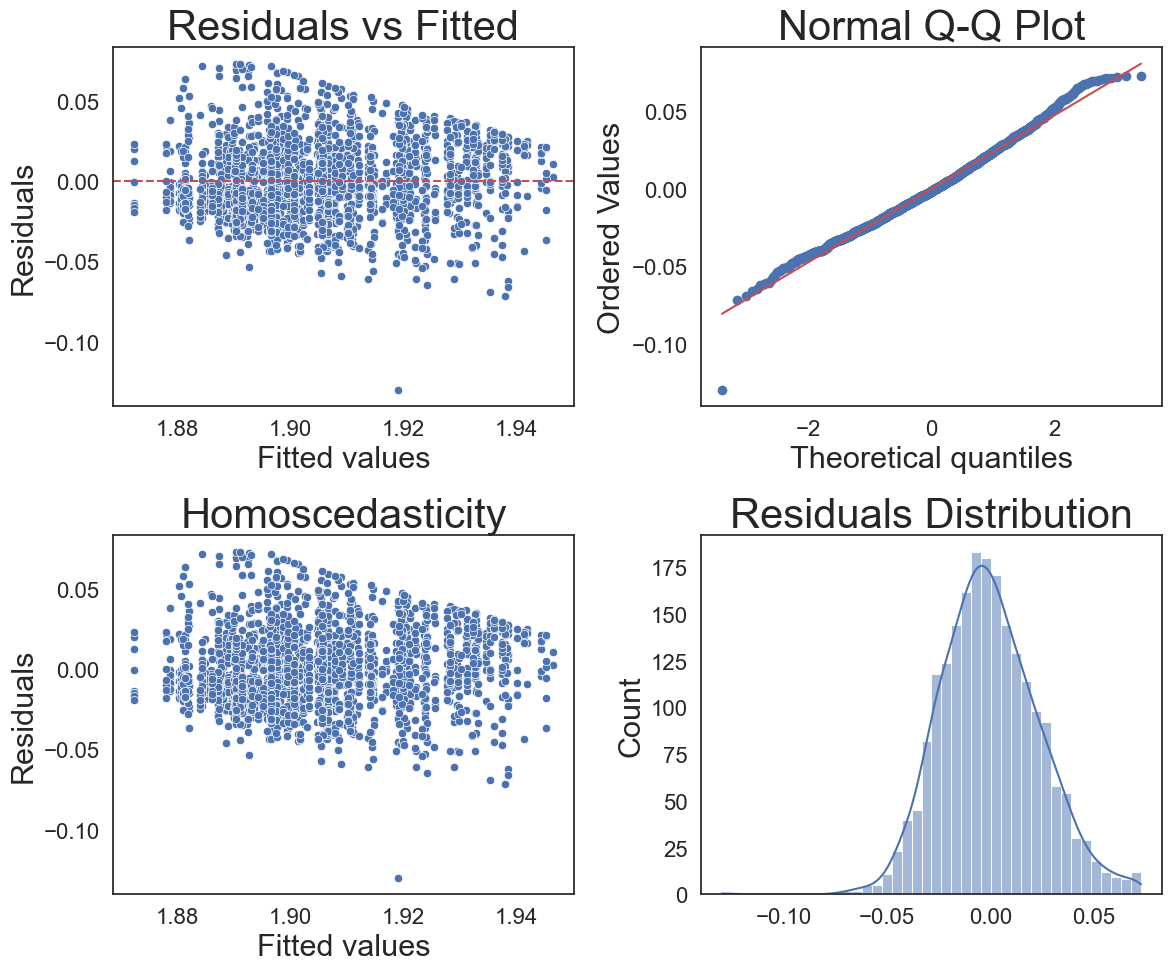

Shapiro-Wilk test p-value: 5.503282718422042e-09
Residuals are not homoscedastic LeveneResult(statistic=4.1307897656571395, pvalue=0.006249584678708097)
Bartlett’s test p-value: 5.618008115876258e-83
White test p-value: 0.0005912693070871887
Levene’s test p-value for the whole model: 0.006249584678708097
Levene’s test p-value for variable age: 0.5952647466888128
Levene’s test p-value for variable sex: 0.23754731815103522
Levene’s test p-value for variable site: 0.2232931818855913
Levene’s test p-value for variable diagnosis_group: 0.4710626999112074
Homoscedasticiyy checked


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


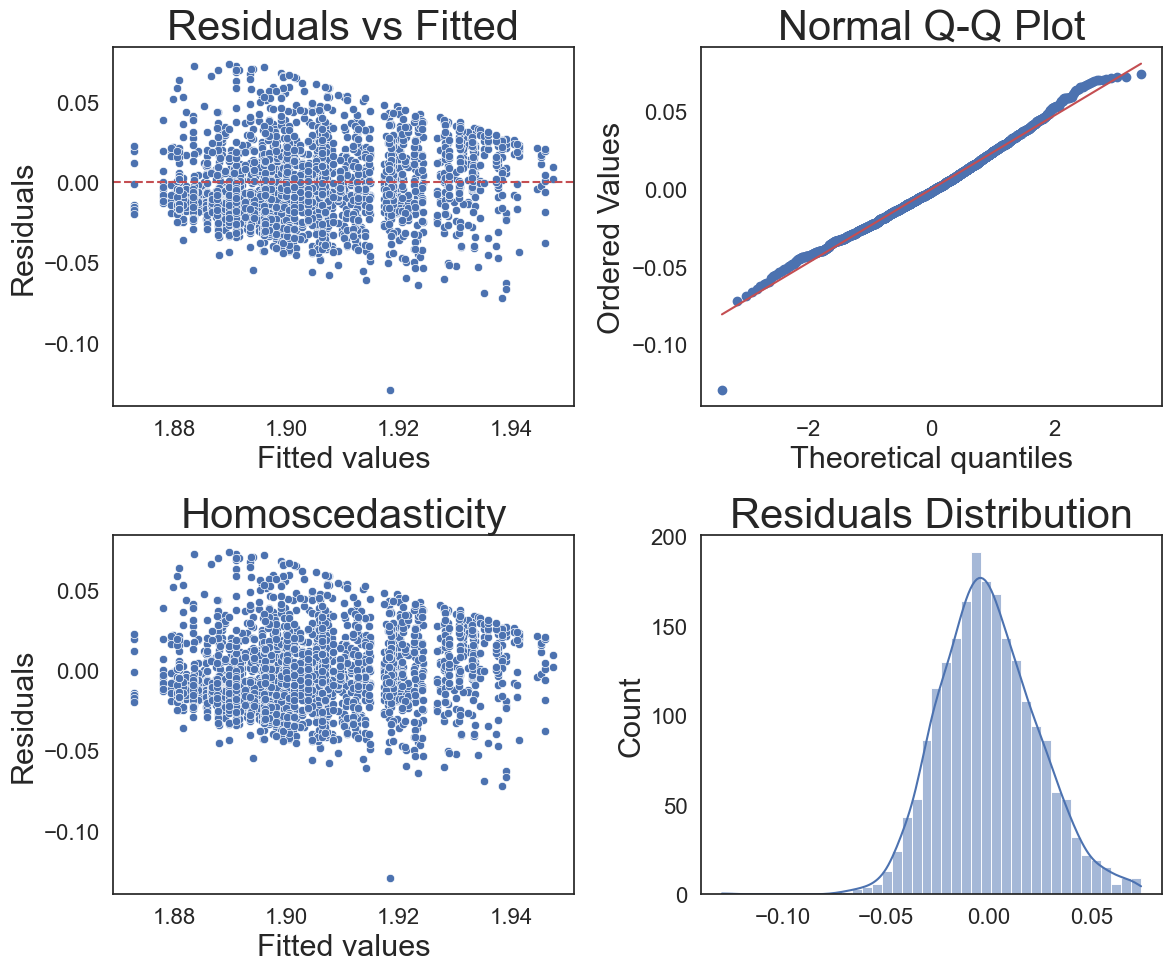

Shapiro-Wilk test p-value: 7.646135280481303e-09
Residuals are not homoscedastic LeveneResult(statistic=3.782288913454542, pvalue=0.010120127953013532)
Bartlett’s test p-value: 2.107621442169554e-83
White test p-value: 0.00013390011724293905
Levene’s test p-value for the whole model: 0.010120127953013532
Levene’s test p-value for variable age: 0.5667934912840904
Levene’s test p-value for variable sex: 0.22118895531546717
Levene’s test p-value for variable site: 0.2441963690027437
Levene’s test p-value for variable diagnosis_group: 0.37719620699793477
Homoscedasticiyy checked
Likelihood Ratio Test Statistic: -16.3620
P-value: 1.0000
they are all the same


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


In [200]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model 
no_interaction = "reciprocal_rt ~ diagnosis_group + detail + age + sex + site"
no_covariates = "reciprocal_rt ~ diagnosis_group * detail"

# Fit the model
model1 = smf.mixedlm(no_interaction, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()
model2 = smf.mixedlm(no_covariates, vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()


# Print the summary
model_summary = model1.summary()
model_summary
model_summary = model2.summary()
model_summary

# Check assumptions
asumption_df=check_assumptions(model1, vs_grouped, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df
asumption_df=check_assumptions(model2, vs_grouped, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df

from scipy.stats import chi2
# Log-likelihoods for both models
ll_three_way = model1.llf  # Log-likelihood of 3-way interaction model
ll_two_way = model2.llf  # Log-likelihood of 2-way interaction model
# Likelihood ratio test statistic
lr_stat = 2 * (ll_three_way - ll_two_way)
# Degrees of freedom (number of random effects added in mixed model)
df_diff = 1
# Calculate p-value
p_value = chi2.sf(lr_stat, df_diff)
print(f"Likelihood Ratio Test Statistic: {lr_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("one model is better")
else:
    print("they are all the same")

In [201]:
model_comparison = {}
models= {"original": "reciprocal_rt ~ diagnosis_group * detail + age + sex + site", 
                "no_interaction": "reciprocal_rt ~ diagnosis_group + detail + age + sex + site",
                "no_age": "reciprocal_rt ~ diagnosis_group * detail + sex + site",
                "no_covariates": "reciprocal_rt ~ diagnosis_group * detail"}
coeff_dfs = []

for model_name, formula in models.items():
    model = smf.mixedlm(formula, vs_grouped, groups=vs_grouped["subject"],re_formula="1").fit()
    # Extract log likelihood
    model_comparison[model_name] = model.llf

    # Add to coeff dfs
    coef_df = pd.DataFrame(model.summary().tables[1]).reset_index()
    coef_df = coef_df.loc[coef_df["index"] != "Group Var"]
    coef_df['model'] = model_name
   
    coeff_dfs.append(coef_df)


    # Extract BIC
    if model_name=="original":
        print(model.summary())

        doc.add_heading(f"Linear model for reaction time general")
        doc.add_paragraph(f"{models[model_name]}", style='List Bullet')
        model_summary= model.summary()
        model_table=pd.DataFrame(model_summary.tables[1])
        model_table["var"] = model_table.index
        model_table = model_table[["var", "Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]]

        doc = df_to_table(doc, model_table)
model_comparison = pd.DataFrame(model_comparison, index=["log_likelihood"]).T

# Create df with all coefficients
all_coefs = pd.concat(coeff_dfs, keys=models.keys()).reset_index()


# Print the best model based on log likelihood
best_model = model_comparison.idxmax()
print(f"Best model: {best_model}")

# Add to the document
doc.add_paragraph(f"Model comparison for reaction time general", style='List Bullet')
model_comparison["type"] = model_comparison.index
model_comparison = model_comparison[["type", "log_likelihood"]]
doc = df_to_table(doc, model_comparison)
doc.add_paragraph(f'Best model= {best_model[0]} : {models[best_model[0]]}', style='List Bullet')

# Print the summary of the best model
model = smf.mixedlm(models[best_model[0]], vs_grouped, groups=vs_grouped["subject"],re_formula="~1").fit()
model_summary = model.summary()
model_summary

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                         Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          reciprocal_rt
No. Observations:           2105             Method:                      REML         
No. Groups:                 105              Scale:                       0.0006       
Min. group size:            4                Log-Likelihood:              4668.2849    
Max. group size:            25               Converged:                   Yes          
Mean group size:            20.0                                                       
---------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                    1.913    0.009 221.526 0.000  1.896  1.930
diagnosis_group[T.asd]                      -0.001    0.0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_37747/2560125870.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  doc.add_paragraph(f'Best model= {best_model[0]} : 

Best model: log_likelihood    no_covariates
dtype: object


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Mixed Linear Model Regression Results
=======================================================================================
Model:                      MixedLM          Dependent Variable:          reciprocal_rt
No. Observations:           2105             Method:                      REML         
No. Groups:                 105              Scale:                       0.0006       
Min. group size:            4                Log-Likelihood:              4685.1832    
Max. group size:            25               Converged:                   Yes          
Mean group size:            20.0                                                       
---------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                    1.910    0.005 369.630 0.000  1.900  1.920
diagnosis_group[T.asd]                       0.000    0.006   0.014 0.989 -0.012  0.013
diagnosis_group[T.control]                   0.003    0.006   0.617 0.538 -0.008  0.015
detail[T.Single]                            -0.008    0.003  -2.686 0.007 -0.014 -0.002
diagnosis_group[T.asd]:detail[T.Single]      0.002    0.004   0.448 0.654 -0.006  0.009
diagnosis_group[T.control]:detail[T.Single] -0.002    0.003  -0.648 0.517 -0.009  0.004
Group Var                                    0.000    0.002                            
=======================================================================================

"""

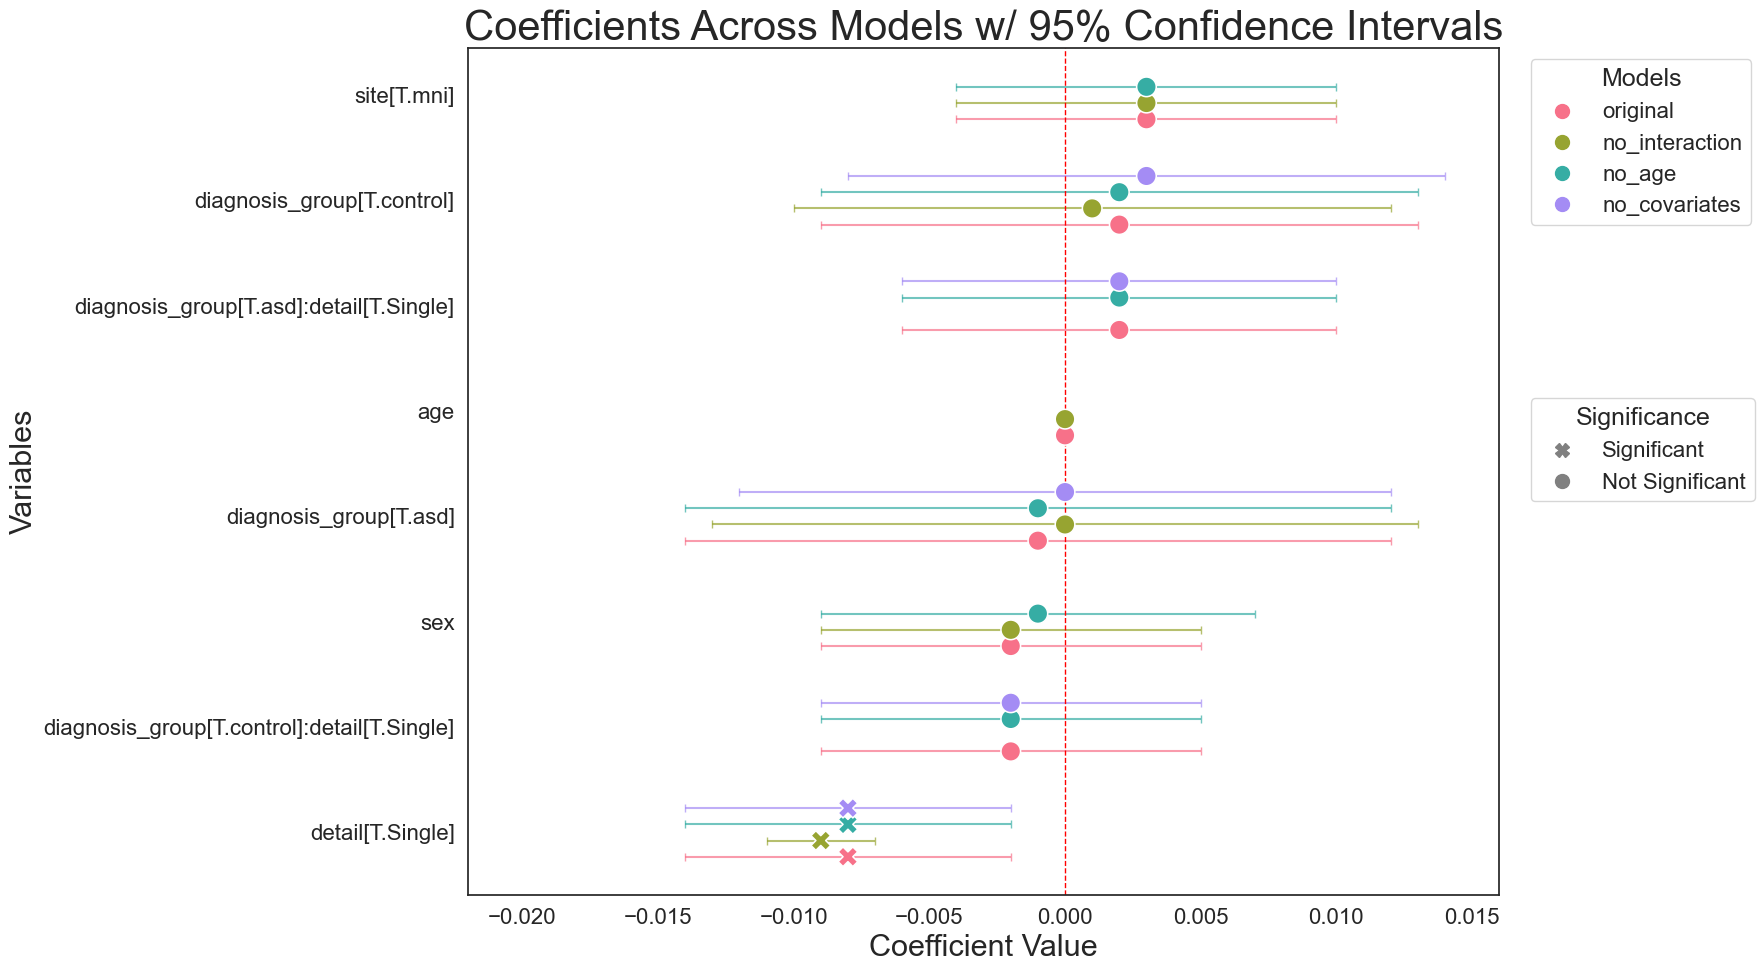

In [202]:
coefplot_gap(all_coefs, multiple_models=True, fig_name="multiple_models")

## Compare different models including trial number and overall rt 

In [142]:
rt_sub.columns

Index(['index', 'subject', 'Trial_Index_', 'condition', 'detail', 'rt',
       'VS_VALID', 'vs_location_list', 'age', 'group', 'site', 'sex', 'asd',
       'adhd', 'record_id', 'age_group', 'diagnosis_group', 'reciprocal_rt',
       'cond_det', 'total_trials', 'overall_rt'],
      dtype='object')

In [143]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
model_comparison = {}
rt_sub_all = rt_sub.merge(vs_grouped, on='subject', how='inner', suffixes=('', '_dup'))
rt_sub_all = rt_sub_all.loc[:, ~rt_sub_all.columns.str.endswith('_dup')]
rt_sub_all["Trial_Index_"] = rt_sub_all["Trial_Index_"].astype(float)

models= {"original": "reciprocal_rt ~ diagnosis_group * condition + age + sex + site + total_trials + Trial_Index_", 
                "trial_index_interaction": "reciprocal_rt ~ diagnosis_group * condition + diagnosis_group * Trial_Index_ + age + sex + site ",
                "no_interaction": "reciprocal_rt ~ diagnosis_group + condition + age + sex + site + total_trials", 
                "no_age": "reciprocal_rt ~ diagnosis_group * condition + sex + site + total_trials + Trial_Index_",
                "no_covariates": "reciprocal_rt ~ diagnosis_group * condition"}
coeff_dfs = []
model_comparisons_list = []
model_coefficients = []

for model_name, model_formula in models.items():

    model1 = smf.mixedlm(model_formula, rt_sub, groups=rt_sub["subject"], re_formula="1").fit( reml=False)
    # Compare models
    coeff_dfs = []

    # Print the model
    print(model_name,model1.summary())

    #****** IF YOU WANT TO COMPARE MANY MODELS models = [model, model2, model3, model4, model5]
    models = [model1]

    log_likelihoods = [model.llf for model in models]
    aic = [model.aic for model in models]
    bic = [model.bic for model in models]
    converged = [model.converged for model in models]
    # Create dictionary with model names
    model_names = ["Mix Rand-int"]

    model_comparison = pd.DataFrame({"log_likelihood": log_likelihoods, "aic": aic, "bic": bic, "converged":converged }, index=model_names)
    # Collect homoscedasticity test results
    hom_test_results = []


    for model in models:
        hom_test_df = check_homoscedasticity(model, rt_sub, show_text=False, co_vars=["age", "outcome", "sex", "site"])
        hom_test_results.append(hom_test_df.iloc[0])  # Assuming results are in a single row

        coeff_df = stage_model(model)
        coeff_dfs.append(coeff_df)


    # Convert list of series to a DataFrame
    hom_test_df_combined = pd.DataFrame(hom_test_results, index=model_comparison.index)

    # Merge with model comparison DataFrame
    model_comparison = pd.concat([model_comparison, hom_test_df_combined], axis=1)
    print(model_comparison)

    # Print model comparison results


   
    # Create df with all coefficients
    all_coefs = pd.concat(coeff_dfs, keys=model_names).reset_index()

    all_coefs["model_name"] = model_name
    all_coefs["model"] = model_name
    # Append all coeffts
    model_coefficients.append(all_coefs)
    model_comparisons_list.append(model_comparison)
# Create a df with all model comparisons
model_comparisons_df = pd.concat(model_comparisons_list, keys=models_comp.keys()).reset_index()
model_coefficients_df = pd.concat(model_coefficients)


#coefplot_gap(model_coefficients_df, multiple_models=True, fig_name="all_models")


# Drop unwanted columns
model_coefficients_df.drop(columns=["level_1","model_name"], inplace=True)
model_coefficients_df.rename(columns={"level_0": "model"}, inplace=True)
model_comparisons_df.drop(columns=["level_1"], inplace=True)
model_comparisons_df.rename(columns={"level_0": "model"}, inplace=True)


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


original                            Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            reciprocal_rt
No. Observations:            2105               Method:                        ML           
No. Groups:                  105                Scale:                         0.0005       
Min. group size:             4                  Log-Likelihood:                4898.4932    
Max. group size:             25                 Converged:                     Yes          
Mean group size:             20.0                                                           
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.986    0.010 201.119 0.000  1.966  2.

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_94264/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Residuals are not homoscedastic LeveneResult(statistic=9.835901170522108, pvalue=1.9280474850243376e-06)
Homoscedasticiyy checked
              log_likelihood          aic          bic  converged  \
Mix Rand-int     4898.493249 -9692.986497 -9399.078819       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.000002    0.005543   2.724360e-18  1.837188e-12   

              multicollinearity     age      sex     site  
Mix Rand-int          15.533742  0.5089  0.21686  0.77492  


LinAlgError: Singular matrix

In [ ]:
model_comparisons_df

In [ ]:
# Plot the different models and sort them by log likelihood

# Megerge all stages

model_comparisons_df["stage"]= "Standard"
model_comparisons_df_stages = model_comparisons_df.copy()

model_comparisons_df_stages = model_comparisons_df_stages.sort_values(by="log_likelihood", ascending=False)

# Plot the different models and sort them by log likelihood

model_comparisons_df = model_comparisons_df.sort_values(by="log_likelihood", ascending=False)

# Plot
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Plot log likelihood
sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)

# Calculate min and max of log_likelihood
log_likelihood_min = model_comparisons_df["log_likelihood"].min() - 30
log_likelihood_max = model_comparisons_df["log_likelihood"].max() + 30

# Set x-axis limits for ax[0, 0]
ax[0, 0].set_xlim(log_likelihood_min, log_likelihood_max)

# Plot Shapiro test
sns.barplot(x="shapiro_test", y="model", data=model_comparisons_df, ax=ax[0, 1], palette="viridis")

# Plot White test
sns.barplot(x="levene_test_all", y="model", data=model_comparisons_df, ax=ax[0, 2], palette="viridis")

# Plot Multicollinearity
sns.barplot(x="multicollinearity", y="model", data=model_comparisons_df, ax=ax[1, 0], palette="viridis")

# Plot BIC
sns.barplot(x="bic", y="model", data=model_comparisons_df, ax=ax[1, 1], palette="viridis")

# Calculate min and max of BIC
bic_min = model_comparisons_df["bic"].min() - 10
bic_max = model_comparisons_df["bic"].max() + 10

# Set x-axis limits for ax[1, 1]
ax[1, 1].set_xlim(bic_min, bic_max)


# Plot AIC
sns.barplot(x="aic", y="model", data=model_comparisons_df, ax=ax[1, 2], palette="viridis")

# Calculate min and max of AIC
aic_min = model_comparisons_df["aic"].min() - 10
aic_max = model_comparisons_df["aic"].max() + 10

# Set x-axis limits for ax[1, 2]
ax[1, 2].set_xlim(aic_min, aic_max)

# Add titles
ax[0, 0].set_title("Log likelihood", fontsize=18)
ax[0, 1].set_title("Normality", fontsize=18)
ax[0, 2].set_title("Levene test", fontsize=18)
ax[1, 0].set_title("Multicollinearity", fontsize=18)
ax[1, 1].set_title("BIC", fontsize=18)
ax[1, 2].set_title("AIC", fontsize=18)

# Change x-axis limits for the log likelihood plot
# ax[0, 0].set_xlim(1330, 1405)

plt.tight_layout()
plt.show()

In [ ]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model 
original = "reciprocal_rt ~ diagnosis_group * condition + sex+ age + site + total_trials + Trial_Index_"
no_covariates =  "reciprocal_rt ~ diagnosis_group * condition"

# Fit the model
model1 = smf.mixedlm(original, rt_sub, groups=rt_sub["subject"],re_formula="~1").fit()
model2 = smf.mixedlm(no_covariates, rt_sub, groups=rt_sub["subject"],re_formula="~1").fit()


# Print the summary
model_summary = model1.summary()
model_summary
model_summary = model2.summary()
model_summary

# Check assumptions
asumption_df=check_assumptions(model1, rt_sub, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df
asumption_df=check_assumptions(model2, rt_sub, show_plots=True, show_text=True, covariates=["age","sex","site", "diagnosis_group"])
asumption_df

from scipy.stats import chi2
# Log-likelihoods for both models
ll_three_way = model1.llf  # Log-likelihood of 3-way interaction model
ll_two_way = model2.llf  # Log-likelihood of 2-way interaction model
# Likelihood ratio test statistic
lr_stat = 2 * (ll_three_way - ll_two_way)
# Degrees of freedom (number of random effects added in mixed model)
df_diff = 1
# Calculate p-value
p_value = chi2.sf(lr_stat, df_diff)
print(f"Likelihood Ratio Test Statistic: {lr_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("one model is better")
else:
    print("they are all the same")


## Do linear modelas with weight (failure for homoscedasticity)

In [ ]:
asumption_df

In [ ]:
# 9 supposed to make it slower, b ut it makes it faster 
# tirla total: total trials = accuracy more of it = faster reaction time 
# trial index to check why at 0 but significant 

In [ ]:
model_comparison = {}
rt_sub_all = rt_sub.merge(vs_grouped, on='subject', how='inner', suffixes=('', '_dup'))
rt_sub_all = rt_sub_all.loc[:, ~rt_sub_all.columns.str.endswith('_dup')]
rt_sub_all["Trial_Index_"] = rt_sub_all["Trial_Index_"].astype(float)

models= {"original": "reciprocal_rt ~ asd * condition + age + sex + site + total_trials + Trial_Index_", 
                "trial_index_interaction": "reciprocal_rt ~ asd * condition + asd * Trial_Index_ + age + sex + site ",
                "no_interaction": "reciprocal_rt ~ asd + condition + age + sex + site + total_trials", 
                "no_age": "reciprocal_rt ~ asd * condition + sex + site + total_trials + Trial_Index_",
                "no_covariates": "reciprocal_rt ~ asd * condition"
            }
coeff_dfs = []

for model_name, formula in models.items():
    model = smf.mixedlm(formula, rt_sub, groups=rt_sub["subject"],re_formula="~1").fit()
    # Extract log likelihood
    model_comparison[model_name] = model.llf

    # Add to coeff dfs
    coef_df = pd.DataFrame(model.summary().tables[1]).reset_index()
    coef_df = coef_df.loc[coef_df["index"] != "Group Var"]
    coef_df['model'] = model_name
   
    coeff_dfs.append(coef_df)


    # Extract BIC
    if model_name=="original":
        print(model.summary())

        doc.add_heading(f"Linear model for reaction time general")
        doc.add_paragraph(f"{models[model_name]}", style='List Bullet')
        model_summary= model.summary()
        model_table=pd.DataFrame(model_summary.tables[1])
        model_table["var"] = model_table.index
        model_table = model_table[["var", "Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]]

doc = df_to_table(doc, model_table)
model_comparison = pd.DataFrame(model_comparison, index=["log_likelihood"]).T

# Create df with all coefficients
all_coefs = pd.concat(coeff_dfs, keys=models.keys()).reset_index()


# Print the best model based on log likelihood
best_model = model_comparison.idxmax()
print(f"Best model: {best_model}")

# Add to the document
doc.add_paragraph(f"Model comparison for reaction time general", style='List Bullet')
model_comparison["type"] = model_comparison.index
model_comparison = model_comparison[["type", "log_likelihood"]]
doc = df_to_table(doc, model_comparison)
doc.add_paragraph(f'Best model= {best_model[0]} : {models[best_model[0]]}', style='List Bullet')

# Print the summary of the best model
model = smf.mixedlm(models[best_model[0]], rt_sub, groups=rt_sub["subject"],re_formula="~1").fit()
model_summary = model.summary()
model_summary


## IQ Scores

In [212]:
vs_grouped

,subject,cond_det,condition,detail,vs_location_list,reciprocal_rt,rt,diagnosis_group,sex,age,n_trials,site,age_group
0,0042P,Five_Conjunction,Five,Conjunction,"(10, 15, 0, 13, 14)",1.881322,284.0,asd,1,30.973942,23,mni,adult
1,0042P,Five_Conjunction,Five,Conjunction,"(11, 5, 8, 6, 0)",1.892324,345.0,asd,1,30.973942,23,mni,adult
2,0042P,Five_Conjunction,Five,Conjunction,"(2, 0, 13, 7, 8)",1.906239,455.0,asd,1,30.973942,23,mni,adult
3,0042P,Five_Conjunction,Five,Conjunction,"(5, 9, 4, 15, 6)",1.900249,402.0,asd,1,30.973942,23,mni,adult
4,0042P,Five_Conjunction,Five,Conjunction,"(8, 9, 10, 15, 1)",1.919613,619.0,asd,1,30.973942,23,mni,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,1147S2,Thirteen_Conjunction,Thirteen,Conjunction,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",1.904327,437.0,control,1,22.782238,24,hsj,adult
2101,1147S2,Thirteen_Conjunction,Thirteen,Conjunction,"(7, 16, 15, 1, 2, 13, 11, 5, 6, 4, 12, 10, 3)",1.896720,375.0,control,1,22.782238,24,hsj,adult
2102,1147S2,Thirteen_Single,Thirteen,Single,"(10, 4, 9, 7, 13, 2, 5, 3, 16, 11, 6, 8, 1)",1.886408,310.0,control,1,22.782238,24,hsj,adult
2103,1147S2,Thirteen_Single,Thirteen,Single,"(3, 13, 2, 4, 10, 11, 1, 5, 14, 6, 12, 8, 16)",1.922733,670.0,control,1,22.782238,24,hsj,adult


In [213]:
scores_df = pd.read_csv("/Users/audrey-annebeaudry/Desktop/Final_folder_VS/Q1KDatabase-ECNSRSASEBASCQscores_DATA_2025-08-10_1157.csv")

In [214]:
scores_df["eeg_participant_code"] = scores_df["eeg_participant_code"].str.replace(r"^\D+", "", regex=True).str.replace("_", "")

In [215]:
scores_df.columns.unique()

Index(['record_id', 'redcap_event_name', 'redcap_repeat_instrument',
       'redcap_repeat_instance', 'eeg_participant_code',
       'srsps2rs_tscore_cog_v2', 'srsps2rs_tscore_com_v2',
       'srsps2rs_tscore_rrb_v2', 'srs2sch_tscore_cog_v2',
       'srs2sch_tscore_com_v2', 'srs2sch_tscore_rrb_v2',
       'srs2adself_tscore_cog_v2', 'srs2adself_tscore_com_v2',
       'srs2adself_tscore_rrb_v2', 'i_anxious_depressed_18_59_ts_2',
       'v_attention_problems_18_59_ts_2', 'score_ts_2',
       'ix_internalizing_problemsd_ts_2', 'other_problems_18_59_t_sco_ts_2',
       'cbcl_6_18_anx_depr_tscore_v2', 'vi_attention_problems_6_18',
       'viii_aggressive_behavior_6', 'ix_internalizing_problemsss',
       'externalizing_tscore', 'ii_anxious_depressed_1_5_t_2',
       'vi_attention_problems_1_5', 'vii_aggressive_probleems_1',
       'ix_externalizing_problems', 'ix_externalizing_probles', 'scq_a',
       'scq_b', 'wais_verbcomp_comp', 'wais_globalapt_comp',
       'wppsi_47_verbal_v'],
      

In [216]:
cols_to_keep = ["eeg_participant_code",
    "v_attention_problems_18_59_ts_2",
    "vi_attention_problems_6_18",
    "scq_a",
    "scq_b",
    "wais_verbcomp_comp",
    "wais_globalapt_comp"
]

scores_df = scores_df[cols_to_keep]

In [217]:
scores_df

,eeg_participant_code,v_attention_problems_18_59_ts_2,vi_attention_problems_6_18,scq_a,scq_b,wais_verbcomp_comp,wais_globalapt_comp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,105.0,112.0
2,NaN,NaN,NaN,NaN,9.0,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1KHSJ10040M1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1429,NaN,76.0,NaN,NaN,NaN,NaN,NaN
1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [218]:
# Integer division by 2 assigns the same group to each pair
scores_df = scores_df.groupby(scores_df.index // 2)

# Step 2: merge by taking the first non-null value in each column
merged_df_scores = scores_df.first().reset_index(drop=True)

print(merged_df_scores)

    eeg_participant_code  v_attention_problems_18_59_ts_2  \
0                   None                              NaN   
1                   None                              NaN   
2           1KHSJ10040M1                              NaN   
3            1KMHC20042P                              NaN   
4            1KHSJ10043P                             51.0   
..                   ...                              ...   
712                 None                              NaN   
713                 None                              NaN   
714                 None                             76.0   
715                 None                              NaN   
716                 None                              NaN   

     vi_attention_problems_6_18  scq_a  scq_b  wais_verbcomp_comp  \
0                           NaN    NaN    NaN               105.0   
1                           NaN    NaN    9.0                 NaN   
2                           NaN    NaN    NaN               